# Tuần 07 — Khái quát dữ liệu (3/7): Kỳ vọng, phương sai và xấp xỉ chuẩn

**UET.MAT1052 — Xác suất thống kê**

ThS. Hoàng Hữu Bách — BM. Khoa học & Kỹ thuật tính toán - Khoa Công nghệ Thông tin, VNU-UET

### Câu hỏi của buổi

Một cặp sản phẩm có thể có 0, 1 hoặc 2 sản phẩm đạt chuẩn. Nếu mỗi sản phẩm đạt chuẩn với xác suất 0,8, vì sao ta nói một cặp có **trung bình 1,6 sản phẩm đạt chuẩn**? Khi xử lý nhiều cặp, trung bình ấy ổn định đến đâu, và vì sao tổng của nhiều thứ ngẫu nhiên thường có dạng chuông?

### Sau buổi này, bạn làm được

- tính và diễn giải kỳ vọng, phương sai, độ lệch chuẩn của một biến ngẫu nhiên;
- dùng các tính chất: kỳ vọng của tổng, $\mathrm{Var}(aX+b)$, phương sai của tổng các biến độc lập;
- mô hình hóa các lần rút độc lập, cùng phân phối (i.i.d.) bằng chiếc hộp; tính kỳ vọng và độ lệch chuẩn của tổng và trung bình;
- dùng bất đẳng thức Chebyshev và giải thích luật số lớn yếu;
- tính xác suất của biến liên tục bằng diện tích dưới hàm mật độ; nhận diện phân phối đều, mũ, chuẩn, $\chi^2$, $t$;
- dùng định lý giới hạn trung tâm (CLT) với đúng giả định.

Nội dung đáp ứng **LLO7.1/CLO2** và chuẩn bị ôn **LLO8.8** cho buổi giữa kỳ.

### Cần nhớ từ các buổi trước

- **Hàm khối xác suất** (Tuần 06). Hai sản phẩm độc lập, mỗi sản phẩm đạt với xác suất 0,8: $p_X(0)=0{,}04$, $p_X(1)=0{,}32$, $p_X(2)=0{,}64$.
- **Các phân phối rời rạc** (Tuần 06). Số câu đúng khi đoán 20 câu trắc nghiệm 4 phương án là $\operatorname{Binomial}(20;\ 0{,}25)$.
- **Đổi thang đo của dữ liệu** (Tuần 02). Đổi độ C sang độ F bằng $y=1{,}8x+32$ thì trung bình cũng đổi theo công thức đó, còn độ lệch chuẩn chỉ nhân 1,8.
- **Dấu $\Sigma$** (Tuần 02). $\sum_x x\,p_X(x)=0\cdot p_X(0)+1\cdot p_X(1)+2\cdot p_X(2)$.

### Cách học notebook này

1. **Đọc** tình huống và phần tính tay.
2. **Đoán** kết quả trước khi chạy ô code hay mở đáp án.
3. **Chạy** ô bằng `Shift + Enter`.
4. **So sánh** kết quả với dự đoán.

Khối **Vì sao?** chứa chứng minh; khối **Nhắc lại** ôn kiến thức nền (tích phân). Các bài giữ tên **Ví dụ 1–15** và **Bài tập 1–10**. Ô có chú thích **Thử đổi** dành cho bạn sửa tham số. Mọi phép thử ở đây được mô phỏng theo mô hình đã nêu; kết quả không phải số liệu điều tra thực tế.

### Bản đồ bài học

1. Kỳ vọng
2. Phương sai và độ lệch chuẩn
3. Độc lập, cùng phân phối và chiếc hộp
4. Chebyshev và luật số lớn
5. Biến liên tục: xác suất là diện tích
6. Phân phối đều, mũ và chuẩn
7. Định lý giới hạn trung tâm
8. Hai phân phối sinh ra từ phân phối chuẩn: $\chi^2$ và $t$
9. Bài tập vận dụng
10. Tóm tắt và lỗi hay gặp
11. Tự kiểm tra và chuẩn bị giữa kỳ
12. Đọc thêm

**Thực hành Plot:** [hướng dẫn Plotnine](./HUONG_DAN_PLOT.md). Các đoạn “Đọc code vẽ” trong bài giải thích những API được dùng ở từng hình. Ô mô phỏng có thể sinh mẫu mới khi chạy lại; để so sánh hai cách vẽ trên cùng mẫu, khởi động lại kernel và chạy toàn bộ notebook với cùng seed sau mỗi lần sửa.

## Lộ trình học buổi 7

| Cách học | Nội dung cần làm |
|---|---|
| Học trên lớp | Mục 1–7: kỳ vọng, phương sai, tổng/trung bình, LLN, mật độ và CLT. Mục 8 chỉ cần nhận diện χ²/t và bậc tự do. |
| Tự luyện | Mục 9 và 11: bài tập vận dụng, kiểm tra giả định và phân biệt tham số với kết quả mô phỏng. |
| Đọc sâu | Các khối Vì sao?, phác thảo CLT bằng MGF và công thức mật độ χ²/t. Đọc sau khi đã hiểu ý nghĩa của LLN và CLT. |

Trước mỗi ô code chính, dự đoán kết quả bằng một câu; sau khi chạy, nêu kết luận cùng giả định và đơn vị. Khối đáp án dùng để đối chiếu sau khi tự làm. Các chứng minh trong khối **Vì sao?** được giữ đầy đủ để đọc lại, không cần mở đồng loạt khi đang học ví dụ chính.

Đi đến các phần: [1. Kỳ vọng: trung bình của những gì có thể xảy ra](#hoc-9090f2c7) · [2. Phương sai và độ lệch chuẩn](#hoc-f5579cb3) · [3. Nhiều lần rút: độc lập, cùng phân phối và chiếc hộp](#hoc-521c0d10) · [4. Cận xác suất và luật số lớn yếu](#hoc-3f09a959) · [5. Biến liên tục: xác suất là diện tích](#hoc-2628c704) · [6. Phân phối đều, mũ và chuẩn](#hoc-b5e11ecd) · [7. Định lý giới hạn trung tâm](#hoc-f733bf37) · [8. Hai phân phối sinh ra từ phân phối chuẩn: $\chi^2$ và $t$](#hoc-7ddcafeb) · [9. Bài tập vận dụng](#hoc-3a07ac29) · [10. Tóm tắt và lỗi hay gặp](#hoc-r7-004) · [11. Tự kiểm tra và chuẩn bị giữa kỳ](#hoc-b257227b) · [12. Đọc thêm trong STAT 20 bản dịch](#hoc-r7-005)


## Ký hiệu dùng trong buổi này

| Ký hiệu | Đọc là | Nghĩa | Ví dụ |
|---|---|---|---|
| $E(X)$ | kỳ vọng của X | trung bình dài hạn của $X$ | $E(X)=1{,}6$ sản phẩm |
| $\mathrm{Var}(X)$ | phương sai của X | trung bình của bình phương độ lệch khỏi $E(X)$ | $\mathrm{Var}(X)=0{,}32$ |
| $\mathrm{SD}(X)$ | độ lệch chuẩn của X | $\sqrt{\mathrm{Var}(X)}$, cùng đơn vị với $X$ | $\mathrm{SD}(X)\approx0{,}566$ |
| $\mu$, $\sigma$, $\sigma^2$ | muy, xích-ma, xích-ma bình phương | kỳ vọng, độ lệch chuẩn, phương sai của một phân phối | hộp 10 lá: $\mu=1{,}9$, $\sigma^2=2{,}09$ |
| $\mathrm{Cov}(X,Y)$ | hiệp phương sai của X và Y | mức hai biến cùng lệch khỏi kỳ vọng | bằng 0 nếu độc lập |
| i.i.d. | độc lập và cùng phân phối | | các lần rút có hoàn lại từ cùng một hộp |
| $S_n$ | S n | tổng $X_1+\cdots+X_n$ | tổng 25 lần rút |
| $\overline X_n$ | X ngang n | trung bình $S_n/n$ | trung bình 25 lần rút |
| $\varepsilon$ | ép-xi-lon | một mức sai lệch dương cho trước | $\varepsilon=0{,}2$ °C |
| $f_X(x)$ | hàm mật độ của X tại x | chiều cao đường mật độ; **không** phải xác suất | $f(x)=2x$ trên $(0,1)$ |
| $F_X(x)$ | hàm phân phối tích lũy của X tại x | $P(X\le x)$ | $F(x)=x^2$ trên $(0,1)$ |
| $\int_a^b f(x)\,dx$ | tích phân từ a đến b của f | diện tích dưới đồ thị $f$ trên $[a,b]$ | $\int_0^1 2x\,dx=1$ |
| $U(a,b)$, $\operatorname{Exp}(\lambda)$ | đều trên (a, b); mũ với tốc độ lam-đa | hai phân phối liên tục | $U(0,10)$, $\operatorname{Exp}(0{,}5)$ |
| $\mathcal N(\mu,\sigma^2)$ | chuẩn, kỳ vọng muy, phương sai xích-ma bình phương | tham số thứ hai là **phương sai** | $\mathcal N(500,\ 2^2)$ |
| $Z$, $\Phi(z)$ | Z; phi của z | biến chuẩn tắc $\mathcal N(0,1)$; $\Phi(z)=P(Z\le z)$ | $\Phi(2)\approx0{,}977$ |
| $\chi^2_\nu$, $t_\nu$ | khi bình phương, t với nuy bậc tự do | hai phân phối sinh ra từ phân phối chuẩn | $\chi^2_5$, $t_{10}$ |

**Cách viết khác.** Nhiều tài liệu viết $E[X]$ thay cho $E(X)$, $\bar X$ thay cho $\overline X_n$. Một số giáo trình tiếng Việt viết phương sai là $D(X)$ hoặc $V(X)$. Bản dịch STAT 20 viết $Var(X)$, $Bin(n,p)$, $Pois(\lambda)$.

**Chữ Hy Lạp và chữ Latin.** Chữ Hy Lạp ($\mu$, $\sigma$) chỉ đại lượng của **mô hình hoặc tổng thể**. Chữ Latin có dấu ($\bar x$, $s$) chỉ đại lượng tính từ **dữ liệu**.

### Thiết lập tính toán

Ô code dưới nạp thư viện và tạo bộ sinh số ngẫu nhiên.

- `np`, `pd`: tính toán và lập bảng.
- `stats`: các phân phối của SciPy; `integrate`: tính tích phân bằng số (dùng ở mục 5).
- Thư viện vẽ hình của phiên bản này (xem dòng **Thực hành Plot** ở đầu bài).
- `rng = np.random.default_rng(42)`: bộ sinh số ngẫu nhiên với seed 42. Các bảng lý thuyết không phụ thuộc seed; các kết quả mô phỏng thì có sai số ngẫu nhiên.

In [1]:
import numpy as np
import pandas as pd
from scipy import stats, integrate
import plotnine as p9

p9.theme_set(p9.theme_minimal(base_size=11) + p9.theme(figure_size=(8,4), dpi=120))
pd.set_option("display.precision", 5)
rng = np.random.default_rng(42)

print("Seed = 42. Các bảng lý thuyết không đổi; các ước lượng mô phỏng có sai số ngẫu nhiên.")

Seed = 42. Các bảng lý thuyết không đổi; các ước lượng mô phỏng có sai số ngẫu nhiên.


<a id="hoc-9090f2c7"></a>
## 1. Kỳ vọng: trung bình của những gì có thể xảy ra

### Ví dụ 1 — Hai sản phẩm đạt chuẩn

Kiểm tra **hai sản phẩm độc lập**, mỗi sản phẩm đạt chuẩn với xác suất $0{,}8$. Gọi $X$ là số sản phẩm đạt chuẩn. Ta có $P(X=0)=0{,}2^2=0{,}04$, $P(X=1)=2(0{,}8)(0{,}2)=0{,}32$, $P(X=2)=0{,}8^2=0{,}64$.

| $x$ (sản phẩm) | 0 | 1 | 2 |
|---|---:|---:|---:|
| $p_X(x)=P(X=x)$ | 0,04 | 0,32 | 0,64 |
| $x\,p_X(x)$ | 0 | 0,32 | 1,28 |

**Bạn đoán trước:** kiểm tra rất nhiều cặp, trung bình mỗi cặp có bao nhiêu sản phẩm đạt chuẩn?

Khoảng 4% số cặp góp 0, 32% góp 1 và 64% góp 2 sản phẩm đạt chuẩn. Trung bình dài hạn vì vậy là $0+0{,}32+1{,}28=1{,}6$ sản phẩm mỗi cặp.

Với biến ngẫu nhiên rời rạc, **kỳ vọng** (expected value) là

$$E(X)=\sum_x x\,p_X(x).$$

Đọc là: kỳ vọng là trung bình các giá trị, mỗi giá trị nhân với xác suất của nó. Tổng chạy qua các giá trị $x$ mà $X$ có thể nhận. Xác suất là trọng số, không có đơn vị; $E(X)$ có cùng đơn vị với $X$. Kỳ vọng là một **hằng số** của phân phối, còn $X$ là kết quả ngẫu nhiên.

<details><summary><b>Vì sao?</b> Kỳ vọng là trung bình dài hạn</summary>

Lặp phép thử $m$ lần. Giả sử giá trị $x$ xuất hiện $m_x$ lần. Trung bình của dữ liệu là
$$\frac1m\sum_x x\,m_x=\sum_x x\cdot\frac{m_x}m.$$
Đây là trung bình có trọng số, với trọng số là **tần suất** $m_x/m$. Khi $m$ rất lớn, tần suất tiến gần xác suất $p_X(x)$ (luật số lớn, mục 4), nên trung bình dữ liệu tiến gần $\sum_x x\,p_X(x)=E(X)$. Kỳ vọng chính là trung bình mẫu khi thay tần suất bằng xác suất.

*Điều kiện kỹ thuật.* Khi $X$ có vô số giá trị, tổng là một chuỗi vô hạn, và định nghĩa cần $\sum_x\lvert x\rvert\,p_X(x)<\infty$ để chuỗi có giá trị xác định. Các ví dụ áp dụng công thức kỳ vọng ở phần này được giả thiết có kỳ vọng hữu hạn; với bảng hữu hạn, điều kiện tự động đúng. Không phải mọi phân phối đều thỏa: phân phối t với bậc tự do nhỏ ở mục 8 là một ngoại lệ.

</details>

**1,6 không phải kết quả có thể quan sát của một cặp.** Nó mô tả trung bình khi lặp lại cùng cơ chế. Ô dưới kiểm tra bằng bảng lý thuyết và mô phỏng 5.000 cặp: `rng.binomial(n=2, p=0.8, size=so_cap)` sinh số sản phẩm đạt chuẩn của từng cặp. Histogram cho thấy các kết quả vẫn chỉ là 0, 1, 2.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='xac_suat'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_vline` thêm đường dọc tại `xintercept`. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

,x (sản phẩm),P(X=x),x P(X=x)
0,0,0.04,0.00
1,1,0.32,0.32
2,2,0.64,1.28


Kỳ vọng lý thuyết = 1.600; trung bình mô phỏng = 1.609


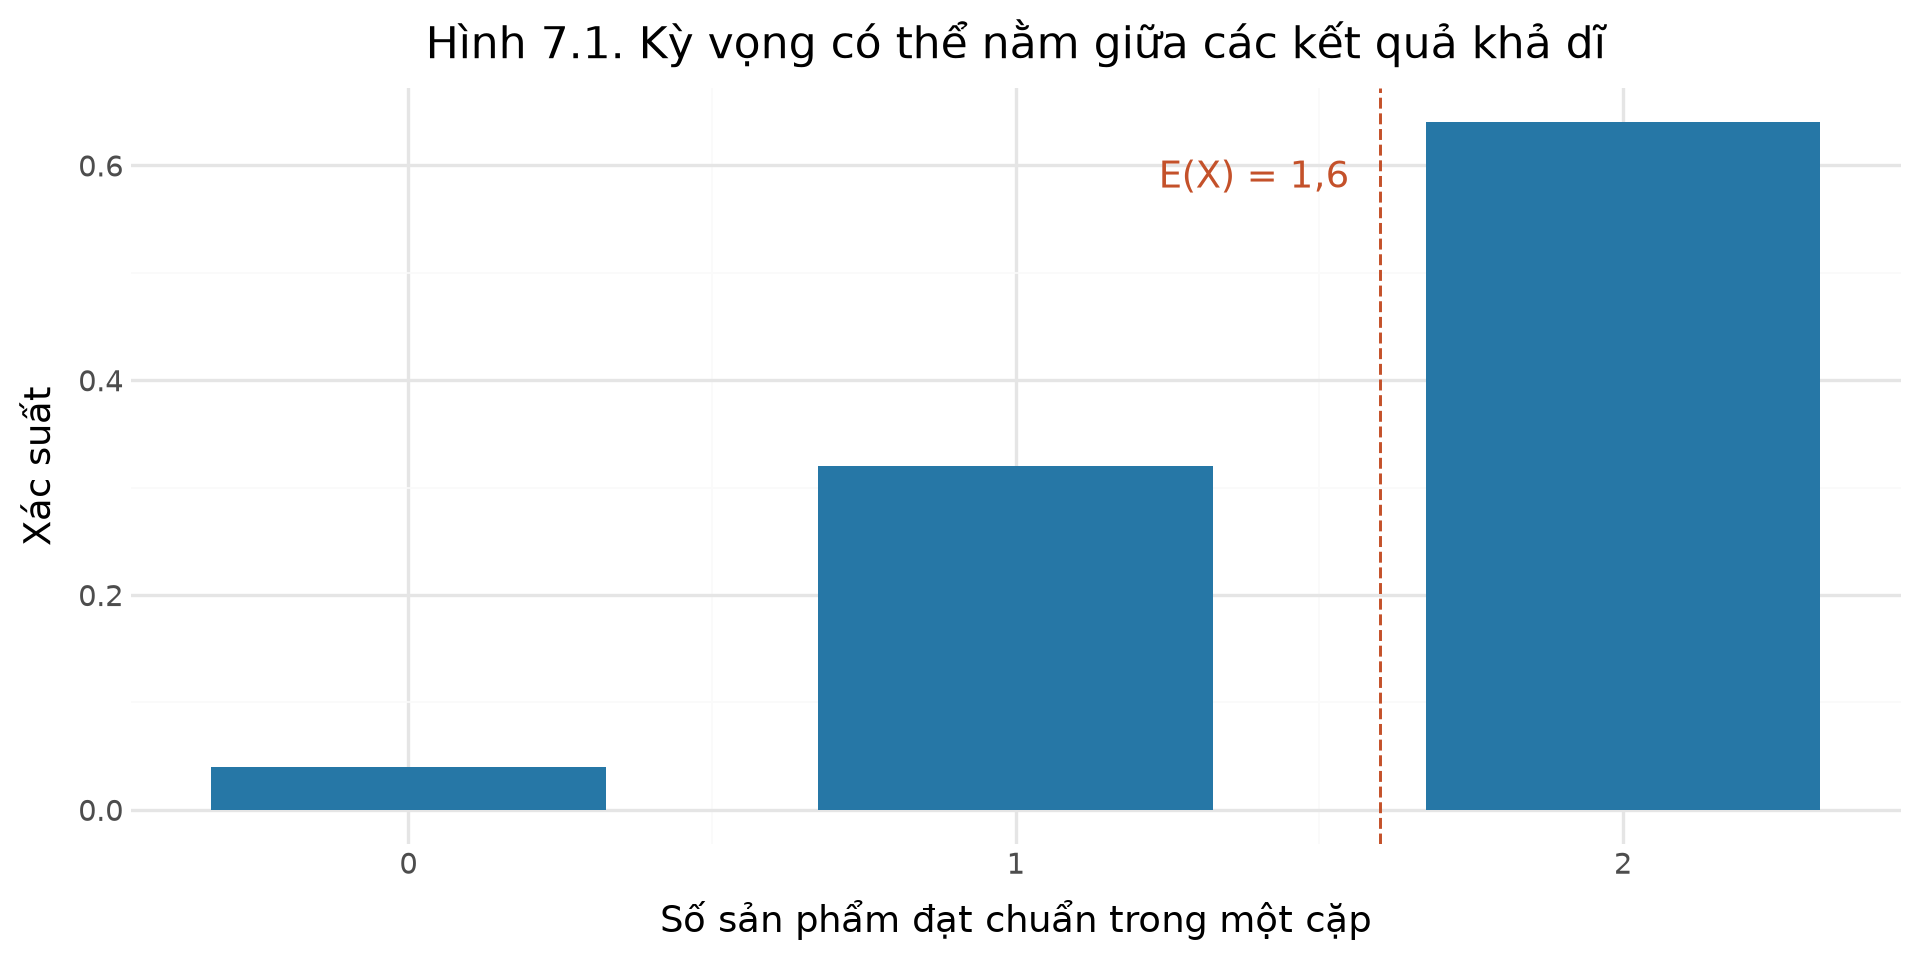

In [2]:
x_dat = np.arange(3)
p_dat = stats.binom.pmf(x_dat, n=2, p=0.8)
mu_dat = np.sum(x_dat * p_dat)
display(pd.DataFrame({"x (sản phẩm)": x_dat, "P(X=x)": p_dat,
                      "x P(X=x)": x_dat * p_dat}))
so_cap = 5000  # Thử đổi: số cặp được kiểm tra, không phải số sản phẩm mỗi cặp
dat_mo_phong = rng.binomial(n=2, p=0.8, size=so_cap)
print(f"Kỳ vọng lý thuyết = {mu_dat:.3f}; trung bình mô phỏng = {dat_mo_phong.mean():.3f}")
du_lieu_hinh = pd.DataFrame({"x":x_dat,"xac_suat":p_dat})
hinh = (p9.ggplot(du_lieu_hinh,p9.aes(x="x",y="xac_suat"))
    + p9.geom_col(width=0.65,fill="#2677A6")
    + p9.geom_vline(xintercept=mu_dat,color="#C4512A",linetype="dashed")
    + p9.annotate("text",x=mu_dat-0.05,y=0.59,label="E(X) = 1,6",ha="right",color="#C4512A")
    + p9.scale_x_continuous(breaks=[0,1,2])
    + p9.labs(x="Số sản phẩm đạt chuẩn trong một cặp",y="Xác suất",
              title="Hình 7.1. Kỳ vọng có thể nằm giữa các kết quả khả dĩ"))
display(hinh)

Trung bình mô phỏng ở gần 1,6, nhưng không có cột nào ở 1,6. Tăng `so_cap` làm trung bình mô phỏng ổn định hơn; nó không thêm giá trị mới vào miền giá trị của $X$.

### Tính tuyến tính và Ví dụ 2 — Chi phí xử lý

Với các hằng số $a,b,c$:

| Tính chất | Công thức | Đọc thành lời |
|---|---|---|
| Hằng số | $E(c)=c$ | trung bình của một hằng số là chính nó |
| Đổi thang đo | $E(aX+b)=a\,E(X)+b$ | đổi đơn vị thì kỳ vọng đổi theo cùng công thức |
| Cộng | $E(X+Y)=E(X)+E(Y)$ | kỳ vọng của tổng bằng tổng các kỳ vọng |
| Tuyến tính | $E(aX+bY)=a\,E(X)+b\,E(Y)$ | kết hợp hai dòng trên |

**Tính cộng của kỳ vọng không cần độc lập.** Đây là điểm khác quan trọng so với phương sai ở mục 2.

<details><summary><b>Vì sao?</b> Chứng minh tính tuyến tính của kỳ vọng</summary>

*$E(aX+b)=a\,E(X)+b$.* Dùng công thức kỳ vọng của một hàm (ngay dưới) với $g(x)=ax+b$:
$$E(aX+b)=\sum_x(ax+b)\,p_X(x)=a\sum_x x\,p_X(x)+b\sum_x p_X(x)=a\,E(X)+b\cdot1.$$
Trường hợp $a=0$ cho $E(c)=c$.

*$E(X+Y)=E(X)+E(Y)$.* Tính kỳ vọng trực tiếp trên không gian mẫu (giả sử $\Omega$ hữu hạn hoặc đếm được):
$$E(X)=\sum_{\omega\in\Omega}X(\omega)\,P(\{\omega\}),$$
vì gom các kết quả $\omega$ có cùng giá trị $X(\omega)=x$ ta được lại $\sum_x x\,p_X(x)$. Biến $X+Y$ nhận giá trị $X(\omega)+Y(\omega)$ tại kết quả $\omega$, nên
$$E(X+Y)=\sum_\omega\big(X(\omega)+Y(\omega)\big)P(\{\omega\})=\sum_\omega X(\omega)P(\{\omega\})+\sum_\omega Y(\omega)P(\{\omega\})=E(X)+E(Y).\ \blacksquare$$

Không bước nào dùng đến tính độc lập. Hệ quả: $E(X_1+\cdots+X_n)=E(X_1)+\cdots+E(X_n)$ với **mọi** biến ngẫu nhiên. Ở biến liên tục (mục 5), thay tổng bằng tích phân; các tính chất giữ nguyên.

</details>

**Ví dụ 2.** Cơ sở kiểm tra hai sản phẩm độc lập, xác suất đạt chuẩn mỗi sản phẩm là 0,8; $X$ đếm số đạt chuẩn và $E(X)=1{,}6$. Chi phí cố định 50 nghìn đồng cho một cặp, cộng 20 nghìn đồng cho mỗi sản phẩm đạt chuẩn. (1) Viết chi phí $C$ theo $X$. (2) Tính và diễn giải $E(C)$.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.* Chi phí gồm phần cố định và phần theo số sản phẩm đạt:
$$C=50+20X\quad\text{(nghìn đồng)}.$$

*Câu 2.* Dùng $E(aX+b)=a\,E(X)+b$ với $a=20$, $b=50$:
$$E(C)=50+20\,E(X)=50+20\cdot1{,}6=82\text{ nghìn đồng}.$$

Khi xử lý nhiều cặp trong cùng điều kiện, chi phí trung bình mỗi cặp gần 82 nghìn đồng. Chi phí của từng cặp chỉ nhận 50, 70 hoặc 90 nghìn đồng.

</details>

Ô dưới kiểm tra bằng cách khác: đổi từng giá trị $x$ thành chi phí $50+20x$, giữ nguyên xác suất $p_X(x)$, rồi cộng. Hai cách phải cùng cho 82.

In [3]:
chi_phi = 50 + 20 * x_dat
display(pd.DataFrame({"X": x_dat, "C (nghìn đồng)": chi_phi,
                      "P": p_dat, "C nhân P": chi_phi * p_dat}))
print("E(C) =", np.sum(chi_phi * p_dat), "nghìn đồng")

,X,C (nghìn đồng),P,C nhân P
0,0,50,0.04,2.0
1,1,70,0.32,22.4
2,2,90,0.64,57.6


E(C) = 82.0 nghìn đồng


### Kỳ vọng của một hàm và Bài tập 1 — Chia bánh

Nếu $Y=g(X)$, tính trung bình các giá trị **sau khi biến đổi**, giữ nguyên xác suất:

$$E[g(X)]=\sum_x g(x)\,P(X=x).$$

Đọc là: thay mỗi giá trị $x$ bằng $g(x)$, xác suất gắn với nó không đổi. Không được bình phương xác suất khi tính $E(X^2)$: $E(X^2)=\sum_x x^2\,p_X(x)$. Nói chung $E[g(X)]\ne g(E(X))$. Ví dụ: $X$ nhận 0 hoặc 2 với xác suất $\frac12$ mỗi giá trị; $E(X^2)=\frac12\cdot4=2$, còn $\big(E(X)\big)^2=1$.

<details><summary><b>Vì sao?</b> Công thức kỳ vọng của một hàm</summary>

Đặt $Y=g(X)$. Theo định nghĩa, $E(Y)=\sum_y y\,P(Y=y)$. Biến cố $\{Y=y\}$ là hợp của các biến cố rời nhau $\{X=x\}$ với mọi $x$ thỏa $g(x)=y$. Do đó
$$\sum_y y\,P(Y=y)=\sum_y y\sum_{x:\,g(x)=y}p_X(x)=\sum_y\sum_{x:\,g(x)=y}g(x)\,p_X(x)=\sum_x g(x)\,p_X(x).$$
Đẳng thức thứ hai đúng vì trong tổng bên trong luôn có $g(x)=y$. Đẳng thức cuối đúng vì khi gom theo $y$, mỗi $x$ được đếm đúng một lần. $\blacksquare$

Nếu nhiều $x$ cho cùng một $g(x)$, xác suất của giá trị $Y$ đó là tổng các xác suất tương ứng. Vì vậy phân phối của $Y$ nói chung khác phân phối của $X$.

</details>

**Bài tập 1.** An mời hai người bạn đến ăn bánh. Mỗi người độc lập tung một đồng xu cân đối để quyết định có đến hay không. Bánh chia đều cho An và những người có mặt. Nếu $N$ là số bạn đến, phần bánh $X$ của An là 1, $1/2$, $1/3$ khi $N=0,1,2$. Tính $E(X)$ và so sánh với $1/E(N+1)$.

<details><summary>Đáp án và cách lập luận</summary>

*Bước 1: phân phối của $N$.* $N\sim\operatorname{Binomial}(2,\ 1/2)$:

| $n$ | 0 | 1 | 2 |
|---|---:|---:|---:|
| $P(N=n)$ | $1/4$ | $1/2$ | $1/4$ |
| $X=1/(n+1)$ | 1 | $1/2$ | $1/3$ |

*Bước 2: kỳ vọng của hàm $g(n)=\frac1{n+1}$.*
$$E(X)=1\cdot\frac14+\frac12\cdot\frac12+\frac13\cdot\frac14=\frac3{12}+\frac3{12}+\frac1{12}=\frac7{12}\approx0{,}583.$$

*Bước 3: so sánh.* $E(N)=0\cdot\frac14+1\cdot\frac12+2\cdot\frac14=1$, nên $\frac1{E(N+1)}=\frac12$.

Hai số khác nhau: $\frac7{12}\ne\frac12$. Lấy trung bình số người trước rồi mới chia bánh là một phép tính khác với chia bánh từng lần rồi mới lấy trung bình.

</details>

Ô dưới lập hai cột "phần bánh" và "phần bánh nhân xác suất" để thấy sự khác biệt.

In [4]:
n_ban = np.arange(3)
p_ban = stats.binom.pmf(n_ban, n=2, p=0.5)
phan_banh = 1 / (n_ban + 1)
display(pd.DataFrame({"N":n_ban,"P":p_ban,"X":phan_banh,"X nhân P":phan_banh*p_ban}))
print("E[1/(N+1)] =", np.dot(phan_banh,p_ban))
print("1/E[N+1] =", 1 / np.dot(n_ban+1,p_ban))

,N,P,X,X nhân P
0,0,0.25,1.00000,0.25000
1,1,0.50,0.50000,0.25000
2,2,0.25,0.33333,0.08333


E[1/(N+1)] = 0.5833333333333335
1/E[N+1] = 0.4999999999999999


### Kỳ vọng của các phân phối rời rạc đã học

| Mô hình | Đại lượng được đếm | Kỳ vọng |
|---|---|---|
| Bernoulli$(p)$ | thành công trong một phép thử | $p$ |
| Binomial$(n,p)$ | thành công trong $n$ phép thử độc lập, cùng $p$ | $np$ |
| Hypergeometric$(N,K,n)$ | thành công trong $n$ phần tử lấy không hoàn lại từ $N$ phần tử có $K$ thành công | $nK/N$ |
| Poisson$(\lambda)$ | số sự kiện trong một khoảng | $\lambda$ |
| Đều rời rạc trên $\{1,\ldots,m\}$ | một giá trị chọn đều | $(m+1)/2$ |

$K$ là số phần tử thành công **trong tổng thể**, khác với $n$ là cỡ mẫu. Các công thức chỉ dùng được khi điều kiện của mô hình thỏa; công thức không tự quyết định mô hình nào phù hợp.

**Mẹo biến chỉ báo.** Gọi $I_i=1$ nếu phép thử thứ $i$ thành công, $I_i=0$ nếu không. Số thành công là $X=I_1+\cdots+I_n$. Mỗi $I_i$ có kỳ vọng $p$, nên theo tính cộng của kỳ vọng: $E(X)=np$. Với siêu bội, các lần rút phụ thuộc nhau, nhưng tính cộng không cần độc lập, nên vẫn có $E(X)=nK/N$.

<details><summary><b>Vì sao?</b> Kỳ vọng của từng phân phối</summary>

*Bernoulli.* $E(X)=1\cdot p+0\cdot(1-p)=p$.

*Nhị thức.* $X=I_1+\cdots+I_n$, mỗi $I_i\sim\operatorname{Bernoulli}(p)$. Tính cộng (không cần độc lập): $E(X)=p+\cdots+p=np$.

*Siêu bội.* Gọi $I_j=1$ nếu lần rút thứ $j$ ra lá ghi 1. Chưa biết kết quả các lần khác, lần rút thứ $j$ có thể là bất kỳ lá nào trong $N$ lá với khả năng như nhau (Tuần 05: "lần 2 ra xanh vẫn có xác suất 3/10"). Vậy $P(I_j=1)=K/N$ với mọi $j$, và $E(X)=nK/N$.

*Poisson.* Số hạng $k=0$ bằng 0. Với $k\ge1$, $\frac{k}{k!}=\frac1{(k-1)!}$:
$$E(X)=\sum_{k=1}^\infty k\,e^{-\lambda}\frac{\lambda^k}{k!}=\lambda e^{-\lambda}\sum_{k=1}^\infty\frac{\lambda^{k-1}}{(k-1)!}=\lambda e^{-\lambda}e^{\lambda}=\lambda.$$

*Đều rời rạc.* Dùng $\sum_{k=1}^m k=\frac{m(m+1)}2$: $E(X)=\frac1m\cdot\frac{m(m+1)}2=\frac{m+1}2$. Với một xúc xắc ($m=6$), $E(X)=3{,}5$. $\blacksquare$

</details>

<a id="hoc-f5579cb3"></a>
## 2. Phương sai và độ lệch chuẩn

### Ví dụ 3 — Cặp sản phẩm dao động bao nhiêu?

Vẫn là hai sản phẩm độc lập, xác suất đạt chuẩn 0,8. Biết $\mu=E(X)=1{,}6$, ta hỏi: kết quả của một cặp thường cách 1,6 bao xa?

Các độ lệch có dấu $x-\mu$ cộng lại (có trọng số) luôn bằng 0, nên không dùng được. Bình phương độ lệch để dương và âm không triệt tiêu nhau:

$$\operatorname{Var}(X)=E[(X-\mu)^2]=\sum_x(x-\mu)^2\,p_X(x),\qquad \operatorname{SD}(X)=\sqrt{\operatorname{Var}(X)}.$$

Đọc là: phương sai là trung bình của bình phương khoảng cách đến tâm; độ lệch chuẩn là căn bậc hai của nó. Đây đúng là phương sai của dữ liệu ở Tuần 02, chỉ thay tần suất bằng xác suất.

Phương sai có đơn vị bình phương; SD có cùng đơn vị với $X$. Cả hai không âm; SD bằng 0 khi $X$ là hằng số.

*Giải tay.*
$$\operatorname{Var}(X)=(0-1{,}6)^2(0{,}04)+(1-1{,}6)^2(0{,}32)+(2-1{,}6)^2(0{,}64)=0{,}1024+0{,}1152+0{,}1024=0{,}32.$$
$$\operatorname{SD}(X)=\sqrt{0{,}32}\approx0{,}566\text{ sản phẩm}.$$

SD đo quy mô dao động; nó không có nghĩa mọi cặp lệch khỏi kỳ vọng đúng 0,566 sản phẩm.

**Công thức tính nhanh.**
$$\operatorname{Var}(X)=E(X^2)-[E(X)]^2.$$
Đọc là: trung bình của bình phương trừ bình phương của trung bình. Với cặp sản phẩm, $E(X^2)=0^2(0{,}04)+1^2(0{,}32)+2^2(0{,}64)=2{,}88$, nên $\operatorname{Var}(X)=2{,}88-1{,}6^2=0{,}32$. Vì phương sai không âm, luôn có $E(X^2)\ge[E(X)]^2$; tính ra phương sai âm là chắc chắn có lỗi.

<details><summary><b>Vì sao?</b> Chứng minh công thức tính nhanh</summary>

Khai triển $(X-\mu)^2=X^2-2\mu X+\mu^2$, rồi dùng tính tuyến tính; $\mu$ là hằng số:
$$E[(X-\mu)^2]=E(X^2)-2\mu\,E(X)+\mu^2=E(X^2)-2\mu^2+\mu^2=E(X^2)-\mu^2.\ \blacksquare$$

*Điều kiện kỹ thuật.* Các công thức cần $E(X^2)$ hữu hạn. Mọi bảng hữu hạn đều thỏa. Với phân phối có vô số giá trị hoặc phân phối liên tục, phải kiểm tra điều kiện này; chẳng hạn phân phối t với bậc tự do 2 ở mục 8 không có phương sai hữu hạn.

</details>

Bảng ở ô dưới cho thấy mỗi giá trị đóng góp bao nhiêu vào phương sai.

In [5]:
bang_var = pd.DataFrame({"x":x_dat,"p":p_dat,"x²":x_dat**2,
                         "(x−μ)²":(x_dat-mu_dat)**2})
bang_var["Đóng góp phương sai"] = (x_dat-mu_dat)**2 * p_dat
display(bang_var)
var_dat = np.dot((x_dat-mu_dat)**2,p_dat)
var_rut_gon = np.dot(x_dat**2,p_dat) - mu_dat**2
print("Var trực tiếp / rút gọn / SD:", var_dat, var_rut_gon, np.sqrt(var_dat))
assert np.isclose(var_dat, 0.32) and np.isclose(var_dat,var_rut_gon)

,x,p,x²,(x−μ)²,Đóng góp phương sai
0,0,0.04,0,2.56,0.1024
1,1,0.32,1,0.36,0.1152
2,2,0.64,4,0.16,0.1024


Var trực tiếp / rút gọn / SD: 0.31999999999999995 0.3199999999999994 0.565685424949238


### Đổi đơn vị và Bài tập 2 — Celsius sang Fahrenheit

Với các hằng số $a,b,c$:

$$\operatorname{Var}(c)=0,\quad \operatorname{Var}(X+b)=\operatorname{Var}(X),$$
$$\operatorname{Var}(aX+b)=a^2\operatorname{Var}(X),\quad
\operatorname{SD}(aX+b)=\lvert a\rvert\,\operatorname{SD}(X).$$

Đọc là: cộng một hằng số chỉ dịch cả phân phối, không đổi độ phân tán; nhân với $a$ thì khoảng cách đến tâm nhân $\lvert a\rvert$, bình phương khoảng cách nhân $a^2$. Dấu trị tuyệt đối giữ cho SD không âm, kể cả khi $a<0$.

<details><summary><b>Vì sao?</b> Chứng minh $\mathrm{Var}(aX+b)=a^2\,\mathrm{Var}(X)$</summary>

*Bước 1.* Theo tính tuyến tính, $E(aX+b)=a\mu+b$, nên độ lệch khỏi tâm là $(aX+b)-(a\mu+b)=a(X-\mu)$.

*Bước 2.* $\operatorname{Var}(aX+b)=E\big[a^2(X-\mu)^2\big]=a^2\operatorname{Var}(X)$.

*Bước 3.* Lấy căn: $\operatorname{SD}(aX+b)=\sqrt{a^2}\,\operatorname{SD}(X)=\lvert a\rvert\operatorname{SD}(X)$. $\blacksquare$

Chứng minh giống hệt phép đổi thang đo của dữ liệu ở Tuần 02.

</details>

**Bài tập 2.** Nhiệt độ $X$ theo độ C có $E(X)=25$ và $\operatorname{SD}(X)=3$. Đặt $Y=1{,}8X+32$ theo độ F. Tính $E(Y)$, $\operatorname{Var}(Y)$, $\operatorname{SD}(Y)$.

<details><summary>Đáp án và cách lập luận</summary>

Ở đây $a=1{,}8$, $b=32$.

*Kỳ vọng.* $E(Y)=1{,}8\cdot25+32=45+32=77\,{}^\circ\mathrm F$.

*Phương sai.* $\operatorname{Var}(X)=3^2=9$, nên $\operatorname{Var}(Y)=1{,}8^2\cdot9=3{,}24\cdot9=29{,}16\,({}^\circ\mathrm F)^2$.

*Độ lệch chuẩn.* $\operatorname{SD}(Y)=1{,}8\cdot3=5{,}4\,{}^\circ\mathrm F$ (cũng bằng $\sqrt{29{,}16}$).

Cộng 32 chỉ dịch trung tâm; nhân 1,8 mới làm độ phân tán thay đổi.

</details>

### Cộng hai biến: khi nào được cộng phương sai?

Hai biến $X$, $Y$ **độc lập** khi $P(X\in A,\ Y\in B)=P(X\in A)\,P(Y\in B)$ với mọi tập giá trị $A$, $B$. Với biến rời rạc, chỉ cần $P(X=x,\ Y=y)=p_X(x)\,p_Y(y)$ với mọi $x,y$. Nói cách khác, biết giá trị của biến này không cho thêm thông tin gì về biến kia. Nếu độc lập:

$$\operatorname{Var}(X+Y)=\operatorname{Var}(X-Y)=\operatorname{Var}(X)+\operatorname{Var}(Y).$$

Đọc là: với hai biến độc lập, phương sai của tổng **và cả của hiệu** đều bằng tổng hai phương sai. Trừ đi một đại lượng ngẫu nhiên không làm bớt bất định, mà cộng thêm bất định của nó.

**SD không cộng được.** Phải cộng phương sai rồi mới lấy căn. Ví dụ $\operatorname{SD}(X)=3$, $\operatorname{SD}(Y)=4$, độc lập: $\operatorname{SD}(X+Y)=\sqrt{9+16}=5$, không phải 7.

Với các biến phụ thuộc, công thức tổng quát có thêm **hiệp phương sai** $\operatorname{Cov}(X,Y)=E[(X-E(X))(Y-E(Y))]$, đo mức hai biến cùng lệch về một phía:

$$\operatorname{Var}(X\pm Y)=\operatorname{Var}(X)+\operatorname{Var}(Y)\pm2\operatorname{Cov}(X,Y).$$

<details><summary><b>Vì sao?</b> Phương sai của tổng và vai trò của độc lập</summary>

Đặt $\mu_X=E(X)$, $\mu_Y=E(Y)$.

*Bước 1: công thức tổng quát.* Độ lệch của tổng khỏi tâm là $(X-\mu_X)+(Y-\mu_Y)$. Bình phương theo $(u+v)^2=u^2+v^2+2uv$, rồi lấy kỳ vọng từng số hạng:
$$\operatorname{Var}(X+Y)=\operatorname{Var}(X)+\operatorname{Var}(Y)+2\operatorname{Cov}(X,Y).$$
Khai triển tích như ở công thức tính nhanh cho $\operatorname{Cov}(X,Y)=E(XY)-\mu_X\mu_Y$.

*Bước 2: nếu độc lập thì $E(XY)=E(X)E(Y)$.*
$$E(XY)=\sum_x\sum_y xy\,P(X=x,Y=y)=\sum_x\sum_y xy\,p_X(x)\,p_Y(y)=\Big(\sum_x x\,p_X(x)\Big)\Big(\sum_y y\,p_Y(y)\Big).$$
Đẳng thức giữa dùng tính độc lập. Vậy $\operatorname{Cov}(X,Y)=0$ và $\operatorname{Var}(X+Y)=\operatorname{Var}(X)+\operatorname{Var}(Y)$.

*Bước 3: hiệu.* $X-Y=X+(-1)Y$, và $\operatorname{Var}(-Y)=(-1)^2\operatorname{Var}(Y)=\operatorname{Var}(Y)$. $\blacksquare$

</details>

**Code.** Ô dưới kiểm tra Bài tập 2, rồi so sánh $X+Y$ với $X+X$. `rng.choice([-1,1], size=20000)` tạo 20.000 giá trị $\pm1$ cùng khả năng; mỗi giá trị có phương sai 1.

**Bạn đoán trước:** $\operatorname{Var}(X+Y)$ với $X$, $Y$ độc lập bằng bao nhiêu? Còn $\operatorname{Var}(X+X)$?

In [6]:
print("Fahrenheit: E =",1.8*25+32,"; Var =",1.8**2*9,"; SD =",1.8*3)
x_doc_lap = rng.choice([-1,1],size=20000)
y_doc_lap = rng.choice([-1,1],size=20000)
print("Var(X+Y), X,Y độc lập:",np.var(x_doc_lap+y_doc_lap))
print("Var(X+X), hai biến cùng là X:",np.var(x_doc_lap+x_doc_lap))
print("E(X+X) và 2E(X):",(x_doc_lap+x_doc_lap).mean(),2*x_doc_lap.mean())

Fahrenheit: E = 77.0 ; Var = 29.160000000000004 ; SD = 5.4
Var(X+Y), X,Y độc lập: 2.0039190000000002
Var(X+X), hai biến cùng là X: 3.99992944
E(X+X) và 2E(X): 0.0084 0.0084


Hai biến tạo độc lập cho phương sai tổng gần 2. Dùng hai lần cùng một $X$ cho phương sai gần 4, vì $\operatorname{Var}(2X)=2^2\operatorname{Var}(X)$. Trong cả hai trường hợp kỳ vọng vẫn cộng được.

### Phương sai của các phân phối rời rạc đặc biệt

| Mô hình | Phương sai | SD |
|---|---|---|
| Bernoulli$(p)$ | $p(1-p)$ | $\sqrt{p(1-p)}$ |
| Binomial$(n,p)$ | $np(1-p)$ | $\sqrt{np(1-p)}$ |
| Poisson$(\lambda)$ | $\lambda$ | $\sqrt\lambda$ |
| Hypergeometric$(N,K,n)$, $p=K/N$, $N>1$ | $np(1-p)\dfrac{N-n}{N-1}$ | căn bậc hai của phương sai |
| Đều rời rạc trên $\{1,\ldots,m\}$ | $\dfrac{m^2-1}{12}$ | căn bậc hai của phương sai |

Ý chính của từng dòng:

- *Bernoulli:* $X$ chỉ nhận 0 hoặc 1 nên $X^2=X$, do đó $E(X^2)-[E(X)]^2=p-p^2$. Phương sai lớn nhất khi $p=\frac12$.
- *Nhị thức:* tổng $n$ biến Bernoulli **độc lập**, nên cộng $n$ phương sai $p(1-p)$. Ví dụ hai sản phẩm: $2(0{,}8)(0{,}2)=0{,}32$, khớp với Ví dụ 3.
- *Siêu bội:* thừa số $\frac{N-n}{N-1}$ (hệ số hiệu chỉnh tổng thể hữu hạn) nhỏ hơn 1, vì lấy không hoàn lại thì ít dao động hơn. Nếu lấy cả tổng thể ($n=N$), số thành công không còn ngẫu nhiên và phương sai bằng 0. Khi $N=1$, tính trực tiếp từ hộp.
- *Đều rời rạc:* một xúc xắc có $\operatorname{Var}=\frac{35}{12}\approx2{,}917$.

<details><summary><b>Vì sao?</b> Phương sai Poisson, đều rời rạc và siêu bội</summary>

*Poisson: mẹo $E[X(X-1)]$.* Số hạng $k=0$ và $k=1$ bằng 0. Với $k\ge2$, $\frac{k(k-1)}{k!}=\frac1{(k-2)!}$:
$$E[X(X-1)]=\lambda^2e^{-\lambda}\sum_{k=2}^\infty\frac{\lambda^{k-2}}{(k-2)!}=\lambda^2.$$
Suy ra $E(X^2)=E[X(X-1)]+E(X)=\lambda^2+\lambda$, và $\operatorname{Var}(X)=\lambda^2+\lambda-\lambda^2=\lambda$.

*Đều rời rạc.* Dùng $\sum_{k=1}^m k^2=\frac{m(m+1)(2m+1)}6$: $E(X^2)=\frac{(m+1)(2m+1)}6$, nên
$$\operatorname{Var}(X)=\frac{(m+1)(2m+1)}6-\frac{(m+1)^2}4=\frac{(m+1)\big[2(2m+1)-3(m+1)\big]}{12}=\frac{(m+1)(m-1)}{12}=\frac{m^2-1}{12}.$$

*Siêu bội (đọc thêm).* Viết $X=I_1+\cdots+I_n$ với $I_j$ là biến chỉ báo lần rút $j$ ra lá 1. Các $I_j$ không độc lập. Với $i\ne j$: $P(I_i=1,I_j=1)=\frac KN\cdot\frac{K-1}{N-1}$, rút gọn được $\operatorname{Cov}(I_i,I_j)=-\frac{p(1-p)}{N-1}$, âm vì rút được lá 1 làm lá 1 khan hiếm hơn. Phương sai của tổng $n$ biến bằng tổng các phương sai cộng tổng hiệp phương sai trên $n(n-1)$ cặp có thứ tự:
$$\operatorname{Var}(X)=np(1-p)-n(n-1)\frac{p(1-p)}{N-1}=np(1-p)\,\frac{N-n}{N-1}.$$
Ví dụ Ví dụ 14 của Tuần 06 ($N=10$, $K=6$, $n=3$): $3(0{,}6)(0{,}4)\cdot\frac79=0{,}56$. $\blacksquare$

</details>

### Cùng kỳ vọng, khác phân phối (theo STAT 20)

Xúc xắc cân đối có $E(X)=3{,}5$ và phương sai $\frac{35}{12}\approx2{,}9167$. Xúc xắc lệch có xác suất ở các mặt 1–6 lần lượt $(0{,}1;\ 0{,}3;\ 0{,}1;\ 0{,}2;\ 0{,}1;\ 0{,}2)$ cũng có $E(X)=3{,}5$, nhưng phương sai $2{,}85$. Kỳ vọng bằng nhau không có nghĩa phân phối bằng nhau. Các hình dựng lại biểu đồ ở STAT 20 §4.8.1 và §4.10.

Ở ô dưới, mỗi khung con là một bảng xác suất vẽ thành cột; đường đỏ là kỳ vọng. Đừng chỉ dựa vào đường đỏ để đoán hình dạng.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** `geom_vline` thêm đường dọc tại `xintercept`. `geom_col` vẽ cột có độ dài lấy trực tiếp từ giá trị `y` đã tính trong bảng. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

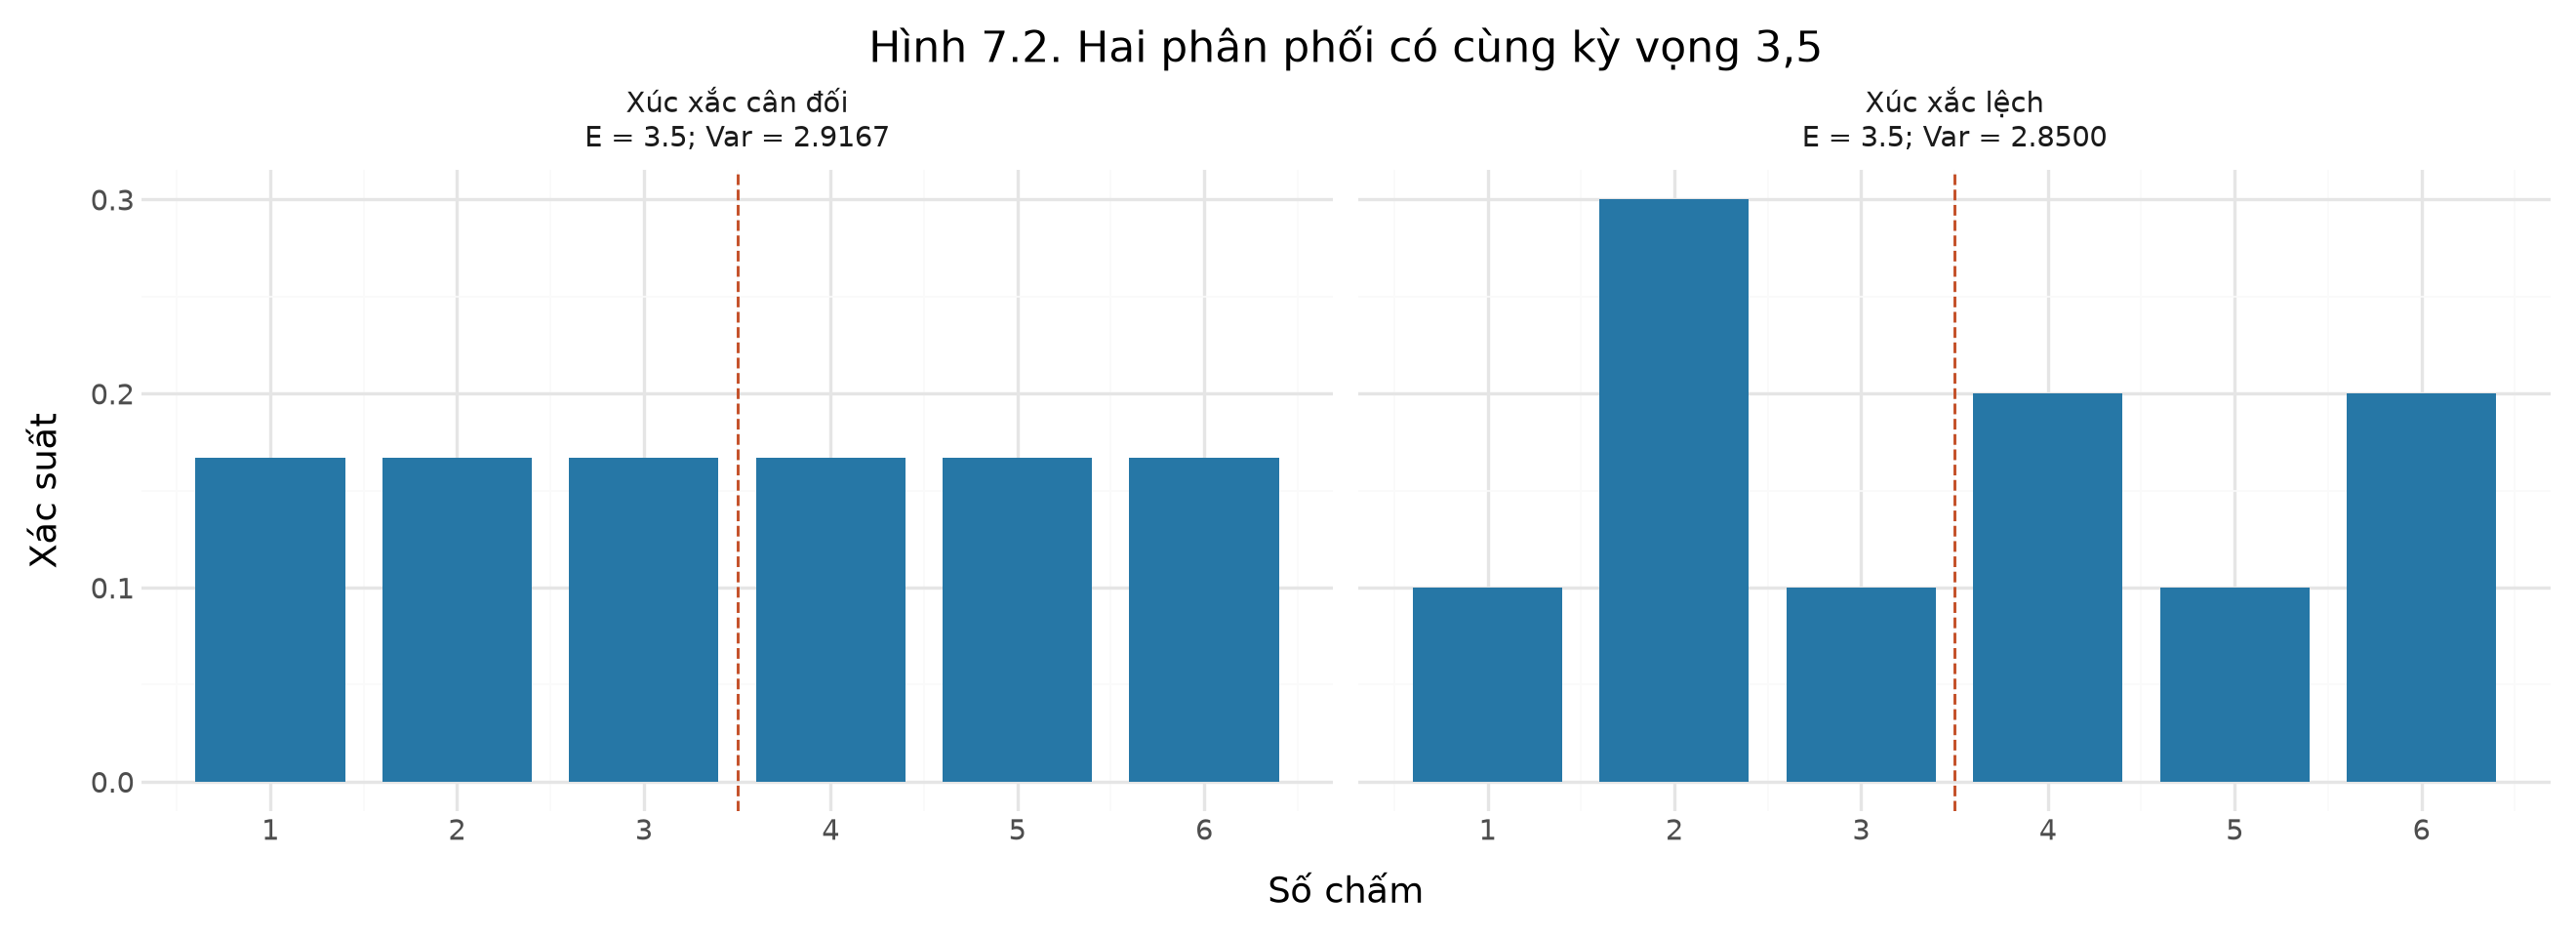

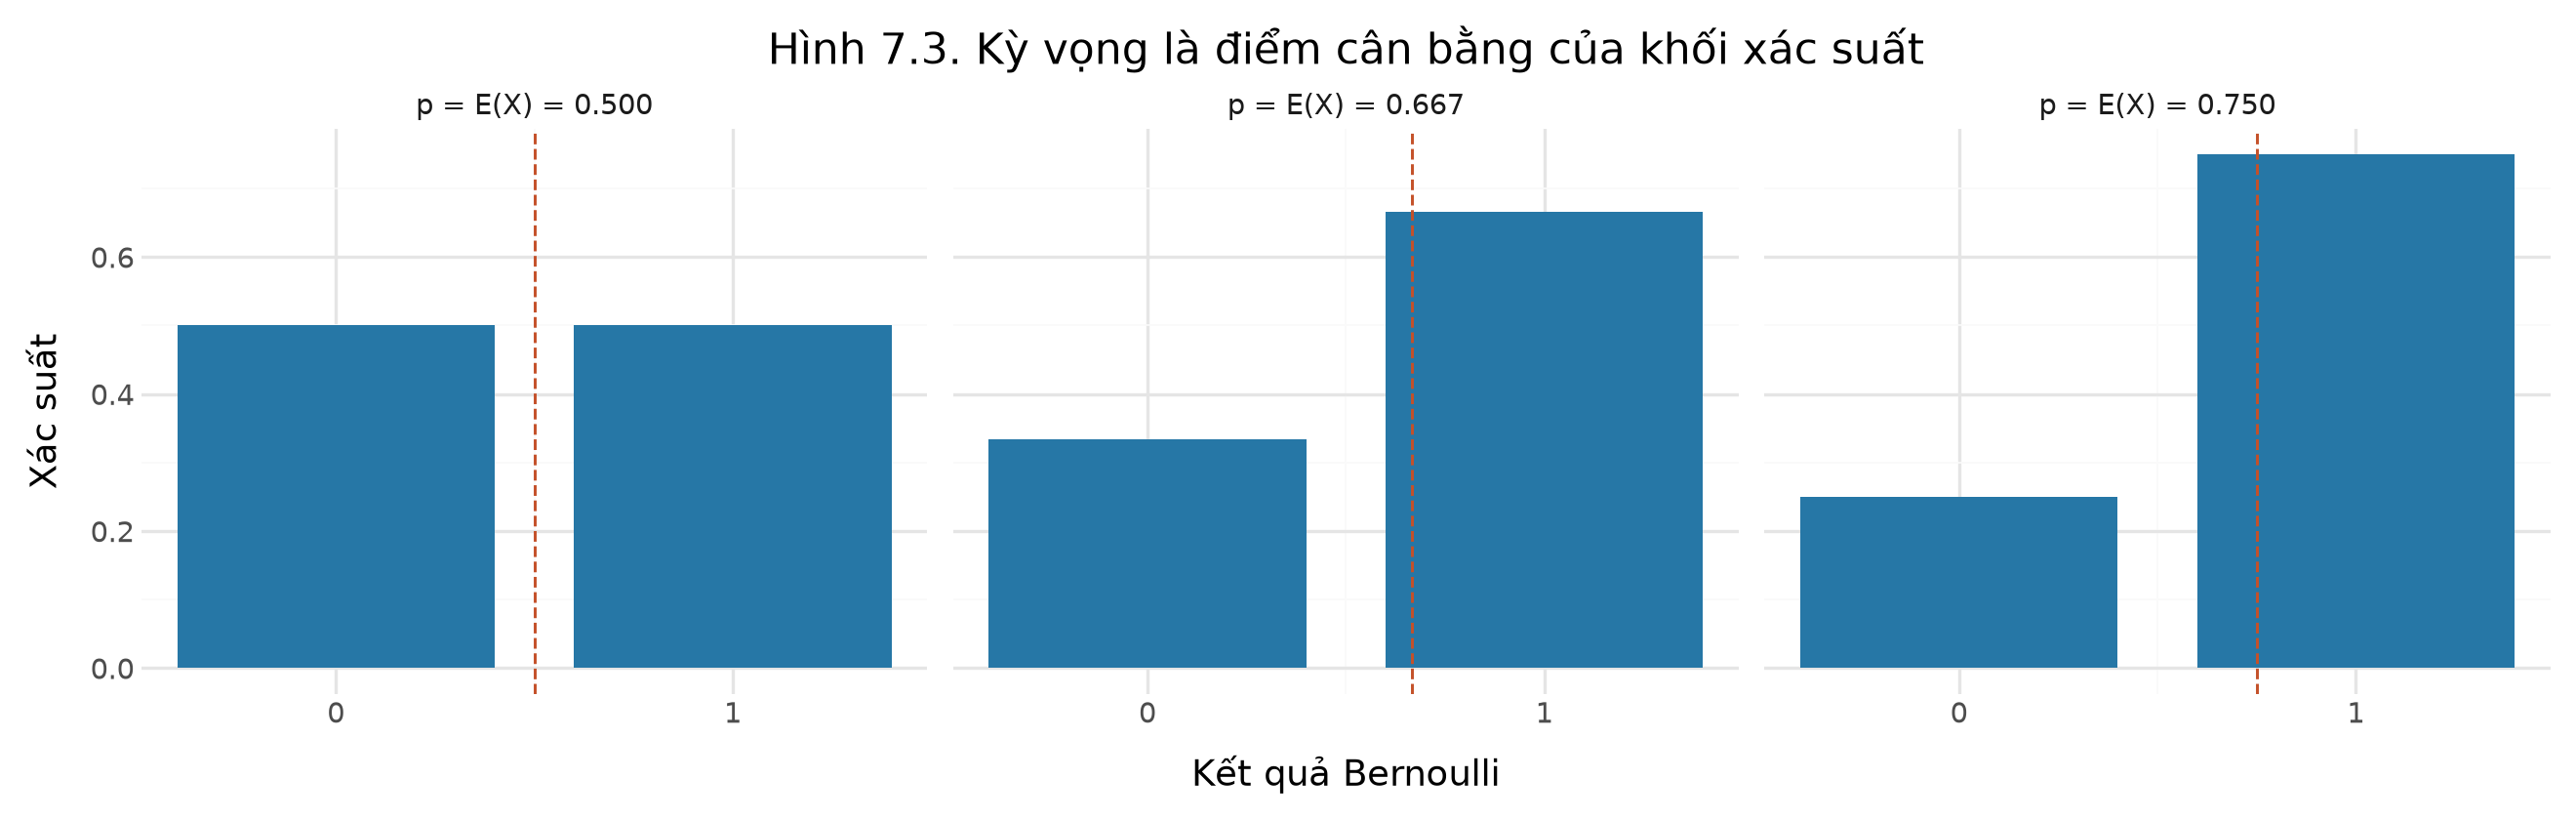

In [7]:
x_xuc_xac = np.arange(1,7)
p_can_doi = np.repeat(1/6,6)
p_lech = np.array([0.1,0.3,0.1,0.2,0.1,0.2])
cac_bang = []
cac_tam = []
for p,ten in [(p_can_doi,"Xúc xắc cân đối"),(p_lech,"Xúc xắc lệch")]:
    mu = np.dot(x_xuc_xac,p); var = np.dot((x_xuc_xac-mu)**2,p)
    nhan = f"{ten}\nE = {mu:.1f}; Var = {var:.4f}"
    cac_bang.append(pd.DataFrame({"x":x_xuc_xac,"p":p,"phan_phoi":nhan}))
    cac_tam.append({"phan_phoi":nhan,"mu":mu})
bang_xuc_xac = pd.concat(cac_bang,ignore_index=True)
hinh = (p9.ggplot(bang_xuc_xac,p9.aes("x","p"))
    + p9.geom_col(fill="#2677A6",width=0.8)
    + p9.geom_vline(pd.DataFrame(cac_tam),p9.aes(xintercept="mu"),color="#C4512A",linetype="dashed")
    + p9.facet_wrap("phan_phoi",ncol=2)
    + p9.scale_x_continuous(breaks=list(x_xuc_xac))
    + p9.labs(x="Số chấm",y="Xác suất",title="Hình 7.2. Hai phân phối có cùng kỳ vọng 3,5")
    + p9.theme(figure_size=(11,4)))
display(hinh)
cac_bang = []; cac_tam = []
for p in [0.5,0.75,2/3]:
    nhan=f"p = E(X) = {p:.3f}"
    cac_bang.append(pd.DataFrame({"x":[0,1],"p":[1-p,p],"phan_phoi":nhan}))
    cac_tam.append({"phan_phoi":nhan,"mu":p})
bang_bernoulli=pd.concat(cac_bang,ignore_index=True)
hinh = (p9.ggplot(bang_bernoulli,p9.aes("x","p"))
    + p9.geom_col(fill="#2677A6",width=0.8)
    + p9.geom_vline(pd.DataFrame(cac_tam),p9.aes(xintercept="mu"),color="#C4512A",linetype="dashed")
    + p9.facet_wrap("phan_phoi",ncol=3)
    + p9.scale_x_continuous(breaks=[0,1])
    + p9.labs(x="Kết quả Bernoulli",y="Xác suất",title="Hình 7.3. Kỳ vọng là điểm cân bằng của khối xác suất")
    + p9.theme(figure_size=(11,3.5)))
display(hinh)

Hai hình xúc xắc có cột phân bố khác nhau dù cùng tâm. Với Bernoulli, tâm dịch về 1 khi xác suất thành công tăng. Không có quy tắc rằng kỳ vọng luôn là kết quả có xác suất lớn nhất.

<a id="hoc-521c0d10"></a>
## 3. Nhiều lần rút: độc lập, cùng phân phối và chiếc hộp

Các biến $X_1,\ldots,X_n$ **độc lập và cùng phân phối** (i.i.d., independent and identically distributed) khi chúng độc lập với nhau và có cùng quy luật xác suất. Ví dụ: tung một đồng xu nhiều lần độc lập, cùng xác suất ngửa.

Hai lưu ý:

- Cùng kỳ vọng và cùng phương sai **chưa đủ** để nói cùng phân phối (hai xúc xắc ở trên là ví dụ).
- Độc lập từng đôi một chưa đủ để nói mọi biến cùng độc lập (Tuần 05).

<details><summary><b>Vì sao?</b> Định nghĩa "cùng phân phối" cho cả biến rời rạc và liên tục</summary>

"Cùng phân phối" nghĩa là cùng hàm phân phối tích lũy (cdf). Với biến rời rạc, điều này tương đương cùng PMF; với biến có mật độ, tương đương cùng hàm mật độ. Định nghĩa qua cdf bao gồm được cả hai loại.

</details>

**Mô hình chiếc hộp.** Ghi các giá trị lên các lá thăm; mỗi lá có cùng xác suất được rút. Nhiều lá có thể ghi cùng một số. Rút **có hoàn lại từ cùng một hộp**, trộn đều sau mỗi lần, tạo ra các biến i.i.d.:

- *cùng phân phối*: hộp không đổi;
- *độc lập*: hoàn lại và trộn đều, nên lần trước không ảnh hưởng lần sau.

Với một lần rút, **kỳ vọng là trung bình các số trong hộp**, và **phương sai là trung bình bình phương độ lệch, chia cho số lá trong hộp** (không phải số lá trừ 1). Lý do: mỗi lá có xác suất $\frac1N$, nên $E(X)=\sum_j c_j\cdot\frac1N$ và $\operatorname{Var}(X)=\sum_j(c_j-\mu)^2\cdot\frac1N$. Ở đây chia cho $N$ vì hộp là **toàn bộ** phân phối, không phải một mẫu. Hộp hữu hạn biểu diễn chính xác phân phối hữu hạn có các xác suất là bội của cùng một đơn vị; với phân phối khác có thể dùng trọng số hoặc xấp xỉ.

### Ví dụ 4 — Tổng hai xúc xắc bằng mô hình hộp

Hộp có sáu lá 1, 2, 3, 4, 5, 6. Rút một lá được $X_1$, có phân phối đều rời rạc; hoàn lại, trộn đều rồi rút lần hai được $X_2$. Cặp $(X_1,X_2)$ mô hình hóa hai xúc xắc độc lập. $S=X_1+X_2$ là tổng số chấm. $X_1$, $X_2$ đều, nhưng $S$ không đều vì có nhiều cách được tổng 7 hơn tổng 2.

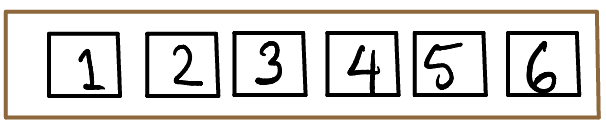

*Hình S1.* Hộp sáu lá thăm cho một lần gieo xúc xắc.
*Nguồn ảnh: bản dịch STAT 20, §4.13.1.1. [Tệp ảnh gốc](figures/01_stat20_die_box.jpg).*

**Code.** `rng.choice(x_xuc_xac, size=(5000,2), replace=True)` tạo 5.000 hàng, mỗi hàng là hai lần rút có hoàn lại từ hộp sáu lá. `sum(axis=1)` cộng theo hàng. Theo tính cộng của kỳ vọng, $E(S)=3{,}5+3{,}5=7$.

In [8]:
hai_lan_rut = rng.choice(x_xuc_xac, size=(5000,2), replace=True)
tong_hai = hai_lan_rut.sum(axis=1)
print("Mỗi hàng là hai lần gieo; 5 hàng đầu:"); print(hai_lan_rut[:5])
print("E(tổng) lý thuyết = 7; mô phỏng =",tong_hai.mean())

Mỗi hàng là hai lần gieo; 5 hàng đầu:
[[1 6]
 [4 6]
 [3 5]
 [2 3]
 [3 4]]
E(tổng) lý thuyết = 7; mô phỏng = 7.0112


### Ví dụ 5 — Hộp 10 lá thăm

Hộp ghi $0,0,1,1,1,2,3,3,4,4$. Rút ngẫu nhiên một lá, xác suất mỗi lá $1/10$. Gọi $X$ là số ghi trên lá. (1) Lập bảng phân phối. (2) Tính kỳ vọng, phương sai và SD.

<details><summary>Đáp án và cách lập luận</summary>

*Bước 1: bảng phân phối.* Đếm số lá mang mỗi giá trị rồi chia cho 10:

| $x$ | 0 | 1 | 2 | 3 | 4 |
|---|---:|---:|---:|---:|---:|
| Số lá | 2 | 3 | 1 | 2 | 2 |
| $P(X=x)$ | 0,2 | 0,3 | 0,1 | 0,2 | 0,2 |

*Bước 2: kỳ vọng.*
$$E(X)=0(0{,}2)+1(0{,}3)+2(0{,}1)+3(0{,}2)+4(0{,}2)=0+0{,}3+0{,}2+0{,}6+0{,}8=1{,}9.$$

*Bước 3: $E(X^2)$.*
$$E(X^2)=0+1(0{,}3)+4(0{,}1)+9(0{,}2)+16(0{,}2)=0{,}3+0{,}4+1{,}8+3{,}2=5{,}7.$$

*Bước 4: phương sai và SD.*
$$\operatorname{Var}(X)=5{,}7-1{,}9^2=5{,}7-3{,}61=2{,}09,\qquad \operatorname{SD}(X)=\sqrt{2{,}09}\approx1{,}4457.$$

Số 1 có xác suất 0,3 vì nằm trên ba lá, không phải vì được gán trọng số tùy ý.

</details>

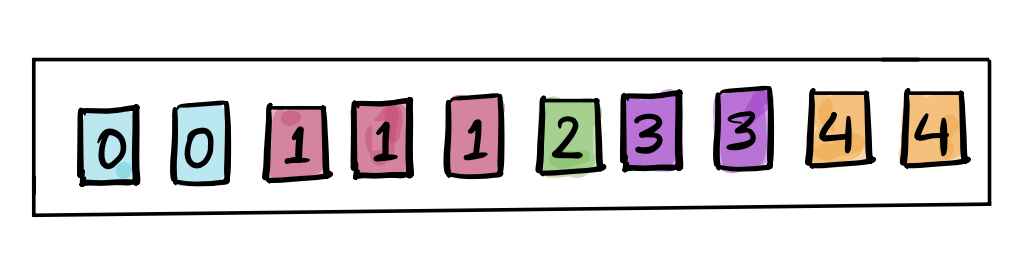

*Hình S2.* Hộp 10 lá thăm dùng cho Ví dụ 5, 6 và 14.
*Nguồn ảnh: bản dịch STAT 20, §4.13. [Tệp ảnh gốc](figures/02_stat20_ten_ticket_box.png).*

**Code.** `np.unique(hop, return_counts=True)` đếm số lá mang mỗi giá trị. `hop.var(ddof=0)` chia cho số lá $N=10$, vì hộp là toàn bộ phân phối đang mô hình hóa.

In [9]:
hop = np.array([0,0,1,1,1,2,3,3,4,4])
gia_tri_hop,so_la = np.unique(hop,return_counts=True)
p_hop = so_la / len(hop)
mu_hop = hop.mean()
var_hop = hop.var(ddof=0)  # Hộp là cả phân phối đang mô hình hóa
sd_hop = np.sqrt(var_hop)
display(pd.DataFrame({"x":gia_tri_hop,"Số lá":so_la,"P(X=x)":p_hop}))
print("E, E(X²), Var, SD:",mu_hop,np.mean(hop**2),var_hop,sd_hop)
assert len(hop)==10 and np.isclose(mu_hop,1.9) and np.isclose(var_hop,2.09)

,x,Số lá,P(X=x)
0,0,2,0.2
1,1,3,0.3
2,2,1,0.1
3,3,2,0.2
4,4,2,0.2


E, E(X²), Var, SD: 1.9 5.7 2.0900000000000003 1.445683229480096


### Tổng và trung bình: luật căn $n$

Cho $X_1,\ldots,X_n$ i.i.d., mỗi biến có kỳ vọng $\mu$ và phương sai $\sigma^2$. Đặt

$$S_n=\sum_{i=1}^n X_i,\qquad \overline X_n=\frac{S_n}n.$$

| Đại lượng | Kỳ vọng | Phương sai | SD |
|---|---|---|---|
| Tổng $S_n$ | $n\mu$ | $n\sigma^2$ | $\sigma\sqrt n$ |
| Trung bình $\overline X_n$ | $\mu$ | $\sigma^2/n$ | $\sigma/\sqrt n$ |

Đọc thành lời (**luật căn $n$**):

- Cộng $n$ lần thì kỳ vọng tăng $n$ lần, nhưng độ lệch chuẩn chỉ tăng $\sqrt n$ lần: các sai lệch có lần dương, có lần âm, nên triệt tiêu một phần.
- Trung bình có kỳ vọng không đổi, còn độ lệch chuẩn **giảm** theo $\sqrt n$. Muốn giảm độ dao động của trung bình đi một nửa, cần số lần đo gấp **bốn**.

Các công thức này **đúng với mọi $n\ge1$**, không cần phân phối chuẩn hay CLT. Đơn vị của tổng và trung bình là đơn vị của mỗi $X_i$.

<details><summary><b>Vì sao?</b> Chứng minh bảng tổng và trung bình</summary>

1. Tính cộng của kỳ vọng (không cần độc lập): $E(S_n)=\mu+\cdots+\mu=n\mu$.
2. Phương sai của tổng các biến độc lập: $\operatorname{Var}(S_n)=\sigma^2+\cdots+\sigma^2=n\sigma^2$.
3. $\overline X_n=\frac1nS_n$. Dùng $E(aX)=aE(X)$ và $\operatorname{Var}(aX)=a^2\operatorname{Var}(X)$ với $a=\frac1n$: $E(\overline X_n)=\mu$ và $\operatorname{Var}(\overline X_n)=\frac1{n^2}\cdot n\sigma^2=\frac{\sigma^2}n$.
4. Lấy căn được cột SD. $\blacksquare$

Nếu rút **không hoàn lại** $n$ lá từ hộp $N$ lá, kỳ vọng không đổi nhưng phương sai của tổng nhân thêm $\frac{N-n}{N-1}$, như ở phân phối siêu bội.

</details>

### Ví dụ 6 — Rút 25 lần rồi tăng lên 100

Dùng hộp 10 lá trên, rút độc lập có hoàn lại $n$ lần. Biết $\mu=1{,}9$, $\sigma^2=2{,}09$. (1) Tính kỳ vọng và SD của tổng và trung bình khi $n=25$. (2) Tính lại khi $n=100$.

<details><summary>Đáp án và cách lập luận</summary>

Dùng bảng trên với $\sigma=\sqrt{2{,}09}\approx1{,}4457$.

| Đại lượng | $n=25$ | $n=100$ |
|---|---:|---:|
| $E(S_n)=n\mu$ | $25\cdot1{,}9=47{,}5$ | $100\cdot1{,}9=190$ |
| $\operatorname{SD}(S_n)=\sigma\sqrt n$ | $\sqrt{25\cdot2{,}09}\approx7{,}228$ | $\sqrt{100\cdot2{,}09}\approx14{,}457$ |
| $E(\overline X_n)=\mu$ | 1,9 | 1,9 |
| $\operatorname{SD}(\overline X_n)=\sigma/\sqrt n$ | $\sqrt{2{,}09/25}\approx0{,}289$ | $\sqrt{2{,}09/100}\approx0{,}145$ |

Cỡ mẫu tăng gấp 4 làm SD của tổng tăng gấp 2, còn SD của trung bình giảm một nửa.

</details>

**Code.** Trong ô dưới, một **hàng** là một mẫu gồm $n$ lần rút, một **cột** là một vị trí rút. `axis=1` cộng hoặc lấy trung bình theo hàng. `so_lan_lap=5000` tạo 5.000 tổng (hoặc trung bình) để quan sát phân phối của chúng; số này khác với cỡ mẫu $n$.

In [10]:
so_lan_lap = 5000  # Thử đổi: số mẫu lặp để quan sát phân phối
co_mau = [25,100]   # Thử thêm cỡ mẫu; giữ 25 và 100 để đối chiếu hình/slide phía sau
ket_qua_hop = {}
bang_so_sanh = []
for n in co_mau:
    mau = rng.choice(hop,size=(so_lan_lap,n),replace=True)
    tong = mau.sum(axis=1)
    trung_binh = mau.mean(axis=1)
    ket_qua_hop[n] = {"tong":tong,"trung_binh":trung_binh}
    bang_so_sanh.append({"n":n,"E tổng":n*mu_hop,"TB các tổng":tong.mean(),
                         "SD tổng lý thuyết":sd_hop*np.sqrt(n),"SD tổng mô phỏng":tong.std(ddof=0),
                         "E trung bình":mu_hop,"TB các trung bình":trung_binh.mean(),
                         "SD trung bình lý thuyết":sd_hop/np.sqrt(n),
                         "SD trung bình mô phỏng":trung_binh.std(ddof=0)})
display(pd.DataFrame(bang_so_sanh).set_index("n"))

,E tổng,TB các tổng,SD tổng lý thuyết,SD tổng mô phỏng,E trung bình,TB các trung bình,SD trung bình lý thuyết,SD trung bình mô phỏng
n,,,,,,,,
25,47.5,47.5928,7.22842,7.42346,1.9,1.90371,0.28914,0.29694
100,190.0,189.8150,14.45683,14.43881,1.9,1.89815,0.14457,0.14439


Với seed 42, các ước lượng mô phỏng gần các giá trị lý thuyết. Ở đây `std(ddof=0)` mô tả toàn bộ 5.000 kết quả mô phỏng; đó không phải công thức $s$ ước lượng từ một mẫu nhỏ. Hãy phân biệt ba thứ: SD của một lá, SD của tổng, SD của trung bình.

<details><summary><b>Vì sao?</b> Phương sai mẫu $s^2$ chia cho $n-1$</summary>

Ở Tuần 02, phương sai mẫu là $s^2=\frac1{n-1}\sum(X_i-\overline X)^2$. Với $X_1,\ldots,X_n$ i.i.d. có phương sai $\sigma^2$, ta chứng minh $E(s^2)=\sigma^2$: tính trung bình qua mọi mẫu có thể, $s^2$ cho **đúng** $\sigma^2$.

1. Công thức tính nhanh của Tuần 02: $\sum(X_i-\overline X)^2=\sum X_i^2-n\overline X^2$.
2. Từ $E(Y^2)=\operatorname{Var}(Y)+[E(Y)]^2$: $E(X_i^2)=\sigma^2+\mu^2$ và $E(\overline X^2)=\frac{\sigma^2}n+\mu^2$.
3. Lấy kỳ vọng hai vế ở bước 1:
$$E\Big[\sum(X_i-\overline X)^2\Big]=n(\sigma^2+\mu^2)-n\Big(\frac{\sigma^2}n+\mu^2\Big)=(n-1)\sigma^2.$$
4. Chia cho $n-1$ được $E(s^2)=\sigma^2$. $\blacksquare$

Nếu chia cho $n$, kỳ vọng là $\frac{n-1}n\sigma^2$, luôn nhỏ hơn $\sigma^2$ một chút. Phần thiếu $\frac{\sigma^2}n$ chính là phương sai của $\overline X$: đo độ lệch quanh $\overline X$ thay vì quanh $\mu$ làm mất một phần độ phân tán. Với hộp (toàn bộ phân phối), ta chia cho $N$ vì không ước lượng gì cả.

</details>

### Bước đi ngẫu nhiên và roulette (theo STAT 20)

Mỗi phút một người đi thêm $+1$ hoặc $-1$ bước, độc lập, xác suất $\frac12$ mỗi hướng. Vị trí sau $n$ phút là $S_n$, không phải tổng quãng đường đi được (quãng đường luôn bằng $n$). Một bước có $E(X)=0$ và $\operatorname{Var}(X)=1$, nên $E(S_n)=0$ và $\operatorname{SD}(S_n)=\sqrt n$. Sau 100 bước, người đi thường cách gốc khoảng 10 bước: không phải 0, cũng không phải 100.

Ô code vẽ một đường đi 30 bước và phân phối điểm cuối của 5.000 đường đi khác nhau. Trục thời gian ở hình trái không có nghĩa người đó đi theo hai chiều; vị trí vẫn nằm trên một trục. Sau 30 bước, vị trí chỉ có thể là số chẵn. Vì $S_{30}=2B-30$ với $B\sim\operatorname{Binomial}(30;\ 0{,}5)$ là số bước $+1$, ta có $P(S_{30}=4)=P(B=17)$.

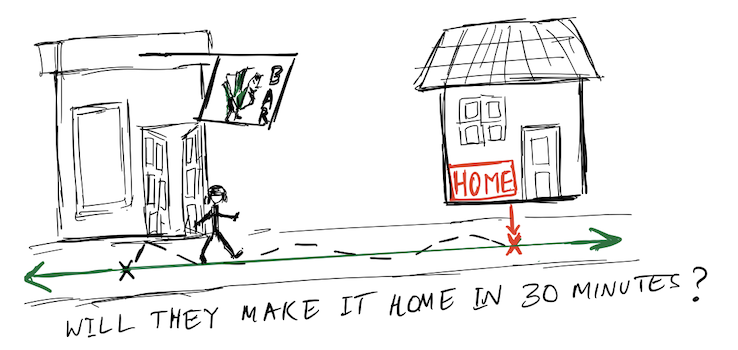

*Hình S3.* Một bước đi ngẫu nhiên trên đường thẳng.
*Nguồn ảnh: bản dịch STAT 20, §4.12. [Tệp ảnh gốc](figures/03_stat20_random_walk_scene.png).*

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. `geom_rect` vẽ mỗi hình chữ nhật từ các cận `xmin`, `xmax`, `ymin` và `ymax`. `geom_hline` thêm đường ngang tại `yintercept`. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

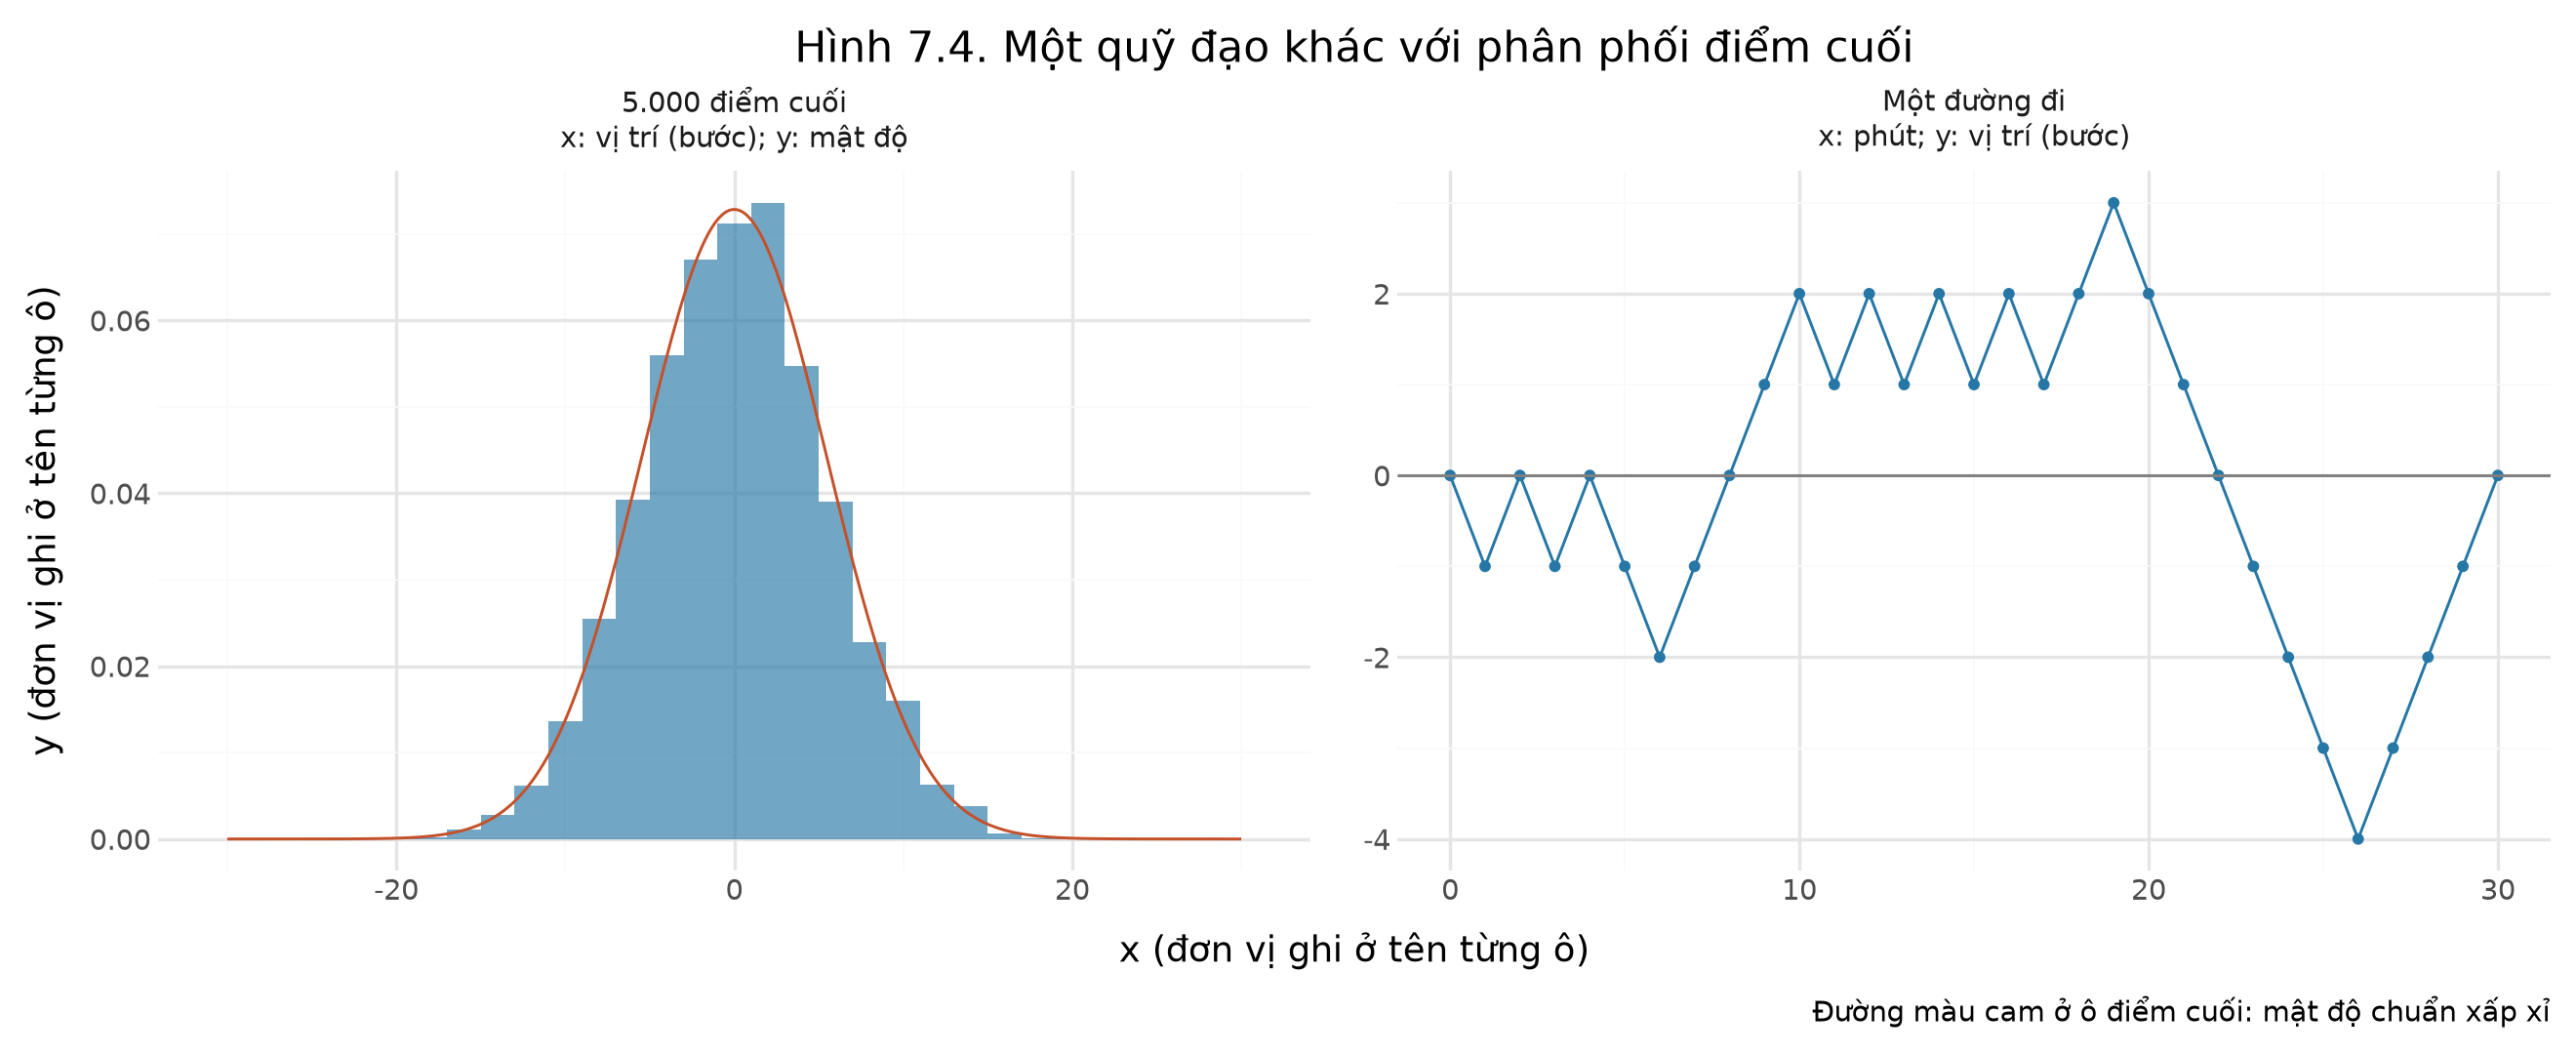

P(S30 = 4) chính xác: 0.1115350518375634


In [11]:
n_buoc = 30  # Thử đổi; n quyết định miền giá trị và SD điểm cuối
buoc = rng.choice([-1,1],size=n_buoc)
vi_tri = np.r_[0,buoc.cumsum()]
diem_cuoi = rng.choice([-1,1],size=(5000,n_buoc)).sum(axis=1)
nhan_duong="Một đường đi\nx: phút; y: vị trí (bước)"
nhan_diem="5.000 điểm cuối\nx: vị trí (bước); y: mật độ"
bang_duong=pd.DataFrame({"x":np.arange(n_buoc+1),"y":vi_tri,"o":nhan_duong})
cao,bien=np.histogram(diem_cuoi,bins=np.arange(-n_buoc-1,n_buoc+2,2),density=True)
bang_hist=pd.DataFrame({"trai":bien[:-1],"phai":bien[1:],"cao":cao,"o":nhan_diem})
luoi = np.linspace(-n_buoc,n_buoc,300)
bang_chuan=pd.DataFrame({"x":luoi,"y":stats.norm.pdf(luoi,scale=np.sqrt(n_buoc)),"o":nhan_diem})
bang_nen=pd.concat([bang_duong,bang_chuan],ignore_index=True)
hinh = (p9.ggplot(bang_nen)
    + p9.geom_line(bang_duong,p9.aes("x","y"),color="#2677A6")
    + p9.geom_point(bang_duong,p9.aes("x","y"),color="#2677A6",size=1)
    + p9.geom_hline(pd.DataFrame({"o":[nhan_duong],"moc":[0]}),p9.aes(yintercept="moc"),color="gray")
    + p9.geom_rect(bang_hist,p9.aes(xmin="trai",xmax="phai",ymin=0,ymax="cao"),fill="#2677A6",alpha=0.65)
    + p9.geom_line(bang_chuan,p9.aes("x","y"),color="#C4512A")
    + p9.facet_wrap("o",ncol=2,scales="free")
    + p9.labs(x="x (đơn vị ghi ở tên từng ô)",y="y (đơn vị ghi ở tên từng ô)",
              title="Hình 7.4. Một quỹ đạo khác với phân phối điểm cuối",
              caption="Đường màu cam ở ô điểm cuối: mật độ chuẩn xấp xỉ")
    + p9.theme(figure_size=(11,4.5)))
display(hinh)
print("P(S30 = 4) chính xác:",stats.binom.pmf(17,n=30,p=0.5))

Đường cong chuẩn xấp xỉ **hình dạng** phân phối điểm cuối; còn xác suất tại một vị trí rời rạc phải tính bằng nhị thức. Đừng dùng mật độ chuẩn tại một điểm để tính $P(S_{30}=4)$: biến liên tục có xác suất tại một điểm bằng 0 (mục 5).

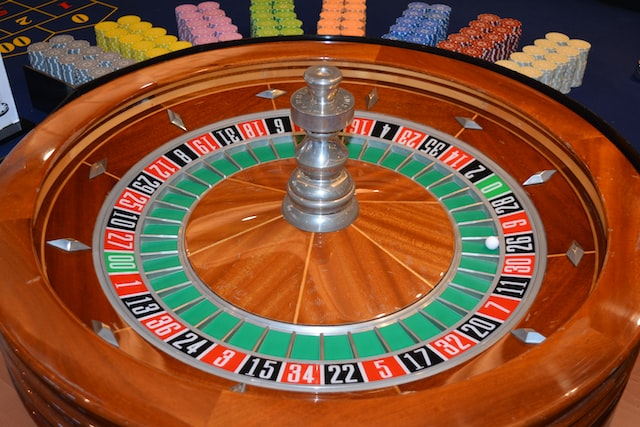

*Hình S4.* Bánh xe roulette kiểu Mỹ: 18 đỏ, 18 đen và 2 xanh.
*Nguồn ảnh: bản dịch STAT 20, §4.13.1.2. [Tệp ảnh gốc](figures/04_stat20_roulette_photo.jpg).*

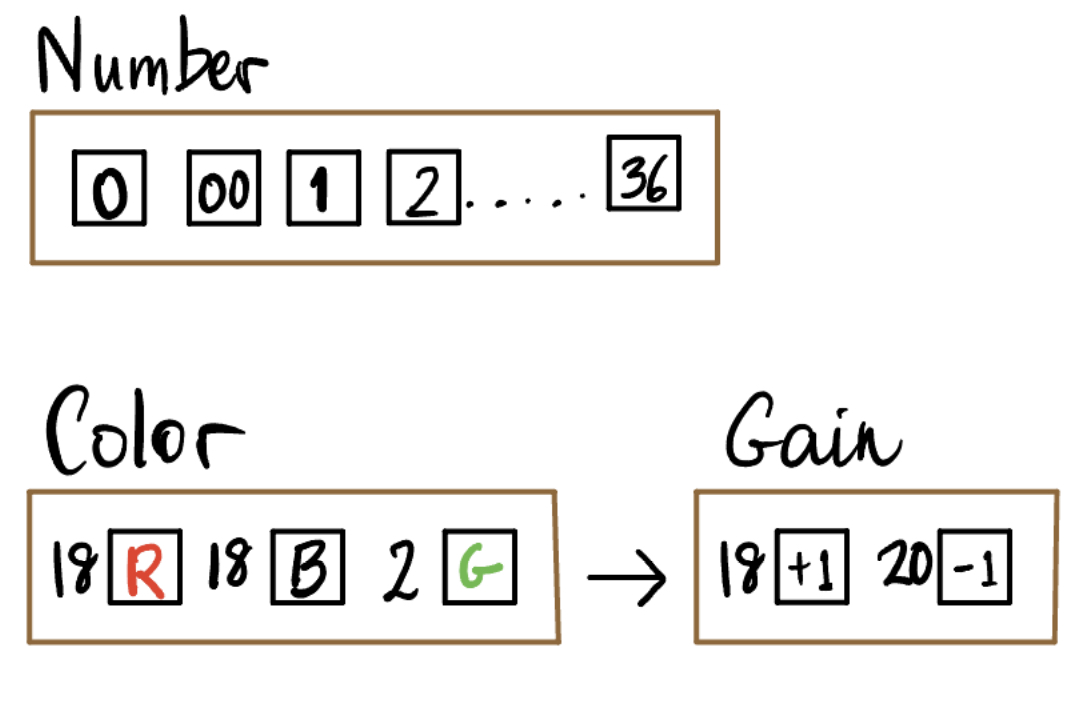

*Hình S5.* Từ ô trên bánh xe sang hộp lợi nhuận: 18 lá $+1$, 20 lá $-1$.
*Nguồn ảnh: bản dịch STAT 20, §4.13.1.2. [Tệp ảnh gốc](figures/05_stat20_roulette_gain_box.jpg).*

Cược 1 đô la vào đỏ: lợi nhuận ròng $G=+1$ với xác suất $\frac{18}{38}$, $G=-1$ với xác suất $\frac{20}{38}$ (cả đen và xanh đều thua). Tiền cược trả lại khi thắng không phải lợi nhuận mới.

- $E(G)=\frac{18}{38}-\frac{20}{38}=-\frac1{19}\approx-0{,}05263$ đô la: trung bình mỗi lượt mất khoảng 5,26 xu.
- $G^2=1$ luôn đúng, nên $E(G^2)=1$ và $\operatorname{Var}(G)=1-\frac1{19^2}=\frac{360}{361}$, $\operatorname{SD}(G)\approx0{,}9986$.

Một lượt dao động gần 1 đô la, lớn gấp khoảng 19 lần mức lỗ trung bình, nên người chơi vẫn hay thắng trong ngắn hạn. Sau 100 lượt độc lập, tổng lợi nhuận có kỳ vọng $-\frac{100}{19}\approx-5{,}26$ đô la và SD khoảng $0{,}9986\sqrt{100}\approx9{,}99$ đô la. Mục 7 sẽ tính xác suất người chơi còn có lời.

<a id="hoc-3f09a959"></a>
## 4. Cận xác suất và luật số lớn yếu

### Markov và Chebyshev: cận trên không cần biết hình dạng

**Bất đẳng thức Markov.** Nếu $X\ge0$ và $a>0$ thì

$$P(X\ge a)\le\frac{E(X)}a.$$

Đọc là: một biến không âm hiếm khi lớn hơn nhiều lần kỳ vọng của nó. Ví dụ: thu nhập trung bình 10 triệu thì không quá $\frac15$ số người có thu nhập từ 50 triệu trở lên; nếu nhiều hơn, riêng nhóm đó đã kéo trung bình vượt 10 triệu.

**Bất đẳng thức Chebyshev.** Nếu $X$ có kỳ vọng $\mu$ và phương sai $\sigma^2$, thì với mọi mức sai lệch $\varepsilon>0$:

$$P(\lvert X-\mu\rvert\ge\varepsilon)\le\frac{\sigma^2}{\varepsilon^2}.$$

Đọc là: xác suất $X$ lệch khỏi kỳ vọng từ $\varepsilon$ trở lên không vượt quá phương sai chia $\varepsilon^2$. Đặt $\varepsilon=k\sigma$ được dạng dễ nhớ: $P(\lvert X-\mu\rvert\ge k\sigma)\le\frac1{k^2}$.

$\varepsilon$ có cùng đơn vị với $X$, nên tỉ số không có đơn vị và so được với xác suất. Đây là **cận trên**, không phải xác suất chính xác; nếu tỉ số lớn hơn 1 thì cận không cho thông tin gì. Chebyshev đúng với **mọi** phân phối có phương sai hữu hạn, và cái giá là nó khá rộng:

| Lệch khỏi tâm từ $k$ SD trở lên | Chebyshev: tối đa | Nếu phân phối là chuẩn |
|---|---:|---:|
| $k=2$ | 25% | 4,6% |
| $k=3$ | 11,1% | 0,27% |

Với trung bình của $n$ biến i.i.d., thay phương sai bằng $\sigma^2/n$:

$$P(\lvert\overline X_n-\mu\rvert\ge\varepsilon)\le\frac{\sigma^2}{n\varepsilon^2}.$$

<details><summary><b>Vì sao?</b> Chứng minh Markov rồi Chebyshev</summary>

*Markov (biến rời rạc).* Các số hạng trong $E(X)$ đều không âm. Bỏ các số hạng có $x<a$ thì tổng chỉ giảm; trong các số hạng còn lại, thay $x$ bằng số nhỏ hơn là $a$:
$$E(X)=\sum_x x\,p_X(x)\ \ge\ \sum_{x\ge a}x\,p_X(x)\ \ge\ \sum_{x\ge a}a\,p_X(x)=a\,P(X\ge a).$$
Chia hai vế cho $a$. Với biến liên tục, thay tổng bằng tích phân.

*Chebyshev.* Biến cố $\{\lvert X-\mu\rvert\ge\varepsilon\}$ trùng với $\{(X-\mu)^2\ge\varepsilon^2\}$. Biến $(X-\mu)^2$ không âm, có kỳ vọng $\sigma^2$. Áp dụng Markov với $a=\varepsilon^2$. $\blacksquare$

</details>

### Bài tập 3 — Đo nhiệt độ lò sấy

Mỗi phép đo nhiệt độ lò là không chệch: $E(X_i)=\mu$, nhiệt độ thật. Các phép đo i.i.d., SD $1\,{}^\circ$C. Tìm số lần đo đủ để xác suất trung bình sai khác nhiệt độ thật không quá $0{,}2\,{}^\circ$C đạt ít nhất 99%, dùng Chebyshev; không giả định chuẩn.

<details><summary>Đáp án và cách lập luận</summary>

*Bước 1.* Cần $P(\lvert\overline X_n-\mu\rvert>0{,}2)\le0{,}01$.

*Bước 2: Chebyshev cho trung bình* với $\sigma=1$, $\varepsilon=0{,}2$:
$$P(\lvert\overline X_n-\mu\rvert>0{,}2)\le\frac1{n(0{,}2)^2}=\frac{25}{n}.$$

*Bước 3.* Muốn cận trên không quá $0{,}01$: $\frac{25}n\le0{,}01$, tức $n\ge2500$.

**2.500 lần đo là đủ theo cận**, bất kể phép đo có phân phối gì. Đó không nhất thiết là số tối thiểu cho phân phối thực tế; mục 7 sẽ thấy nếu dùng xấp xỉ chuẩn thì khoảng 166 lần là đủ. Phép đo không chệch và độc lập là giả định cần cho cách tính này.

</details>

Bảng ở ô dưới cho thấy tăng $n$ làm cận giảm. Không cần mô phỏng 2.500 phép đo: bảo đảm được suy ra từ bất đẳng thức.

In [12]:
epsilon = 0.2  # Thử đổi mức sai lệch cho phép (độ C)
xac_suat_sai_toi_da = 0.01
n_du = int(np.ceil(1 / (xac_suat_sai_toi_da * epsilon**2)))
print("Số lần đo đủ theo Chebyshev:",n_du)
display(pd.DataFrame({"n":[100,500,2500,10000],
                      "Cận trên xác suất sai lệch":[min(1,1/(n*epsilon**2)) for n in [100,500,2500,10000]]}))

Số lần đo đủ theo Chebyshev: 2500


,n,Cận trên xác suất sai lệch
0,100,0.2500
1,500,0.0500
2,2500,0.0100
3,10000,0.0025


### Luật số lớn yếu và Bài tập 4 — Đồng xu có "bù" không?

Cho $X_1,X_2,\ldots$ i.i.d. có kỳ vọng $\mu$. Với mọi $\varepsilon>0$:

$$P(\lvert\overline X_n-\mu\rvert>\varepsilon)\longrightarrow0\quad\text{khi }n\to\infty.$$

Đọc thành lời: chọn trước một mức sai lệch $\varepsilon$, dù nhỏ đến đâu. Khi số lần lặp đủ lớn, khả năng trung bình mẫu lệch khỏi $\mu$ quá $\varepsilon$ trở nên nhỏ tùy ý. Cách hội tụ này gọi là **hội tụ theo xác suất**.

**Hệ quả: tần suất tiến về xác suất.** Đặt $X_i=1$ nếu biến cố $A$ xảy ra ở lần thứ $i$, và 0 nếu không. Khi đó $\overline X_n$ là tần suất của $A$, và $\mu=P(A)$. Đây là cơ sở cho việc dùng mô phỏng để ước lượng xác suất trong mọi notebook.

<details><summary><b>Vì sao?</b> Chứng minh luật số lớn khi phương sai hữu hạn</summary>

Theo Chebyshev cho trung bình:
$$0\le P(\lvert\overline X_n-\mu\rvert>\varepsilon)\le\frac{\sigma^2}{n\varepsilon^2}.$$
Vế phải tiến về 0 khi $n\to\infty$. Đại lượng ở giữa bị kẹp giữa 0 và một số tiến về 0, nên cũng tiến về 0. $\blacksquare$

*Điều kiện kỹ thuật.* Phát biểu đầy đủ chỉ cần $E\lvert X_1\rvert<\infty$, không cần phương sai hữu hạn; chứng minh trường hợp đó vượt ra ngoài học phần. Mọi ví dụ của học phần đều có phương sai hữu hạn.

</details>

**Luật số lớn không có nghĩa là "sẽ được bù lại".** Sau 10 lần ngửa liên tiếp, tung thêm $n$ lần đồng xu cân đối, tỉ lệ ngửa kỳ vọng là $\frac{10+n/2}{10+n}$:

| Tung thêm $n$ lần | 10 | 100 | 1000 |
|---|---:|---:|---:|
| Tỉ lệ ngửa kỳ vọng | 0,750 | 0,545 | 0,505 |

Tỉ lệ tiến về 0,5 vì 10 lần ngửa ban đầu bị **pha loãng** bởi rất nhiều lần tung sau, không phải vì được bù. Số lần ngửa vượt sấp vẫn có kỳ vọng là 10.

**Bài tập 4.** Sau 10 lần tung đồng xu cân đối đều ra sấp, luật số lớn có bảo đảm lần thứ 11 ra ngửa không? Tỉ lệ mặt ngửa có buộc tăng đều về 0,5 không?

<details><summary>Đáp án và cách lập luận</summary>

*Lần 11.* Không. Các lần tung độc lập, nên $P(\text{ngửa ở lần 11}\mid\text{10 lần sấp})=P(\text{ngửa})=0{,}5$. Đồng xu không nhớ 10 kết quả cũ.

*Tỉ lệ tích lũy.* Không. Tỉ lệ có thể tăng hoặc giảm ở từng bước. Luật số lớn nói về **xác suất** sai lệch của trung bình khi cỡ mẫu tăng; nó không hứa mỗi bước đi gần kỳ vọng hơn.

</details>

Hình dưới dùng đồng xu có $p=0{,}7$: `rng.binomial(1, p_ngua, size=so_lan_tung)` sinh 5.000 lần tung; `cumsum` chia cho $1,2,\ldots$ ra tỉ lệ ngửa tích lũy. Hãy quan sát các đoạn tăng và giảm quanh đường ngang 0,7.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='so_lan', y='ty_le'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_hline` thêm đường ngang tại `yintercept`. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

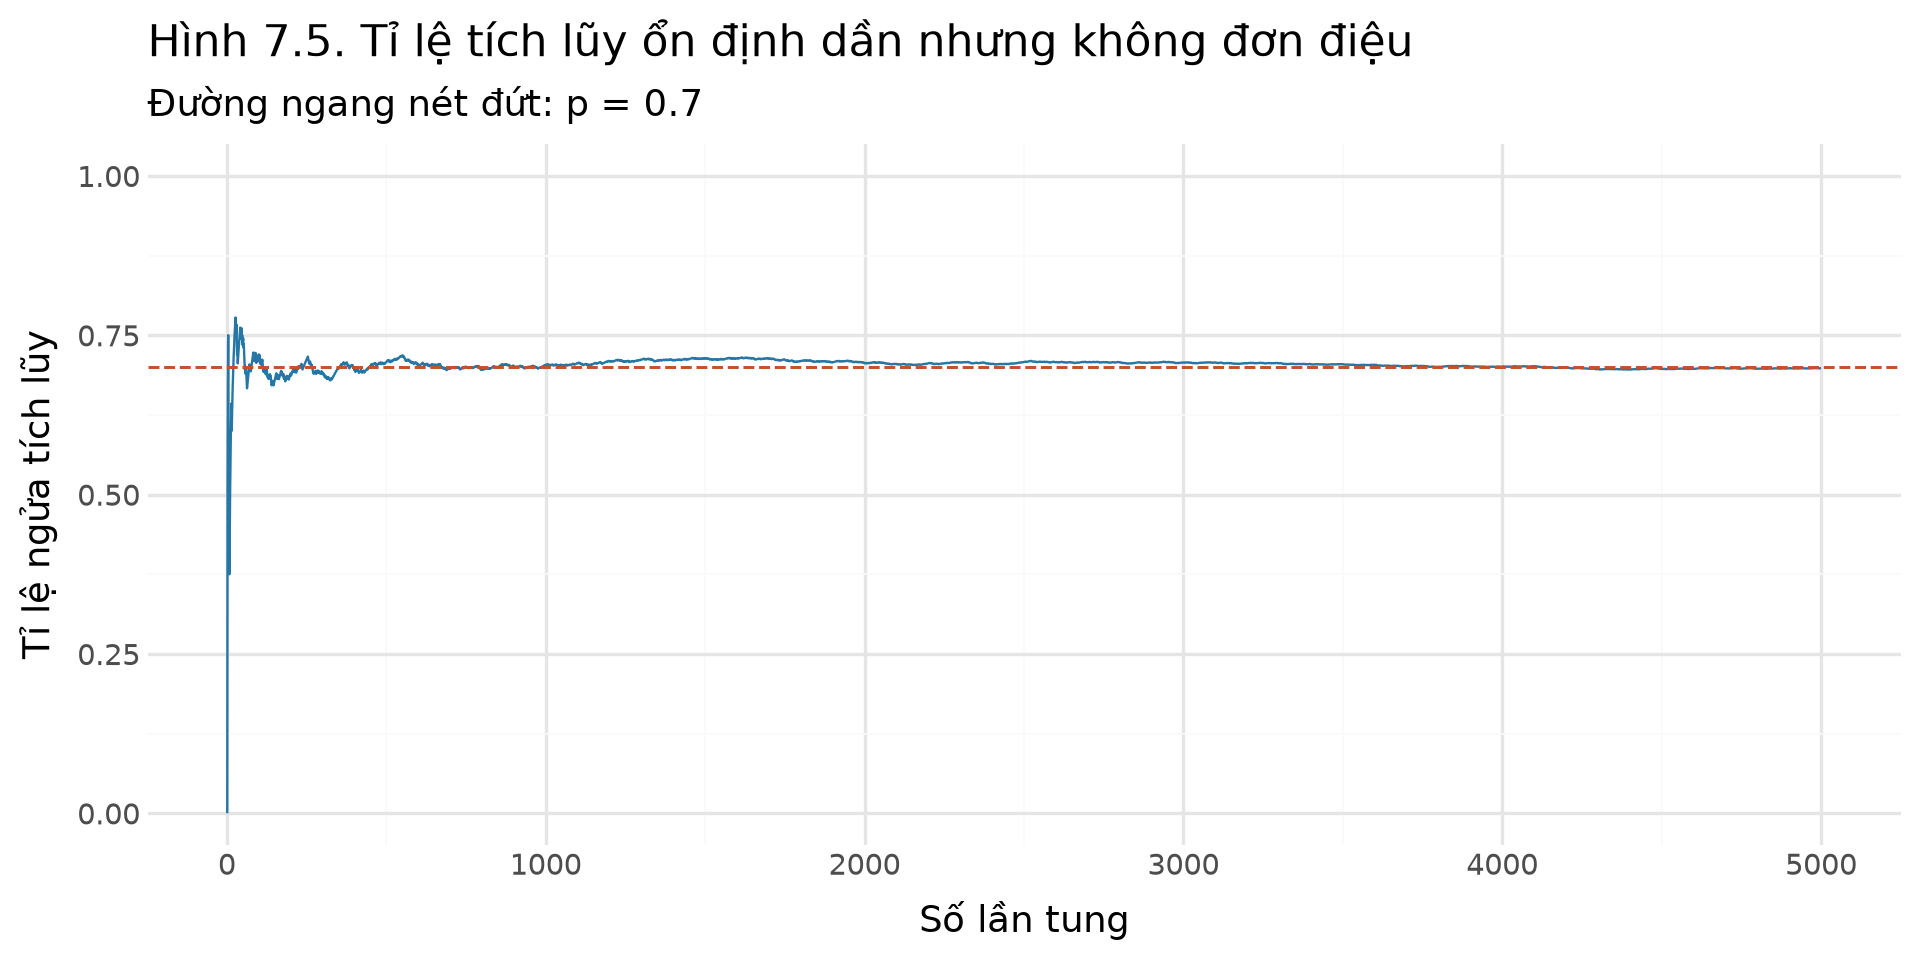

In [13]:
p_ngua = 0.7  # Thử đổi xác suất ngửa
so_lan_tung = 5000
tung = rng.binomial(1,p_ngua,size=so_lan_tung)
ty_le_tich_luy = tung.cumsum()/np.arange(1,so_lan_tung+1)
bang_tich_luy=pd.DataFrame({"so_lan":np.arange(1,so_lan_tung+1),"ty_le":ty_le_tich_luy})
hinh = (p9.ggplot(bang_tich_luy,p9.aes("so_lan","ty_le"))
    + p9.geom_line(color="#2677A6",size=0.4)
    + p9.geom_hline(yintercept=p_ngua,color="#C4512A",linetype="dashed")
    + p9.coord_cartesian(ylim=(0,1))
    + p9.labs(x="Số lần tung",y="Tỉ lệ ngửa tích lũy",
              title="Hình 7.5. Tỉ lệ tích lũy ổn định dần nhưng không đơn điệu",
              subtitle=f"Đường ngang nét đứt: p = {p_ngua}"))
display(hinh)

*Thử thay đổi.* Giảm `so_lan_tung` xuống 50 để thấy rõ dao động ngắn hạn.

Luật số lớn giải thích vì sao trung bình dài hạn ở Ví dụ 1 là 1,6. Mức dao động của trung bình là nội dung của công thức $\sigma/\sqrt n$. Định lý giới hạn trung tâm (mục 7) trả lời thêm câu hỏi về **hình dạng** phân phối.

<a id="hoc-2628c704"></a>
## 5. Biến liên tục: xác suất là diện tích

Thời gian chờ, chiều cao, dung tích chai nhận giá trị trên cả một khoảng. Với những biến này, xác suất được tính bằng **diện tích** dưới một đường cong.

<details><summary><b>Nhắc lại</b> Tích phân (Giải tích 1)</summary>

*Tích phân là diện tích.* Với $f(x)\ge0$, $\int_a^b f(x)\,dx$ là diện tích vùng dưới đồ thị $f$ và trên trục hoành, giữa $x=a$ và $x=b$.

*Tích phân là giới hạn của một tổng.* Chia $[a,b]$ thành nhiều khoảng nhỏ rộng $\Delta x$; trên mỗi khoảng, diện tích gần bằng một hình chữ nhật cao $f(x_j)$, rộng $\Delta x$:
$$\int_a^b f(x)\,dx\approx\sum_j f(x_j)\,\Delta x.$$
Vì vậy mỗi khi thấy $\sum_x(\cdots)\,p_X(x)$ ở biến rời rạc, phiên bản liên tục là $\int(\cdots)\,f_X(x)\,dx$.

| Công cụ | Công thức |
|---|---|
| Định lý cơ bản | nếu $F'=f$ thì $\int_a^b f(x)\,dx=F(b)-F(a)$ |
| Tuyến tính | $\int(af+bg)=a\int f+b\int g$ |
| Lũy thừa | $\int x^k\,dx=\dfrac{x^{k+1}}{k+1}+C$, với $k\ne-1$ |
| Hàm mũ | $\int e^{-\lambda x}\,dx=-\dfrac1\lambda e^{-\lambda x}+C$ |
| Cận vô cùng | $\int_a^\infty f(x)\,dx=\lim_{t\to\infty}\int_a^t f(x)\,dx$ |
| Từng phần | $\int_a^b u\,dv=\big[uv\big]_a^b-\int_a^b v\,du$ |
| Đổi biến | với $t=(x-\mu)/\sigma$ thì $dx=\sigma\,dt$, và cận đổi theo |

Giới hạn hay dùng: với $\lambda>0$, $x^ke^{-\lambda x}\to0$ khi $x\to\infty$; hàm mũ giảm nhanh hơn mọi lũy thừa tăng.

</details>

### Hàm mật độ

Vẽ histogram theo thang mật độ (Tuần 02) của rất nhiều quan sát: diện tích mỗi cột bằng tỉ lệ quan sát rơi vào khoảng đó. Càng nhiều dữ liệu và khoảng chia càng hẹp, đỉnh các cột càng gần một đường cong trơn. Đường cong đó là **hàm mật độ xác suất** (probability density function, pdf) $f_X$. Nó thỏa

$$f_X(x)\ge0,\qquad \int_{-\infty}^{\infty}f_X(x)\,dx=1,\qquad P(a<X<b)=\int_a^b f_X(x)\,dx.$$

Đọc là: mật độ không âm; tổng diện tích dưới đường cong bằng 1; xác suất trong một khoảng là diện tích trên khoảng đó.

- **Một điểm không có bề rộng**, nên $P(X=a)=0$. Vì vậy đóng hay mở các đầu mút không làm đổi xác suất; cái bẫy $<$ và $\le$ của biến rời rạc không còn.
- **$f_X(x)$ là mật độ, không phải xác suất tại $x$**, và có thể lớn hơn 1. Gần đúng, $f_X(x)\,\Delta x\approx P(x<X\le x+\Delta x)$ khi $\Delta x$ nhỏ. Nếu $X$ đo bằng phút, mật độ có đơn vị $1/\text{phút}$, còn diện tích không có đơn vị.

<details><summary><b>Vì sao?</b> Xác suất tại một điểm bằng 0</summary>

Với mọi $h>0$, biến cố $\{X=a\}$ nằm trong $\{a-h<X\le a\}$. Theo tính đơn điệu của xác suất:
$$0\le P(X=a)\le\int_{a-h}^{a}f_X(x)\,dx.$$
Cho $h\to0$, vế phải là diện tích của một dải ngày càng hẹp, tiến về 0. Vậy $P(X=a)=0$. $\blacksquare$

Ở học phần này, "biến liên tục" nghĩa là biến có hàm mật độ.

</details>

### Bài tập 5 — Mật độ cao 2 có hợp lệ?

Cho $f(x)=2$ khi $0<x<0{,}5$ và bằng 0 ngoài khoảng ấy. Đây có phải hàm mật độ hợp lệ không?

<details><summary>Đáp án và cách lập luận</summary>

Kiểm tra hai điều kiện:

1. $f(x)\ge0$ với mọi $x$: đúng.
2. Tổng diện tích: hình chữ nhật cao 2, rộng 0,5, nên $\int_0^{0{,}5}2\,dx=2\cdot0{,}5=1$: đúng.

Vậy $f$ hợp lệ. Chiều cao 2 không phải xác suất 200%; xác suất là **diện tích**.

</details>

### Hàm phân phối tích lũy và Ví dụ 7 — Mật độ tăng tuyến tính

Với mọi biến $X$, **hàm phân phối tích lũy** (cdf) là $F_X(x)=P(X\le x)$. Nếu có mật độ:

$$F_X(x)=\int_{-\infty}^x f_X(t)\,dt,\qquad P(a<X<b)=F_X(b)-F_X(a).$$

Đọc là: cdf là diện tích bên trái điểm $x$. $t$ là biến tích phân, $x$ là điểm dừng. Theo định lý cơ bản của giải tích, $F_X'(x)=f_X(x)$ tại những điểm $f_X$ liên tục: mật độ là tốc độ tăng của xác suất tích lũy. Cdf không có đơn vị, không giảm, nằm trong $[0,1]$.

**Ví dụ 7.** $f(x)=2x$ trên $0<x<1$, bằng 0 ở nơi khác. (1) Tìm cdf trên **toàn bộ** trục số. (2) Tính $P(0{,}2<X<0{,}6)$.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.* Xét ba miền.

- $x\le0$: chưa có diện tích nào, $F_X(x)=0$.
- $0<x<1$: $F_X(x)=\int_0^x2t\,dt=\big[t^2\big]_0^x=x^2$.
- $x\ge1$: đã lấy hết diện tích, $F_X(x)=1$.

$$F_X(x)=\begin{cases}0,&x\le0,\\x^2,&0<x<1,\\1,&x\ge1.\end{cases}$$

Không kéo công thức $x^2$ ra ngoài $(0,1)$, vì cdf không thể lớn hơn 1.

*Câu 2.* $P(0{,}2<X<0{,}6)=F_X(0{,}6)-F_X(0{,}2)=0{,}36-0{,}04=0{,}32$.

</details>

Hình dưới đặt pdf và cdf cạnh nhau. Vùng tô dưới pdf bằng mức tăng của cdf từ 0,2 đến 0,6; hai trục tung có ý nghĩa khác nhau. `integrate.quad(lambda t: 2*t, 0.2, 0.6)` tính lại diện tích bằng số.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='y'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_point` mỗi điểm lấy tọa độ từ hai biến được ánh xạ vào `x` và `y`. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. `geom_ribbon` tô miền giữa hai cận `ymin` và `ymax`. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

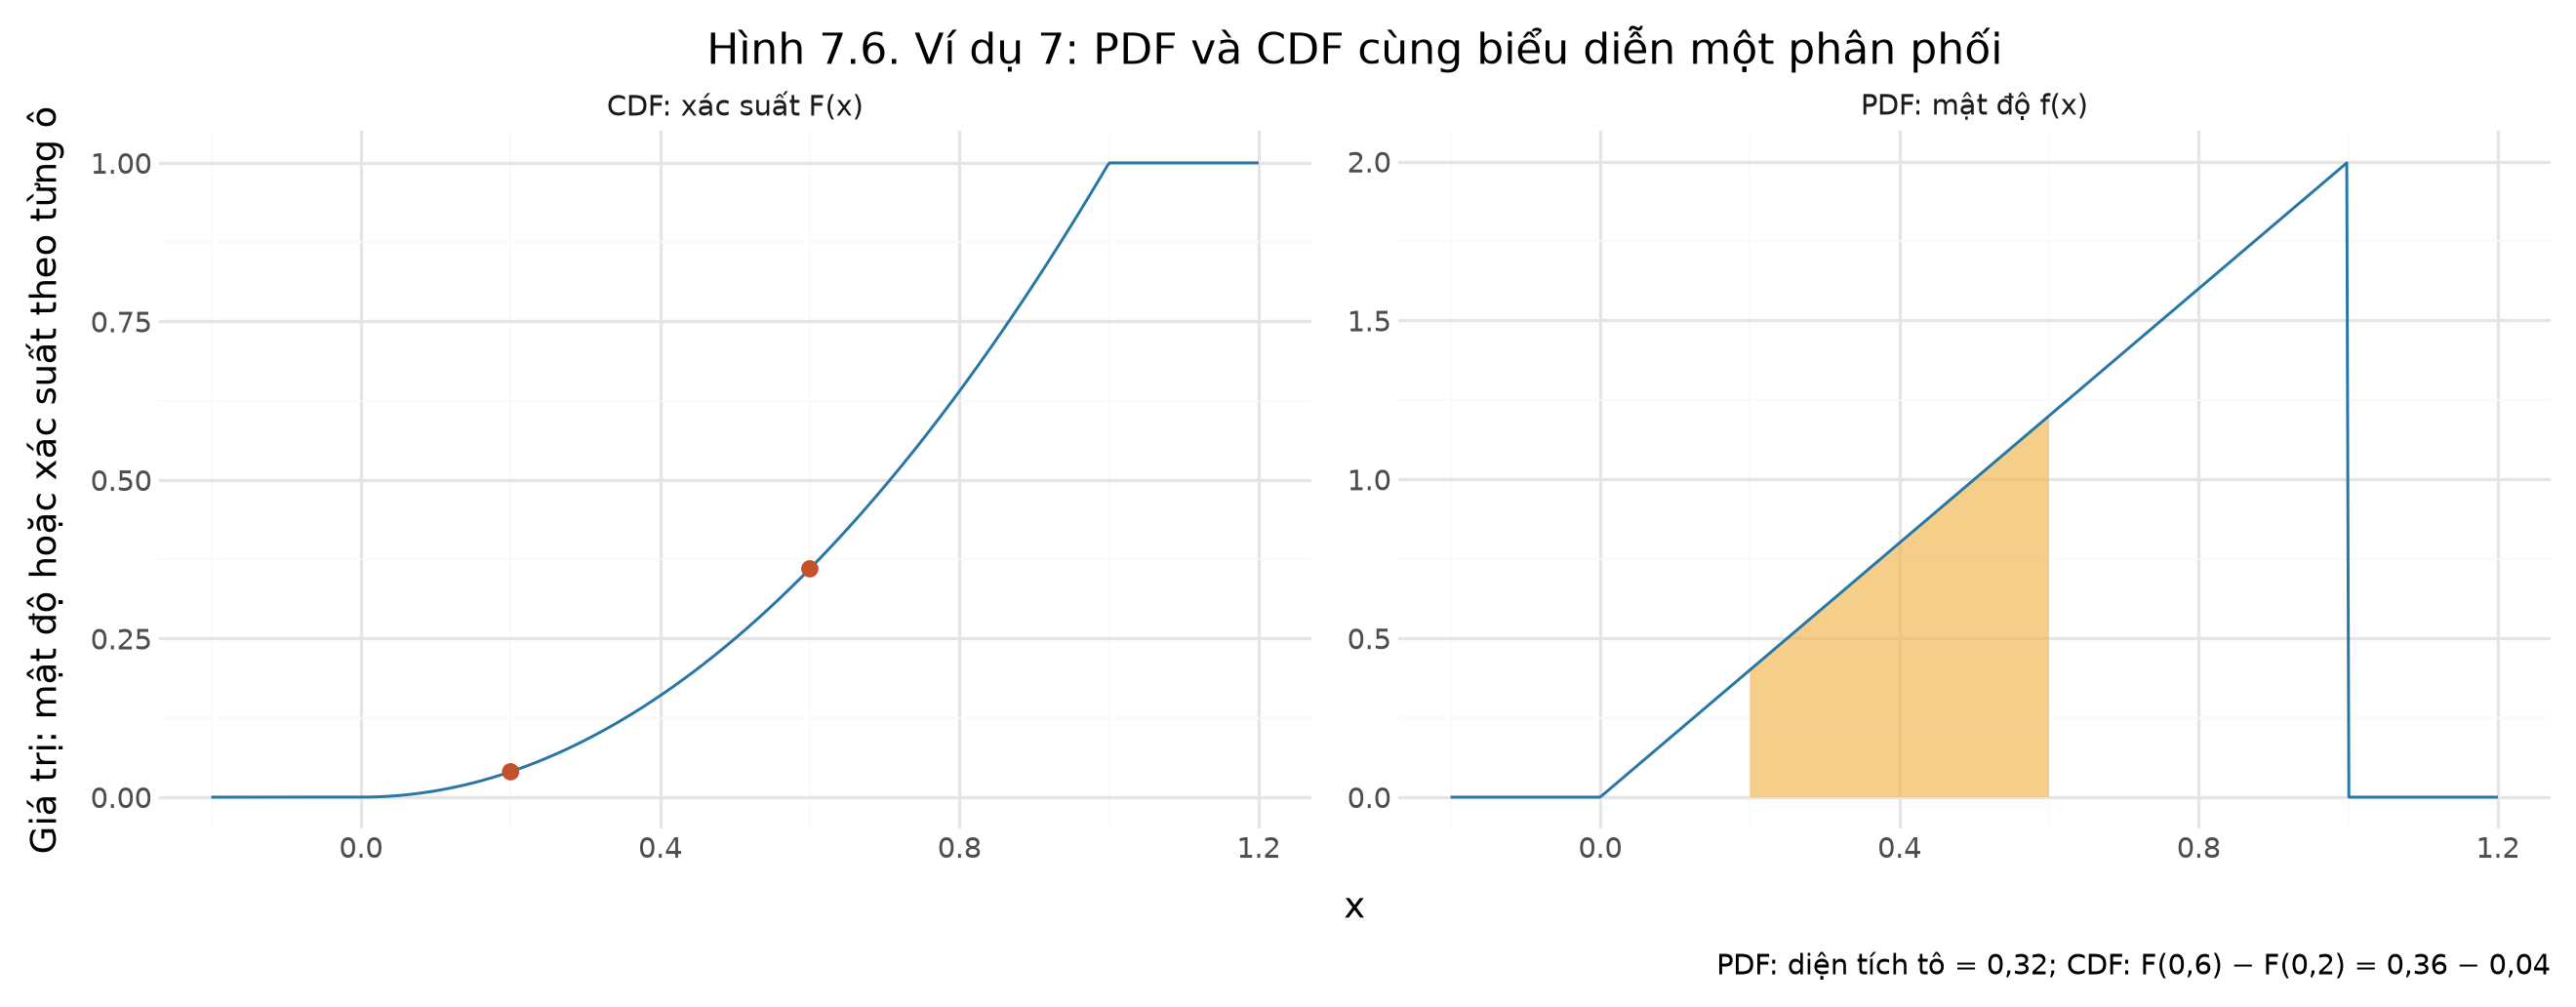

Diện tích khoảng cần tính: 0.32000000000000006


In [14]:
luoi = np.linspace(-0.2,1.2,500)
pdf_tam_giac = np.where((luoi>0)&(luoi<1),2*luoi,0)
cdf_tam_giac = np.clip(luoi,0,1)**2
nhan_pdf="PDF: mật độ f(x)"
nhan_cdf="CDF: xác suất F(x)"
bang_duong=pd.concat([pd.DataFrame({"x":luoi,"y":pdf_tam_giac,"o":nhan_pdf}),
                      pd.DataFrame({"x":luoi,"y":cdf_tam_giac,"o":nhan_cdf})],ignore_index=True)
vung = np.linspace(0.2,0.6,100)
bang_vung=pd.DataFrame({"x":vung,"y":2*vung,"o":nhan_pdf})
bang_diem=pd.DataFrame({"x":[0.2,0.6],"y":[0.2**2,0.6**2],"o":nhan_cdf})
hinh = (p9.ggplot(bang_duong,p9.aes("x","y"))
    + p9.geom_ribbon(bang_vung,p9.aes(x="x",ymin=0,ymax="y"),inherit_aes=False,fill="#F1B44C",alpha=0.65)
    + p9.geom_line(color="#2677A6")
    + p9.geom_point(bang_diem,p9.aes("x","y"),color="#C4512A",size=2)
    + p9.facet_wrap("o",ncol=2,scales="free_y")
    + p9.labs(x="x",y="Giá trị: mật độ hoặc xác suất theo từng ô",
              title="Hình 7.6. Ví dụ 7: PDF và CDF cùng biểu diễn một phân phối",
              caption="PDF: diện tích tô = 0,32; CDF: F(0,6) − F(0,2) = 0,36 − 0,04")
    + p9.theme(figure_size=(11,4.3)))
display(hinh)
print("Diện tích khoảng cần tính:",integrate.quad(lambda t:2*t,0.2,0.6)[0])

### Ví dụ 8 — Kỳ vọng và phương sai từ hàm mật độ

Tổng có trọng số của biến rời rạc trở thành tích phân có trọng số:

$$E(X)=\int_{-\infty}^{\infty}x\,f_X(x)\,dx,\qquad
\operatorname{Var}(X)=\int_{-\infty}^{\infty}(x-\mu)^2f_X(x)\,dx.$$

Tích phân có tính tuyến tính giống tổng, nên mọi tính chất ở mục 1–2 vẫn đúng: $E(aX+b)=aE(X)+b$, $\operatorname{Var}(X)=E(X^2)-[E(X)]^2$ với $E(X^2)=\int x^2f_X(x)\,dx$, $\operatorname{Var}(aX+b)=a^2\operatorname{Var}(X)$.

**Ví dụ 8.** Với $f(x)=2x$ trên $(0,1)$ và 0 ở nơi khác:

1. $E(X)=\int_0^1 x\cdot2x\,dx=\int_0^1 2x^2\,dx=\left[\frac{2x^3}3\right]_0^1=\frac23$.
2. $E(X^2)=\int_0^1 2x^3\,dx=\left[\frac{x^4}2\right]_0^1=\frac12$.
3. $\operatorname{Var}(X)=\frac12-\left(\frac23\right)^2=\frac12-\frac49=\frac1{18}$.

Mật độ tăng về phía 1, nên kỳ vọng $\frac23$ lớn hơn tâm khoảng $\frac12$.

**Code.** Ô dưới kiểm tra bằng tích phân số, rồi mô phỏng $X=\sqrt U$ với $U\sim U(0,1)$. Lý do: $P(\sqrt U\le x)=P(U\le x^2)=x^2$ trên $(0,1)$, đúng bằng cdf ở Ví dụ 7.

In [15]:
e_lien_tuc = integrate.quad(lambda x:x*2*x,0,1)[0]
e2_lien_tuc = integrate.quad(lambda x:x*x*2*x,0,1)[0]
print("E(X), E(X²), Var(X):",e_lien_tuc,e2_lien_tuc,e2_lien_tuc-e_lien_tuc**2)
x_lien_tuc = np.sqrt(rng.uniform(size=20000))
print("Mô phỏng TB, Var:",x_lien_tuc.mean(),x_lien_tuc.var())
assert np.isclose(e_lien_tuc,2/3) and np.isclose(e2_lien_tuc-e_lien_tuc**2,1/18)

E(X), E(X²), Var(X): 0.6666666666666667 0.5 0.05555555555555547
Mô phỏng TB, Var: 0.6641481196661977 0.055581497025934935


<a id="hoc-b5e11ecd"></a>
## 6. Phân phối đều, mũ và chuẩn

### Phân phối đều và Ví dụ 9 — Chờ xe buýt

$X\sim U(a,b)$, với $a<b$, có mật độ $\frac1{b-a}$ trên $(a,b)$ và bằng 0 ở ngoài. Mọi khoảng con có cùng độ dài có cùng xác suất; khác với đều rời rạc, mỗi điểm không có xác suất dương.

$$E(X)=\frac{a+b}{2},\qquad \operatorname{Var}(X)=\frac{(b-a)^2}{12},\qquad
F_X(x)=\begin{cases}0,&x\le a,\\\dfrac{x-a}{b-a},&a<x<b,\\1,&x\ge b.\end{cases}$$

<details><summary><b>Vì sao?</b> Kỳ vọng, phương sai và cdf của phân phối đều</summary>

- *Tổng diện tích bằng 1:* hình chữ nhật rộng $b-a$, cao $\frac1{b-a}$.
- *Cdf:* $F_X(x)=\int_a^x\frac{dt}{b-a}=\frac{x-a}{b-a}$ với $a<x<b$.
- *Kỳ vọng:* $E(X)=\frac1{b-a}\int_a^bx\,dx=\frac{b^2-a^2}{2(b-a)}=\frac{a+b}2$, điểm giữa của khoảng.
- *Phương sai:* $E(X^2)=\frac{b^3-a^3}{3(b-a)}=\frac{a^2+ab+b^2}3$, nên
$$\operatorname{Var}(X)=\frac{a^2+ab+b^2}3-\frac{(a+b)^2}4=\frac{4a^2+4ab+4b^2-3a^2-6ab-3b^2}{12}=\frac{(b-a)^2}{12}.\ \blacksquare$$

</details>

**Ví dụ 9.** Giả sử xe buýt đến đều trong 10 phút tiếp theo; số phút chờ $X\sim U(0,10)$. Khi đó $P(2<X<5)=\frac{5-2}{10}=0{,}3$, $E(X)=5$ phút và $\operatorname{SD}(X)=\frac{10}{\sqrt{12}}\approx2{,}89$ phút. Đây là giả định mô hình của bài toán, không phải khẳng định xe buýt thực tế luôn đến đều.

Ô dưới tô vùng từ 2 đến 5: cao 0,1 mỗi phút × rộng 3 phút = xác suất 0,3. Trong SciPy, `uniform(loc=a, scale=b-a)`: `scale` là **độ dài** khoảng, không phải đầu mút phải.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='mat_do'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. `geom_ribbon` tô miền giữa hai cận `ymin` và `ymax`. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

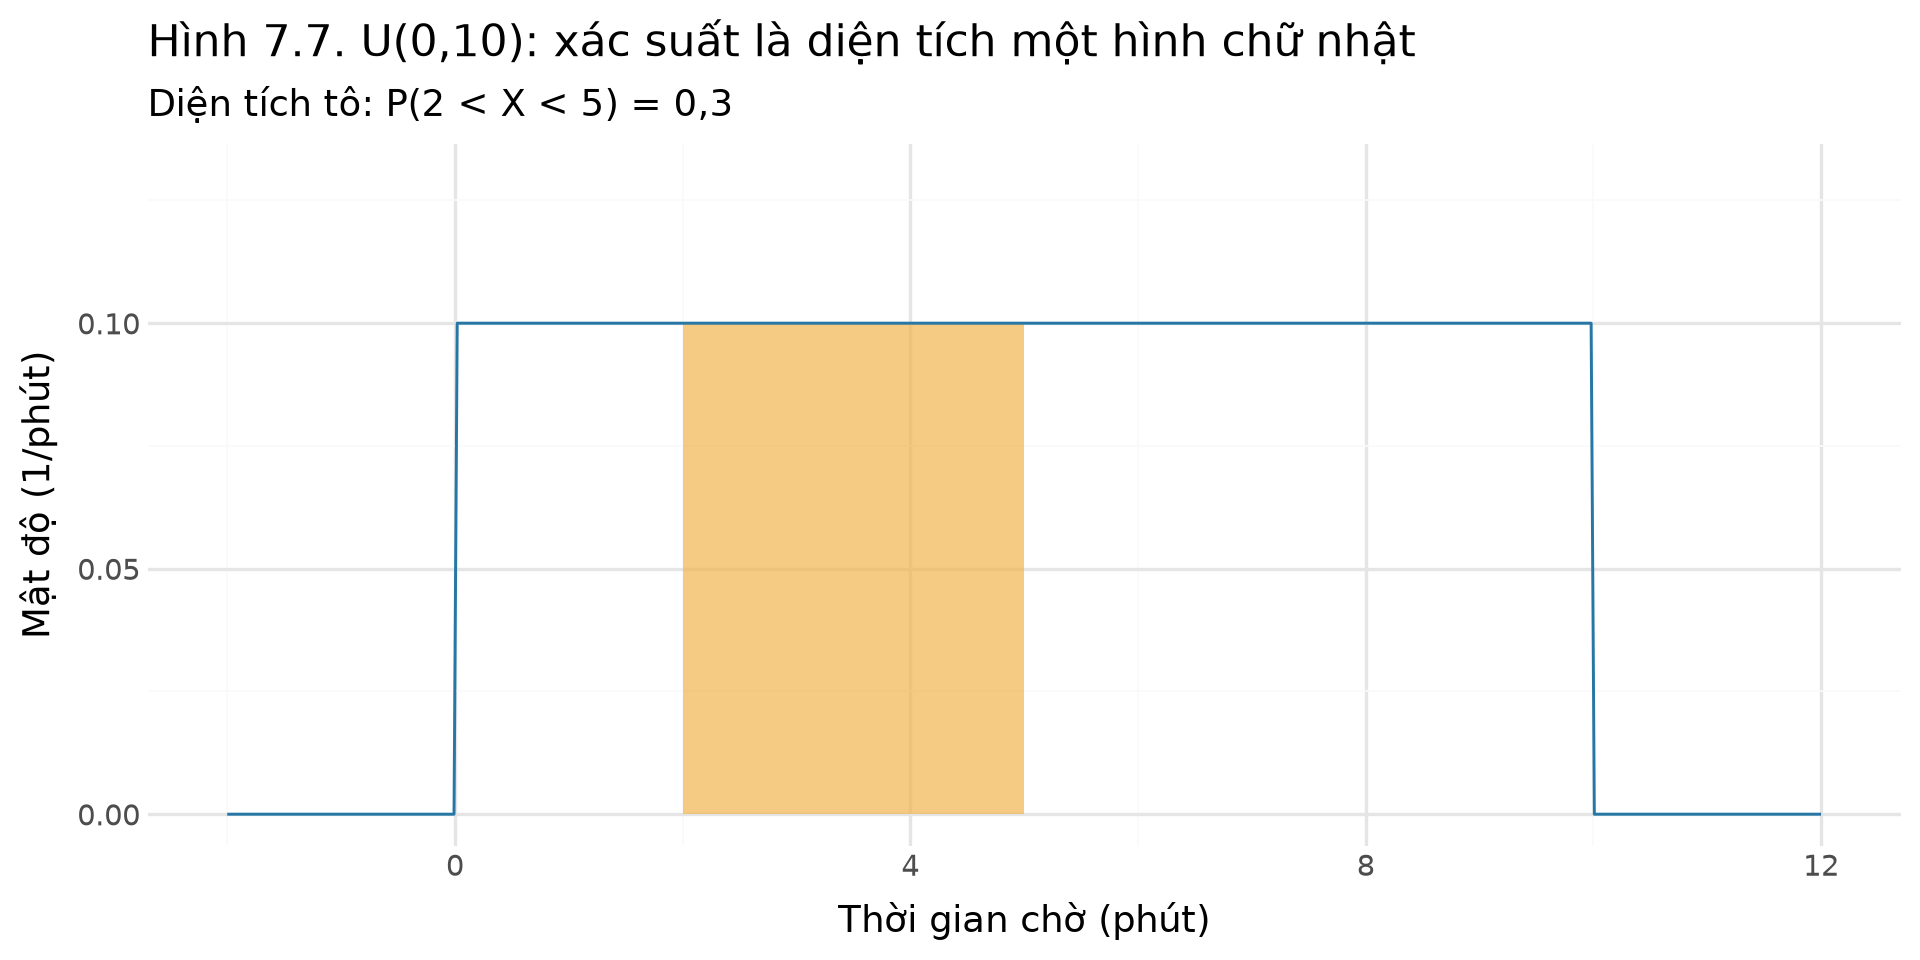

P(2<X<5) = 0.3 ; E = 5.0 ; Var = 8.333333333333332


In [16]:
a_deu,b_deu = 0,10
deu = stats.uniform(loc=a_deu,scale=b_deu-a_deu)
x_deu = np.linspace(-2,12,500)
bang_deu=pd.DataFrame({"x":x_deu,"mat_do":deu.pdf(x_deu)})
vung = np.linspace(2,5,100)
bang_vung=pd.DataFrame({"x":vung,"mat_do":deu.pdf(vung)})
hinh = (p9.ggplot(bang_deu,p9.aes("x","mat_do"))
    + p9.geom_ribbon(bang_vung,p9.aes(x="x",ymin=0,ymax="mat_do"),inherit_aes=False,fill="#F1B44C",alpha=0.7)
    + p9.geom_line(color="#2677A6")
    + p9.coord_cartesian(ylim=(0,0.13))
    + p9.labs(x="Thời gian chờ (phút)",y="Mật độ (1/phút)",
              title="Hình 7.7. U(0,10): xác suất là diện tích một hình chữ nhật",
              subtitle="Diện tích tô: P(2 < X < 5) = 0,3"))
display(hinh)
print("P(2<X<5) =",deu.cdf(5)-deu.cdf(2),"; E =",deu.mean(),"; Var =",deu.var())

### Phân phối mũ và Ví dụ 13 — Thời gian chờ yêu cầu

Với **tốc độ** $\lambda>0$, $X\sim\operatorname{Exp}(\lambda)$ có mật độ $\lambda e^{-\lambda x}$ khi $x\ge0$ và bằng 0 khi $x<0$. Phân phối lệch phải, dùng cho một số mô hình thời gian chờ.

$$P(X>t)=e^{-\lambda t},\qquad E(X)=\frac1\lambda,\qquad \operatorname{Var}(X)=\frac1{\lambda^2}\qquad(t\ge0).$$

$\lambda$ đo số sự kiện trên một đơn vị thời gian; $\frac1\lambda$ đo thời gian. Trong SciPy, `expon(scale=1/lam)` dùng **scale** $=\frac1\lambda$, không dùng `scale=lam`.

<details><summary><b>Vì sao?</b> Đuôi, kỳ vọng và phương sai của phân phối mũ</summary>

- *Đuôi:* $P(X>t)=\int_t^\infty\lambda e^{-\lambda x}\,dx=\big[-e^{-\lambda x}\big]_t^\infty=e^{-\lambda t}$. Thay $t=0$ được tổng diện tích bằng 1.
- *Kỳ vọng:* tích phân từng phần với $u=x$, $dv=\lambda e^{-\lambda x}dx$, tức $v=-e^{-\lambda x}$:
$$E(X)=\Big[-xe^{-\lambda x}\Big]_0^\infty+\int_0^\infty e^{-\lambda x}\,dx=0+\frac1\lambda.$$
- *Phương sai:* từng phần tương tự cho $E(X^2)=\frac2\lambda E(X)=\frac2{\lambda^2}$, nên $\operatorname{Var}(X)=\frac2{\lambda^2}-\frac1{\lambda^2}=\frac1{\lambda^2}$. $\blacksquare$

</details>

**Liên hệ với Poisson (Tuần 06).** Nếu yêu cầu đến theo mô hình Poisson với tốc độ $\lambda$, số yêu cầu trong $[0,t]$ là $\operatorname{Poisson}(\lambda t)$. Gọi $T$ là thời gian chờ đến yêu cầu đầu tiên:
$$P(T>t)=P(\text{không có yêu cầu nào trong }[0,t])=e^{-\lambda t}.$$
Vậy $T\sim\operatorname{Exp}(\lambda)$: **đếm** số sự kiện dùng Poisson, **đo** thời gian chờ dùng phân phối mũ. Với máy chủ 4 yêu cầu/giây ở Tuần 06, thời gian chờ trung bình là $\frac14$ giây.

**Tính không nhớ.** Với mọi $s,t\ge0$: $P(X>s+t\mid X>s)=P(X>t)$. Đã chờ $s$ phút mà chưa có yêu cầu thì thời gian còn phải chờ có **đúng** phân phối như lúc bắt đầu. Mô hình mũ hợp với sự kiện "đến ngẫu nhiên", không hợp với tuổi thọ thiết bị bị hao mòn.

<details><summary><b>Vì sao?</b> Tính không nhớ</summary>

Vì $\{X>s+t\}\subseteq\{X>s\}$, giao của hai biến cố là $\{X>s+t\}$. Theo định nghĩa xác suất có điều kiện:
$$P(X>s+t\mid X>s)=\frac{P(X>s+t)}{P(X>s)}=\frac{e^{-\lambda(s+t)}}{e^{-\lambda s}}=e^{-\lambda t}=P(X>t).\ \blacksquare$$

</details>

**Ví dụ 13.** Giả sử thời gian chờ yêu cầu mới có phân phối mũ, trung bình 2 phút. (1) Xác định $\lambda$. (2) Tính xác suất chờ hơn 3 phút.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.* $E(X)=\frac1\lambda=2$ phút, nên $\lambda=\frac12=0{,}5$ mỗi phút.

*Câu 2.*
$$P(X>3)=\int_3^\infty0{,}5e^{-0{,}5x}\,dx=e^{-0{,}5\cdot3}=e^{-1{,}5}\approx0{,}2231.$$

Theo mô hình, khoảng 22,31% lần theo dõi phải chờ hơn 3 phút. Không suy ra được rằng mọi thời gian chờ đều phân phối mũ.

</details>

**Bạn đoán trước:** vùng diện tích bên phải 3 phút trong hình dưới lớn hay nhỏ? Xác suất 0,2231 nằm trong $[0,1]$, còn chiều cao đường mật độ được đo bằng $1/\text{phút}$.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='mat_do'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. `geom_ribbon` tô miền giữa hai cận `ymin` và `ymax`. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

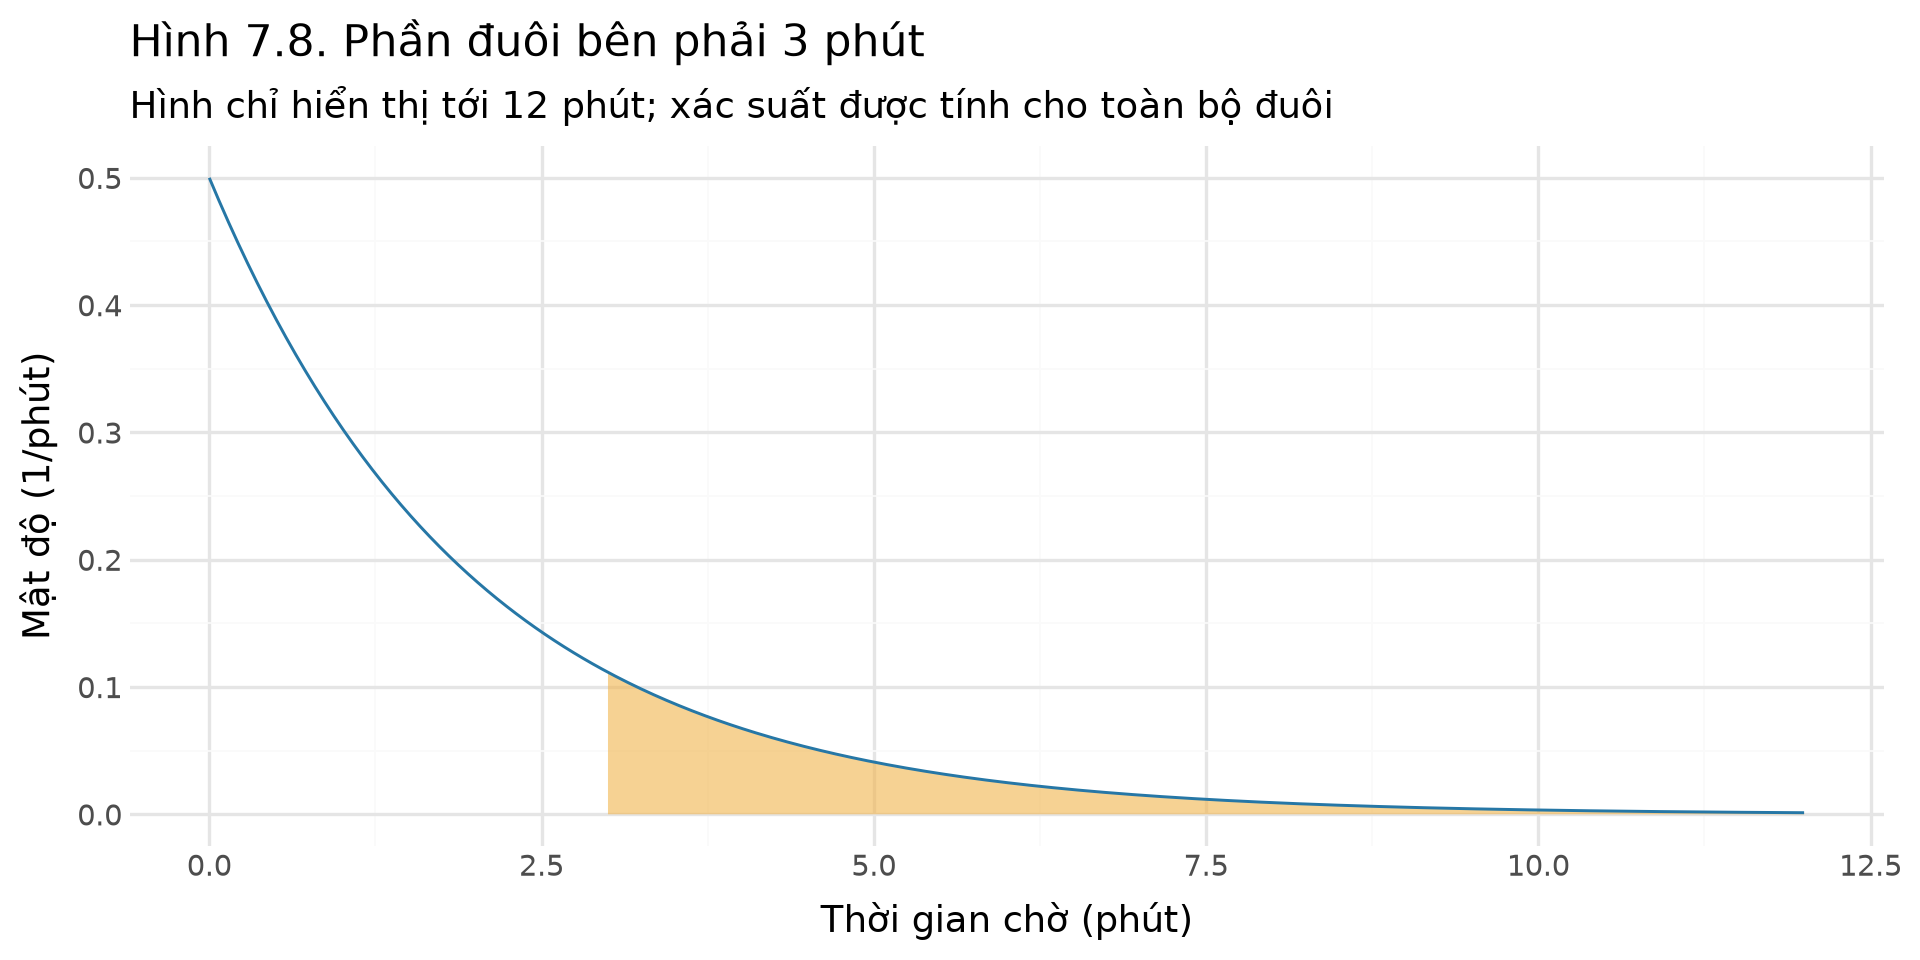

P(X>3) toàn bộ đuôi: 0.22313016014842982 ; E(X): 2.0


In [17]:
lam = 0.5  # Thử đổi tham số tốc độ (mỗi phút), E = 1/lam
mu_cho = 1/lam
cho = stats.expon(scale=mu_cho)
luoi_cho = np.linspace(0,12,500)
bang_cho=pd.DataFrame({"x":luoi_cho,"mat_do":cho.pdf(luoi_cho)})
vung=np.linspace(3,12,300)
bang_vung=pd.DataFrame({"x":vung,"mat_do":cho.pdf(vung)})
hinh = (p9.ggplot(bang_cho,p9.aes("x","mat_do"))
    + p9.geom_ribbon(bang_vung,p9.aes(x="x",ymin=0,ymax="mat_do"),inherit_aes=False,fill="#F1B44C",alpha=0.6)
    + p9.geom_line(color="#2677A6")
    + p9.labs(x="Thời gian chờ (phút)",y="Mật độ (1/phút)",
              title="Hình 7.8. Phần đuôi bên phải 3 phút",
              subtitle="Hình chỉ hiển thị tới 12 phút; xác suất được tính cho toàn bộ đuôi"))
display(hinh)
print("P(X>3) toàn bộ đuôi:",cho.sf(3),"; E(X):",cho.mean())

### Phân phối chuẩn, chuẩn hóa và Ví dụ 10

Với $\mu\in\mathbb R$ và $\sigma>0$, $X\sim\mathcal N(\mu,\sigma^2)$ có mật độ
$$f_X(x)=\frac1{\sigma\sqrt{2\pi}}\exp\left[-\frac{(x-\mu)^2}{2\sigma^2}\right],\quad x\in\mathbb R.$$

Đọc công thức:

- số mũ $-\frac{(x-\mu)^2}{2\sigma^2}$ bằng 0 tại $x=\mu$ và âm dần khi $x$ ra xa $\mu$: mật độ cao nhất ở $\mu$, giảm dần về hai phía;
- công thức chỉ phụ thuộc $(x-\mu)^2$, nên đường cong đối xứng quanh $\mu$;
- thừa số $\frac1{\sigma\sqrt{2\pi}}$ chỉ để tổng diện tích bằng 1.

$E(X)=\mu$ là tâm đối xứng; $\operatorname{Var}(X)=\sigma^2$ quyết định độ phân tán. Phân phối chuẩn tắc $\mathcal N(0,1)$ có hàm phân phối ký hiệu $\Phi$, đọc là *phi*.

**Chuẩn hóa.** Nếu $X\sim\mathcal N(\mu,\sigma^2)$ thì
$$Z=\frac{X-\mu}\sigma\sim\mathcal N(0,1),\qquad P(X\le x)=\Phi\Big(\frac{x-\mu}\sigma\Big).$$
Trừ trung bình xóa vị trí; chia SD đo khoảng cách bằng số độ lệch chuẩn. $Z$ không có đơn vị. Đối xứng cho $\Phi(-z)=1-\Phi(z)$. Chuẩn hóa một biến bất kỳ không làm nó trở thành chuẩn.

<details><summary><b>Vì sao?</b> Chứng minh chuẩn hóa bằng đổi biến</summary>

Tính hàm phân phối của $Z$:
$$P(Z\le z)=P(X\le\mu+\sigma z)=\int_{-\infty}^{\mu+\sigma z}\frac1{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/(2\sigma^2)}\,dx.$$
Đổi biến $t=(x-\mu)/\sigma$, tức $dx=\sigma\,dt$; cận trên $x=\mu+\sigma z$ thành $t=z$:
$$P(Z\le z)=\int_{-\infty}^{z}\frac1{\sqrt{2\pi}}e^{-t^2/2}\,dt=\Phi(z).$$
Vậy $Z$ có đúng hàm phân phối chuẩn tắc. Viết ngược lại, $X=\mu+\sigma Z$, nên $E(X)=\mu$ và $\operatorname{Var}(X)=\sigma^2$, nếu biết $E(Z)=0$ và $\operatorname{Var}(Z)=1$. $\blacksquare$

*Đọc thêm.* $E(Z)=0$ vì $z\varphi(z)$ là hàm lẻ; $\operatorname{Var}(Z)=1$ bằng tích phân từng phần. Tổng diện tích bằng 1 dựa trên tích phân Gauss $\int_{-\infty}^\infty e^{-z^2/2}\,dz=\sqrt{2\pi}$, chứng minh ở Giải tích 2. Cùng cách đổi biến cho thấy $aX+b$ ($a\ne0$) cũng chuẩn, với tham số $\mathcal N(a\mu+b,\ a^2\sigma^2)$.

</details>

**Ví dụ 10.** Giả sử điểm thi có phân phối chuẩn, trung bình 70 và SD 8. Điểm 86 có $z=\frac{86-70}8=2$: cao hơn trung bình 2 SD. Đó không phải xác suất 2, cũng không phải "gấp đôi trung bình".

Ở ô code dưới, đổi `sd_chon` từ 8 sang 4, 12 hoặc 16 rồi chạy lại ô để so sánh, trong khi giữ trung bình 70. Đường cong rộng hơn thì thấp hơn, để tổng diện tích vẫn là 1. Đường đứng ở 86 cho thấy cùng một điểm có $z$ khác nhau khi SD đổi.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='diem', y='mat_do'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_vline` thêm đường dọc tại `xintercept`. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

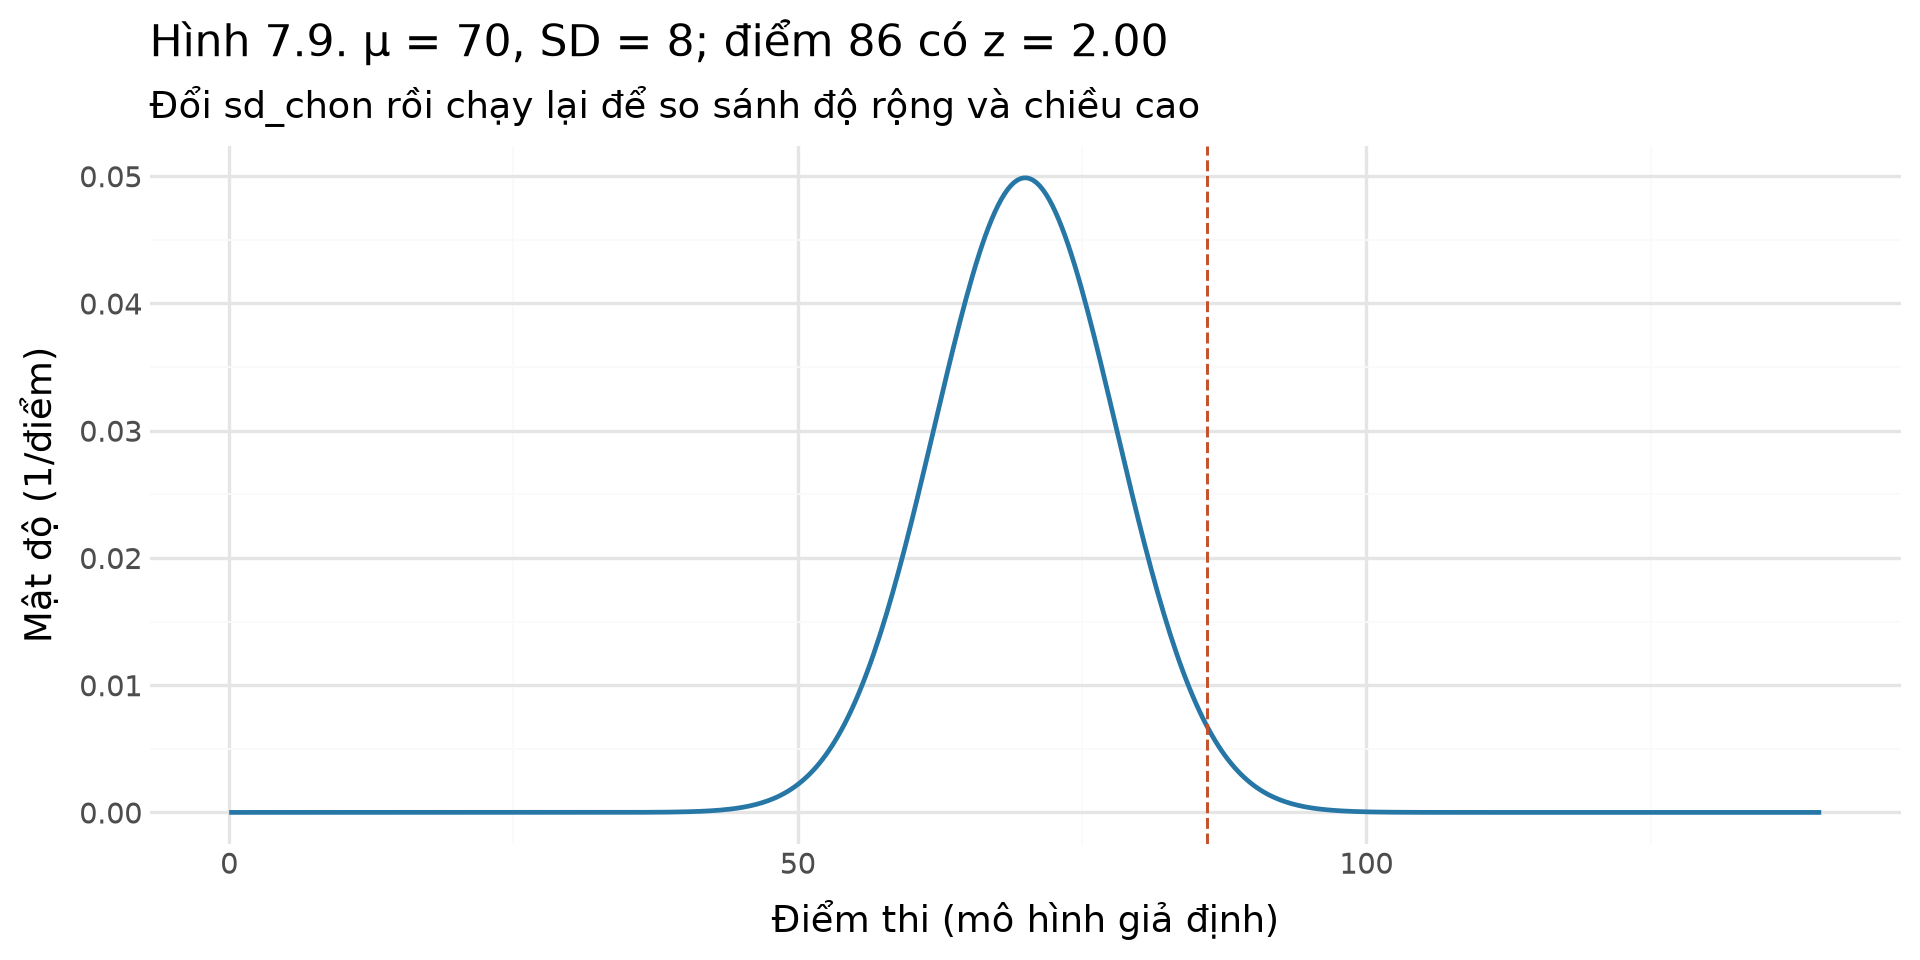

Ví dụ 10: z = 2.0


In [18]:
mu_diem = 70
diem_quan_sat = 86
sd_chon = 8  # Thử đổi thành 4, 12, 16 rồi chạy lại ô này
assert sd_chon > 0
luoi_diem = np.linspace(0,140,500)
bang_chuan=pd.DataFrame({"diem":luoi_diem,"mat_do":stats.norm.pdf(luoi_diem,loc=mu_diem,scale=sd_chon)})
z_quan_sat=(diem_quan_sat-mu_diem)/sd_chon
hinh = (p9.ggplot(bang_chuan,p9.aes("diem","mat_do"))
    + p9.geom_line(color="#2677A6",size=0.8)
    + p9.geom_vline(xintercept=diem_quan_sat,color="#C4512A",linetype="dashed")
    + p9.labs(x="Điểm thi (mô hình giả định)",y="Mật độ (1/điểm)",
              title=f"Hình 7.9. μ = 70, SD = {sd_chon}; điểm 86 có z = {z_quan_sat:.2f}",
              subtitle="Đổi sd_chon rồi chạy lại để so sánh độ rộng và chiều cao"))
display(hinh)
print("Ví dụ 10: z =",z_quan_sat)

### Quy tắc 68–95–99,7 và Ví dụ 11 — Dung tích chai

Với phân phối chuẩn, xác suất cách trung bình không quá 1, 2, 3 SD lần lượt xấp xỉ 68%, 95%, 99,7%:

$$\Phi(1)-\Phi(-1)\approx0{,}6827,\qquad\Phi(2)-\Phi(-2)\approx0{,}9545,\qquad\Phi(3)-\Phi(-3)\approx0{,}9973.$$

Nhờ chuẩn hóa, ba con số này đúng với **mọi** phân phối chuẩn, bất kể $\mu$ và $\sigma$. Quy tắc chỉ nói về phân phối chuẩn, không áp dụng tự động cho mọi dữ liệu.

**Ví dụ 11.** Giả sử dung tích chai $X\sim\mathcal N(500,\ 2^2)$ ml.

- Khoảng $[498;\ 502]$ (±1 SD) chứa xấp xỉ 68% số chai.
- Khoảng $[496;\ 504]$ (±2 SD) chứa xấp xỉ 95%.
- Xác suất trên 504 ml xấp xỉ 2,5%: 5% nằm ngoài ±2 SD, chia đều cho hai đuôi do đối xứng. Tính chính xác: $1-\Phi(2)\approx0{,}0228$.

Mô hình chỉ hợp lý khi quá trình đóng chai ổn định và phân phối thực tế gần đối xứng.

Ô dưới dựng ba vùng ±1, ±2, ±3 SD. Hãy đối chiếu diện tích tô với xác suất, rồi so xác suất đuôi đúng 0,02275 với mức làm tròn 2,5% của quy tắc.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='z', y='mat_do'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. `geom_ribbon` tô miền giữa hai cận `ymin` và `ymax`. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

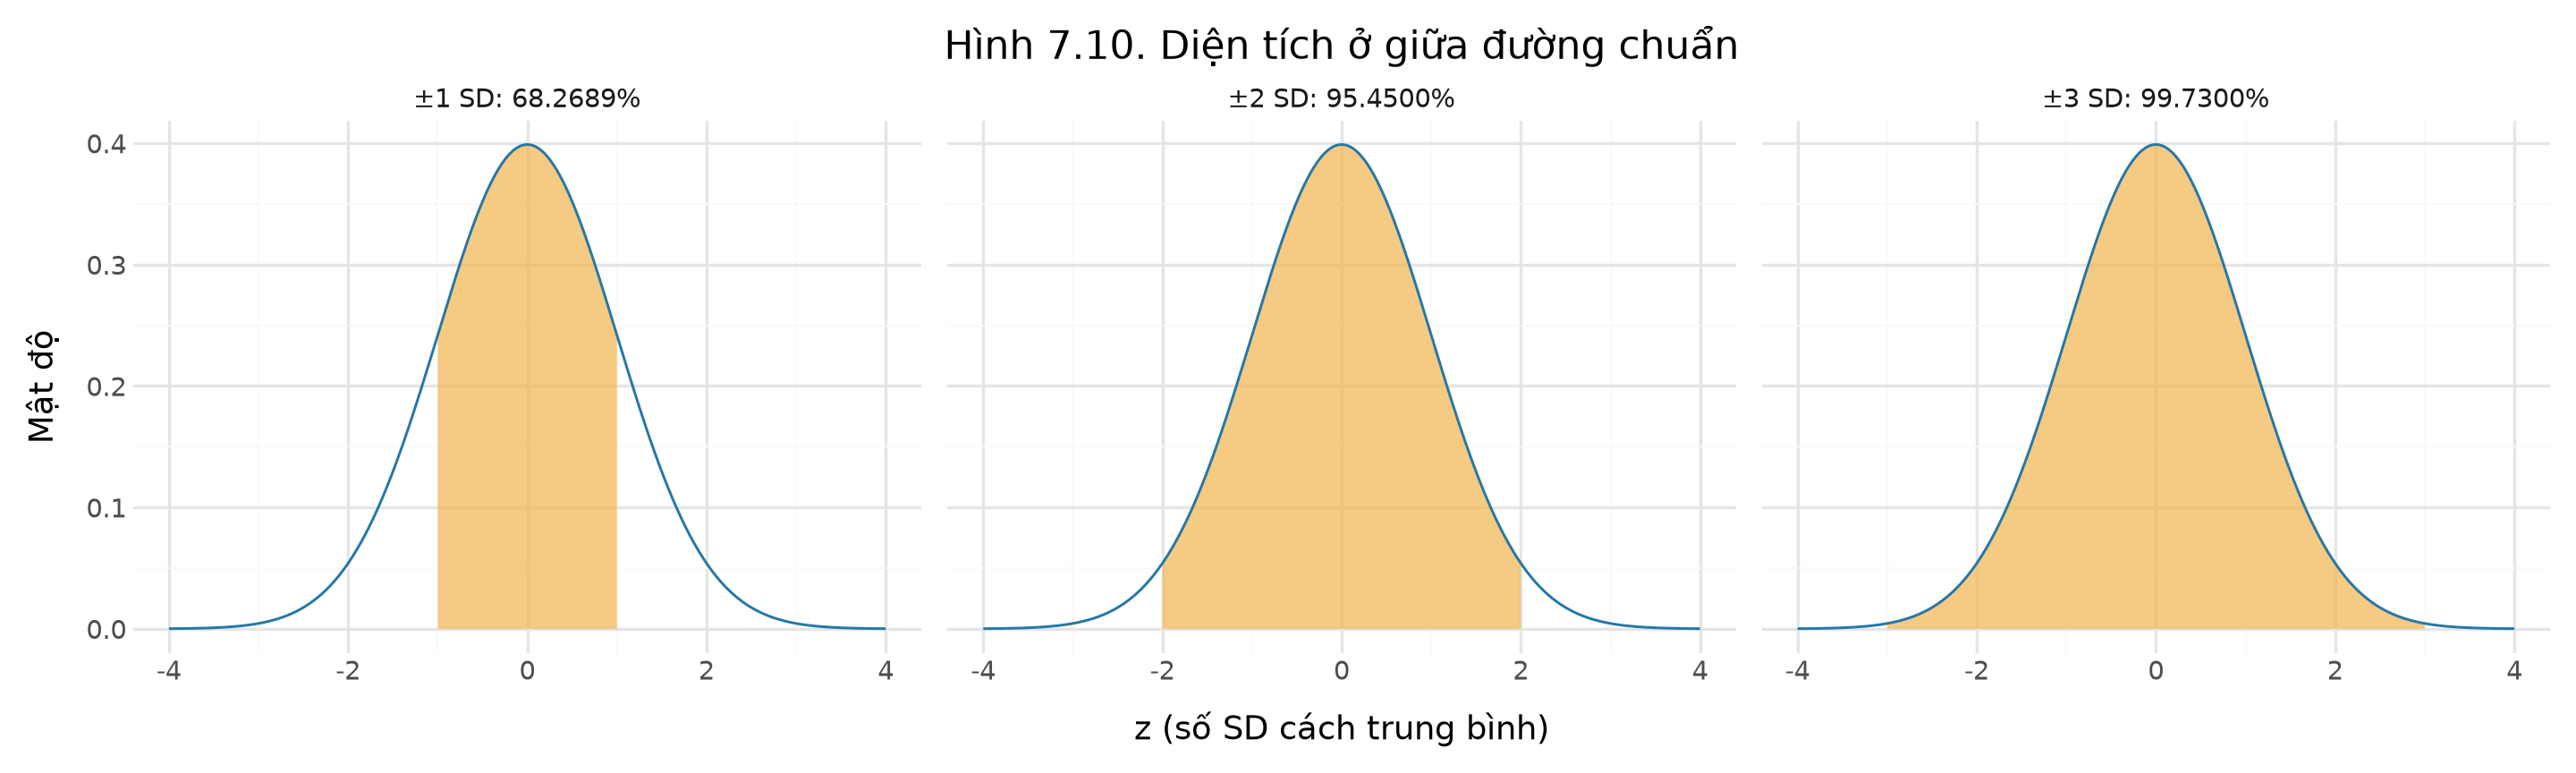

P(chai > 504 ml), chính xác theo mô hình: 0.022750131948179195


In [19]:
z_luoi = np.linspace(-4,4,500)
cac_duong=[];cac_vung=[]
for k in [1,2,3]:
    prob=stats.norm.cdf(k)-stats.norm.cdf(-k)
    nhan=f"±{k} SD: {prob:.4%}"
    cac_duong.append(pd.DataFrame({"z":z_luoi,"mat_do":stats.norm.pdf(z_luoi),"o":nhan}))
    vung=np.linspace(-k,k,200)
    cac_vung.append(pd.DataFrame({"z":vung,"mat_do":stats.norm.pdf(vung),"o":nhan}))
hinh = (p9.ggplot(pd.concat(cac_duong,ignore_index=True),p9.aes("z","mat_do"))
    + p9.geom_ribbon(pd.concat(cac_vung,ignore_index=True),p9.aes(x="z",ymin=0,ymax="mat_do"),
                     inherit_aes=False,fill="#F1B44C",alpha=0.7)
    + p9.geom_line(color="#2677A6")
    + p9.facet_wrap("o",ncol=3)
    + p9.labs(x="z (số SD cách trung bình)",y="Mật độ",title="Hình 7.10. Diện tích ở giữa đường chuẩn")
    + p9.theme(figure_size=(12,3.6)))
display(hinh)
chai = stats.norm(loc=500,scale=2)
print("P(chai > 504 ml), chính xác theo mô hình:",chai.sf(504))

### Phân vị và Ví dụ 12 — Tính bằng SciPy

**Phân vị mức $p$** là ngưỡng $q_p$ sao cho $P(X\le q_p)=p$, với $0<p<1$. Với phân phối chuẩn:

$$q_p=\mu+\sigma\,\Phi^{-1}(p).$$

Đọc là: đi từ trung bình thêm $\Phi^{-1}(p)$ độ lệch chuẩn. $\Phi^{-1}(p)$ là một **giá trị z**, không phải xác suất. Lý do: $P(X\le\mu+\sigma z_p)=\Phi(z_p)=p$ theo chuẩn hóa. Phân vị 0,95 để 95% diện tích bên trái và 5% bên phải; nó không phải một khoảng chứa 95% dữ liệu quanh trung bình.

**Ví dụ 12.** Dung tích chai có trung bình 500 ml, SD 2 ml. Tính (1) $P(X\le503)$ và $P(X>503)$; (2) $P(498<X<502)$; (3) $q_{0{,}95}$.

<details><summary>Đáp án và cách lập luận</summary>

1. Chuẩn hóa: $z=\frac{503-500}2=1{,}5$. Vậy $P(X\le503)=\Phi(1{,}5)\approx0{,}9332$ và $P(X>503)=1-0{,}9332\approx0{,}0668$.
2. $498$ và $502$ ứng với $z=-1$ và $z=1$: $P(498<X<502)=\Phi(1)-\Phi(-1)\approx0{,}6827$.
3. $\Phi^{-1}(0{,}95)\approx1{,}64485$, nên $q_{0{,}95}=500+2\cdot1{,}64485\approx503{,}290$ ml.

Trong SciPy, `loc=500` là trung bình, **`scale=2` là SD**, không phải phương sai 4. `cdf` cho diện tích bên trái, `sf` bên phải, `ppf` cho phân vị.

</details>

Ô dưới chạy đúng các phép tính đó. Ngưỡng đầu vào đo bằng ml; xác suất không có đơn vị; phân vị đầu ra đo bằng ml.

In [20]:
p_duoi_503 = stats.norm.cdf(503,loc=500,scale=2)
p_tren_503 = stats.norm.sf(503,loc=500,scale=2)
p_giua = stats.norm.cdf(502,loc=500,scale=2)-stats.norm.cdf(498,loc=500,scale=2)
q95 = stats.norm.ppf(0.95,loc=500,scale=2)
display(pd.DataFrame({"Đại lượng":["P(X≤503)","P(X>503)","P(498<X<502)","q0,95 (ml)"],
                      "Kết quả":[p_duoi_503,p_tren_503,p_giua,q95]}))

,Đại lượng,Kết quả
0,P(X≤503),0.93319
1,P(X>503),0.06681
2,P(498<X<502),0.68269
3,"q0,95 (ml)",503.28971


<a id="hoc-f733bf37"></a>
## 7. Định lý giới hạn trung tâm

### Vì sao nhiều tổng có dạng gần chuông?

Cho $X_1,X_2,\ldots$ i.i.d., mỗi biến có kỳ vọng $\mu$ và độ lệch chuẩn $\sigma>0$. Chuẩn hóa tổng (hoặc trung bình):

$$Z_n=\frac{S_n-n\mu}{\sigma\sqrt n}=\frac{\overline X_n-\mu}{\sigma/\sqrt n}.$$

**Định lý giới hạn trung tâm** (central limit theorem, CLT) nói: khi $n$ lớn, phân phối của $Z_n$ gần với $\mathcal N(0,1)$. Viết lại theo tổng và trung bình:

$$S_n\approx\mathcal N(n\mu,\ n\sigma^2),\qquad \overline X_n\approx\mathcal N\Big(\mu,\ \frac{\sigma^2}n\Big).$$

Đọc thành lời: cộng (hoặc lấy trung bình) rất nhiều lần rút độc lập từ cùng một hộp. Dù hộp chứa những con số phân bố thế nào, **hình dạng** phân phối của tổng vẫn gần đường cong chuông.

| Phần của phát biểu | Đã biết từ trước? |
|---|---|
| $E(S_n)=n\mu$, $\operatorname{SD}(S_n)=\sigma\sqrt n$ | có: mục 3, đúng với **mọi** $n$ |
| $Z_n$ là phép chuẩn hóa nên có kỳ vọng 0, SD 1 | có: mục 6 |
| **hình dạng** phân phối của $Z_n$ gần đường cong chuông | **mới**: đây là toàn bộ nội dung mới của CLT |

**Ba điều CLT không nói.**

1. CLT không nói từng quan sát có phân phối chuẩn; chỉ **tổng hoặc trung bình** mới gần chuẩn.
2. Không có ngưỡng $n=30$ bảo đảm cho mọi phân phối; phân phối gốc càng lệch thì càng cần $n$ lớn.
3. CLT không xóa được sự phụ thuộc mạnh giữa các lần thử, và không dùng được khi phương sai vô hạn.

Nếu các $X_i$ đã là chuẩn và độc lập, tổng và trung bình là chuẩn **chính xác** với mọi $n$ (Bài tập 8).

<details><summary><b>Vì sao?</b> Phát biểu chính xác và phác thảo chứng minh</summary>

*Phát biểu chính xác.* Điều kiện: i.i.d., $0<\operatorname{Var}(X_i)=\sigma^2<\infty$. Kết luận: với mọi $z$, $P(Z_n\le z)\to\Phi(z)$ khi $n\to\infty$. Cách hội tụ này gọi là **hội tụ theo phân phối**, viết $Z_n\xrightarrow{d}\mathcal N(0,1)$: các xác suất $P(Z_n\le z)$ tiến về $\Phi(z)$ tại mọi $z$. Do phân phối chuẩn liên tục, xác suất của một khoảng có hai đầu mút cố định cũng hội tụ về xác suất tương ứng của chuẩn tắc; không được suy rộng thành mọi biến cố tùy ý. Khi $\sigma=0$ thì không chia được cho $\sigma$; khi phương sai vô hạn thì phát biểu không áp dụng.

*Trực giác.* Với một xúc xắc, phân phối phẳng. Với hai xúc xắc, tổng có dạng tam giác: tổng 7 có 6 cách, tổng 2 chỉ có 1 cách. Với ba xúc xắc, đã có dạng chuông: tổng 10 và 11 mỗi tổng có 27 cách, tổng 3 và 18 mỗi tổng 1 cách. Tổng ở giữa có **nhiều cách** tạo ra hơn tổng ở hai đầu, vì có thể ghép giá trị lớn với giá trị nhỏ; giá trị cực đoan cần **mọi** lần rút cùng cực đoan, nên ngày càng hiếm.

*Phác thảo chứng minh (đọc thêm, giả sử hàm sinh moment tồn tại).*

1. Hàm sinh moment $M_X(t)=E(e^{tX})$ xác định phân phối: nếu $M_{Z_n}(t)\to M_Z(t)$ với mọi $t$ gần 0 thì phân phối của $Z_n$ tiến về phân phối của $Z$. Với $Z\sim\mathcal N(0,1)$, $M_Z(t)=e^{t^2/2}$.
2. Đặt $Y_i=(X_i-\mu)/\sigma$: i.i.d., kỳ vọng 0, phương sai 1, và $Z_n=\frac1{\sqrt n}\sum_i Y_i$.
3. Độc lập cho $M_{Z_n}(t)=\big[M_Y(t/\sqrt n)\big]^n$.
4. Khai triển Taylor: $M_Y(s)=1+s\,E(Y)+\frac{s^2}2E(Y^2)+\cdots=1+\frac{s^2}2+(\text{các số hạng nhỏ hơn }s^2)$.
5. Thay $s=t/\sqrt n$: $M_{Z_n}(t)=\big[1+\frac{t^2}{2n}+(\text{nhỏ hơn }1/n)\big]^n\to e^{t^2/2}$, theo giới hạn $(1+a/n)^n\to e^a$ đã dùng cho Poisson.

Chỉ kỳ vọng và phương sai của $Y$ còn lại trong giới hạn; mọi đặc điểm khác của hộp ban đầu (độ lệch, số đỉnh) biến mất khi $n$ lớn. Vì vậy kết quả không phụ thuộc vào hộp. $\blacksquare$

</details>

### Ví dụ 14 — Tổng và trung bình từ hộp thẻ

Rút $n$ lần độc lập, có hoàn lại từ hộp $0,0,1,1,1,2,3,3,4,4$, tính tổng/trung bình rồi lặp độc lập 5.000 lần; làm với $n=25$ và $n=100$.

1. So sánh hình dạng, tâm, độ phân tán của các tổng.
2. So sánh các trung bình.
3. Giải thích 25, 100, 5.000 có vai trò khác nhau thế nào.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.* Tổng gần dạng chuông. Tâm tăng từ $25\cdot1{,}9=47{,}5$ lên $190$; SD tăng từ 7,228 lên 14,457 (gấp 2 khi $n$ gấp 4).

*Câu 2.* Trung bình cũng gần dạng chuông, cùng tâm 1,9; SD giảm từ 0,289 xuống 0,145.

*Câu 3.* 25 và 100 là **cỡ mẫu mỗi lần**: chúng quyết định phương sai của tổng/trung bình và ảnh hưởng đến chất lượng xấp xỉ chuẩn. 5.000 là **số mẫu lặp** dùng để vẽ phân phối thực nghiệm: tăng nó làm hình rõ hơn, nhưng không đổi phân phối lý thuyết của thống kê ở cỡ mẫu cố định.

</details>

Hai hình sau dùng các mẫu đã mô phỏng ở mục 3 (`ket_qua_hop`). Đọc đơn vị và giới hạn trục hoành trước khi so độ rộng. Histogram vẽ theo thang mật độ, nên tổng diện tích bằng 1; chiều cao không phải xác suất của từng giá trị. Tổng và trung bình từ một hộp hữu hạn vẫn là biến **rời rạc**, dù hình trông mượt.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** `geom_vline` thêm đường dọc tại `xintercept`. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. `geom_rect` vẽ mỗi hình chữ nhật từ các cận `xmin`, `xmax`, `ymin` và `ymax`. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

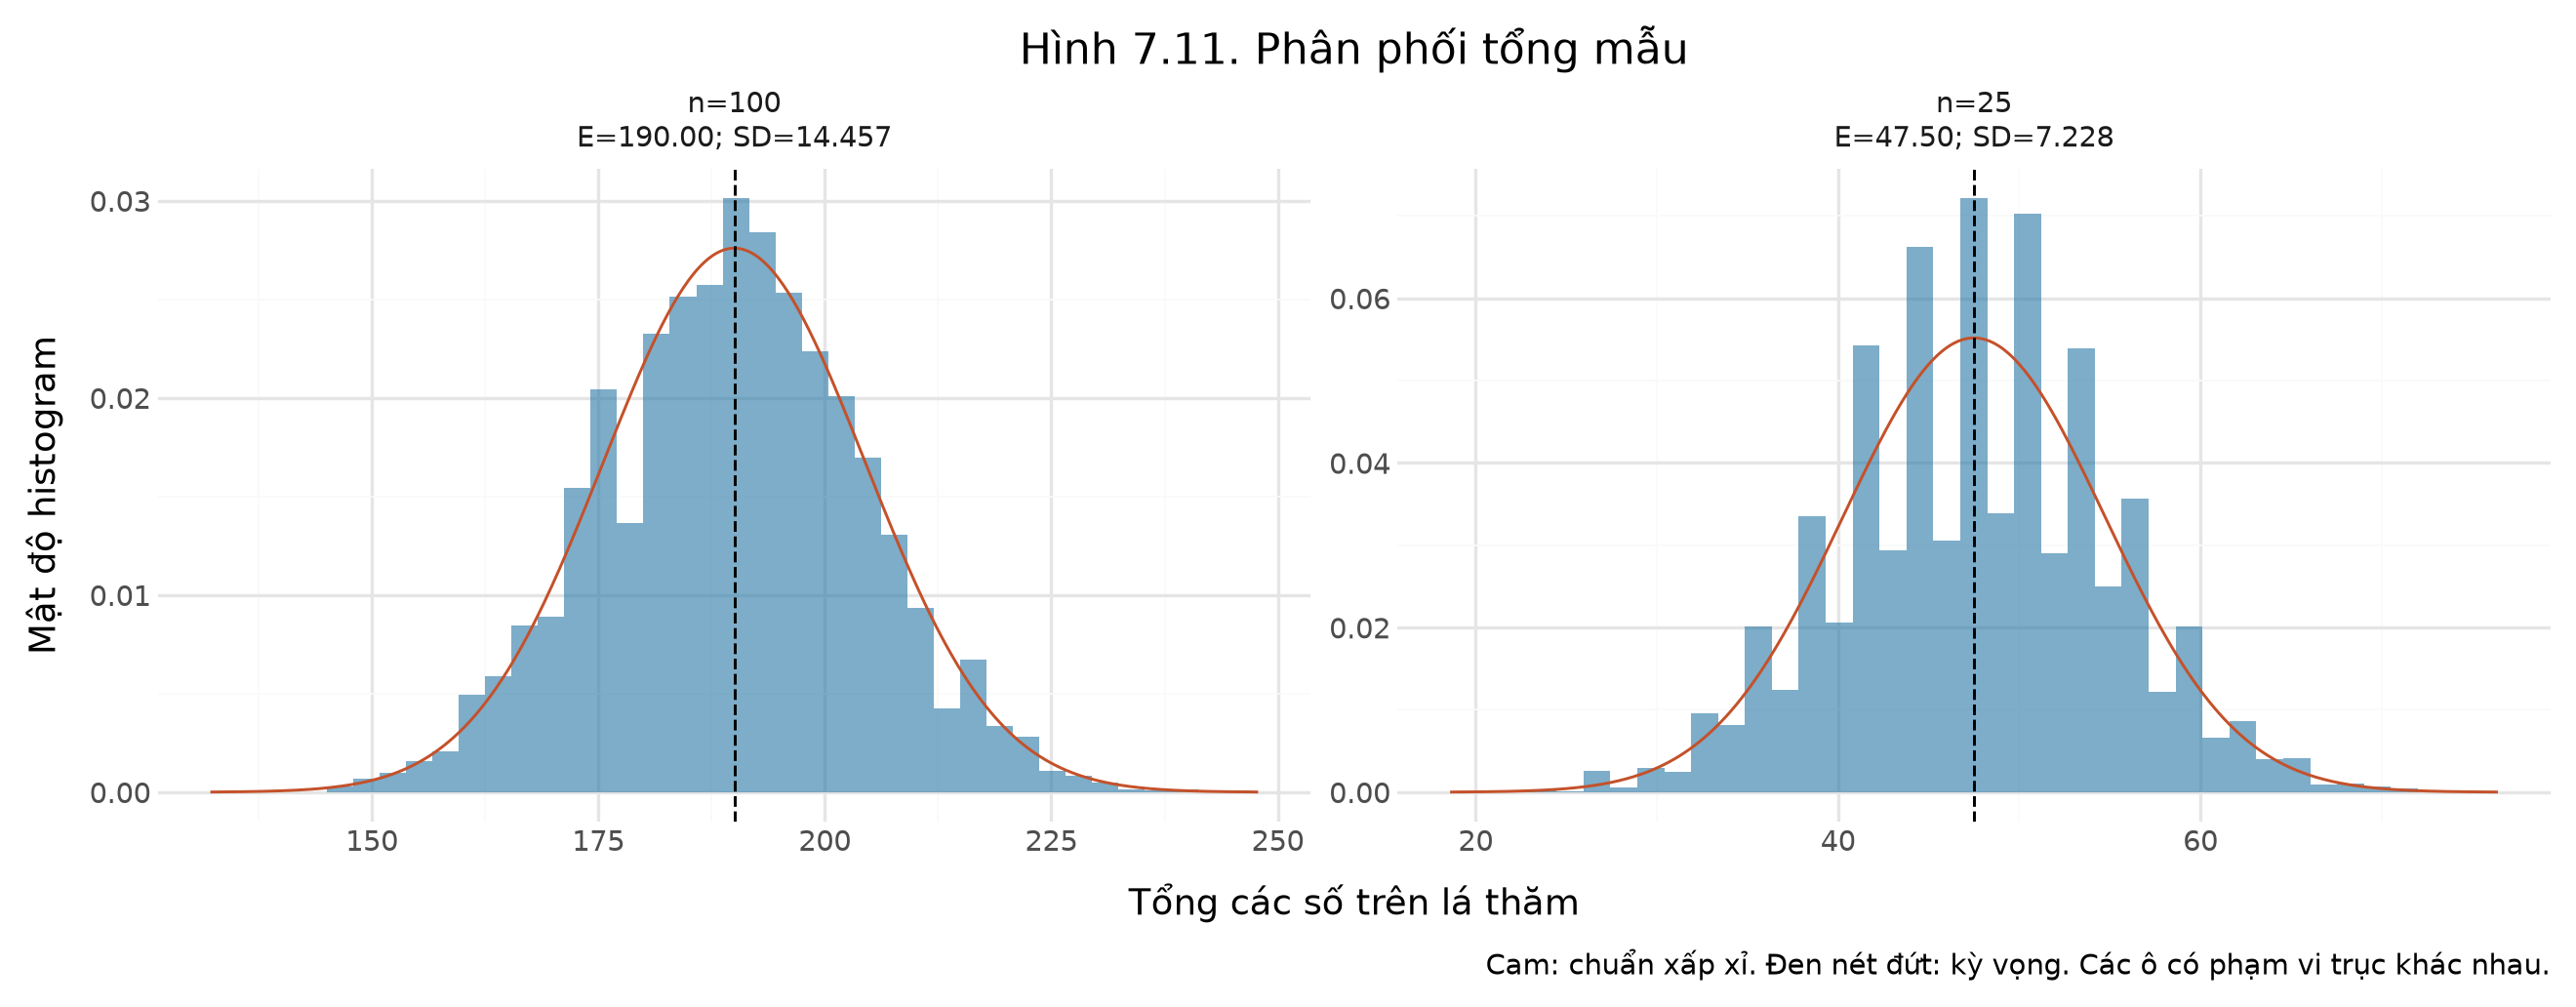

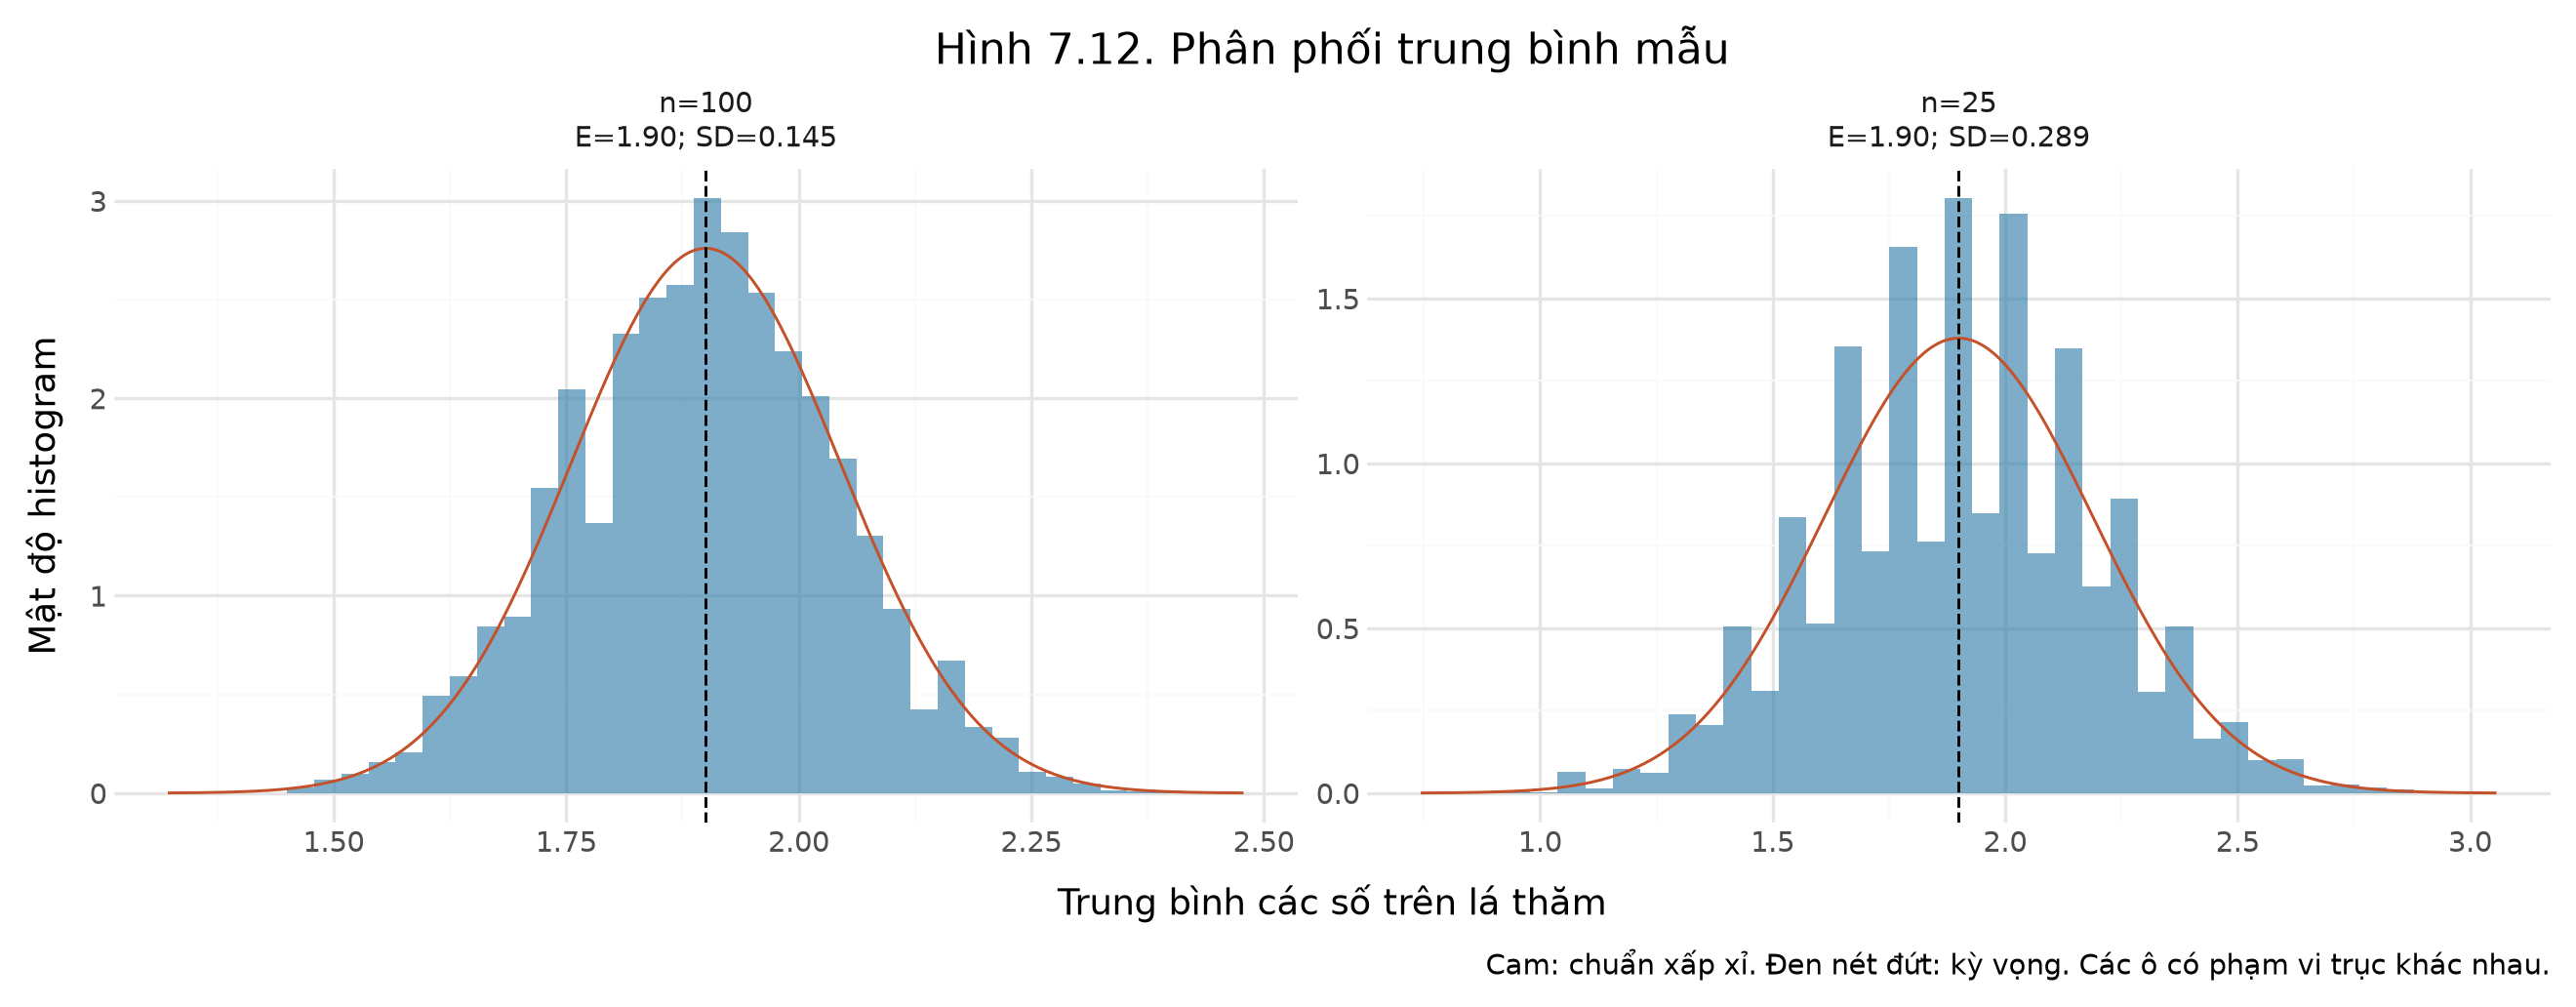

In [21]:
for bien,nhan,tieu_de in [("tong","Tổng các số trên lá thăm","Hình 7.11. Phân phối tổng mẫu"),
                             ("trung_binh","Trung bình các số trên lá thăm","Hình 7.12. Phân phối trung bình mẫu")]:
    cac_hist=[];cac_duong=[];cac_tam=[]
    for n in [25,100]:
        du_lieu=ket_qua_hop[n][bien]
        mu=n*mu_hop if bien=="tong" else mu_hop
        sd=sd_hop*np.sqrt(n) if bien=="tong" else sd_hop/np.sqrt(n)
        nhan_o=f"n={n}\nE={mu:.2f}; SD={sd:.3f}"
        cao,bien_chia=np.histogram(du_lieu,bins=35,density=True)
        cac_hist.append(pd.DataFrame({"trai":bien_chia[:-1],"phai":bien_chia[1:],"cao":cao,"o":nhan_o}))
        luoi=np.linspace(mu-4*sd,mu+4*sd,400)
        cac_duong.append(pd.DataFrame({"x":luoi,"mat_do":stats.norm.pdf(luoi,loc=mu,scale=sd),"o":nhan_o}))
        cac_tam.append({"o":nhan_o,"mu":mu})
    hinh = (p9.ggplot()
        + p9.geom_rect(pd.concat(cac_hist,ignore_index=True),p9.aes(xmin="trai",xmax="phai",ymin=0,ymax="cao"),
                       fill="#2677A6",alpha=0.6)
        + p9.geom_line(pd.concat(cac_duong,ignore_index=True),p9.aes("x","mat_do"),color="#C4512A")
        + p9.geom_vline(pd.DataFrame(cac_tam),p9.aes(xintercept="mu"),color="black",linetype="dashed")
        + p9.facet_wrap("o",ncol=2,scales="free")
        + p9.labs(x=nhan,y="Mật độ histogram",title=tieu_de,
                  caption="Cam: chuẩn xấp xỉ. Đen nét đứt: kỳ vọng. Các ô có phạm vi trục khác nhau.")
        + p9.theme(figure_size=(11,4.3)))
    display(hinh)

### Phân phối gốc lệch phải: $n$ cần lớn đến đâu?

Mô phỏng dưới dùng **thời gian chờ mũ có kỳ vọng và SD đều bằng 5 phút**, một phân phối lệch phải rõ. Với $n=1,5,30,100$, tạo 5.000 mẫu, tính trung bình và chuẩn hóa bằng **SD của trung bình** $5/\sqrt n$. Đường chuẩn tắc có cùng tâm 0, SD 1 cho mọi $n$, nên ta so được **hình dạng** một cách công bằng.

**Bạn đoán trước:** với $n=30$, histogram đã trùng đường chuẩn chưa?

Trong code, `rng.exponential(scale=mu_mu, size=(lap_clt, n))` tạo 5.000 hàng, mỗi hàng $n$ thời gian chờ; `mau.mean(axis=1)` cho 5.000 trung bình. `np.sqrt(n)` thay đổi theo cỡ mẫu, không theo số lần lặp: tăng số lần lặp ở $n=1$ không làm phân phối mũ trở thành chuẩn.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='z', y='mat_do'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. `geom_rect` vẽ mỗi hình chữ nhật từ các cận `xmin`, `xmax`, `ymin` và `ymax`. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

### Thử nghiệm bổ sung: cỡ mẫu và số lần lặp là hai đại lượng khác nhau

Giữ `lap_clt = 5000`, so bốn hình `n = 1, 5, 30, 100`. Dự đoán trước hình nào còn lệch phải nhiều; sau khi chạy, so histogram của trung bình chuẩn hóa với đường chuẩn tắc. Không kết luận dữ liệu thời gian chờ gốc đã trở thành phân phối chuẩn.

Sau đó giữ `n_clt` và chỉ đổi `lap_clt` từ 5000 thành 1000. Histogram thường gồ ghề hơn do ít lần lặp; phân phối lý thuyết của trung bình với mỗi n không thay đổi. CLT cần các giả định đã nêu và không bảo đảm sai số nhỏ chỉ vì n đạt 30. Khôi phục giá trị mặc định trước khi Run All.

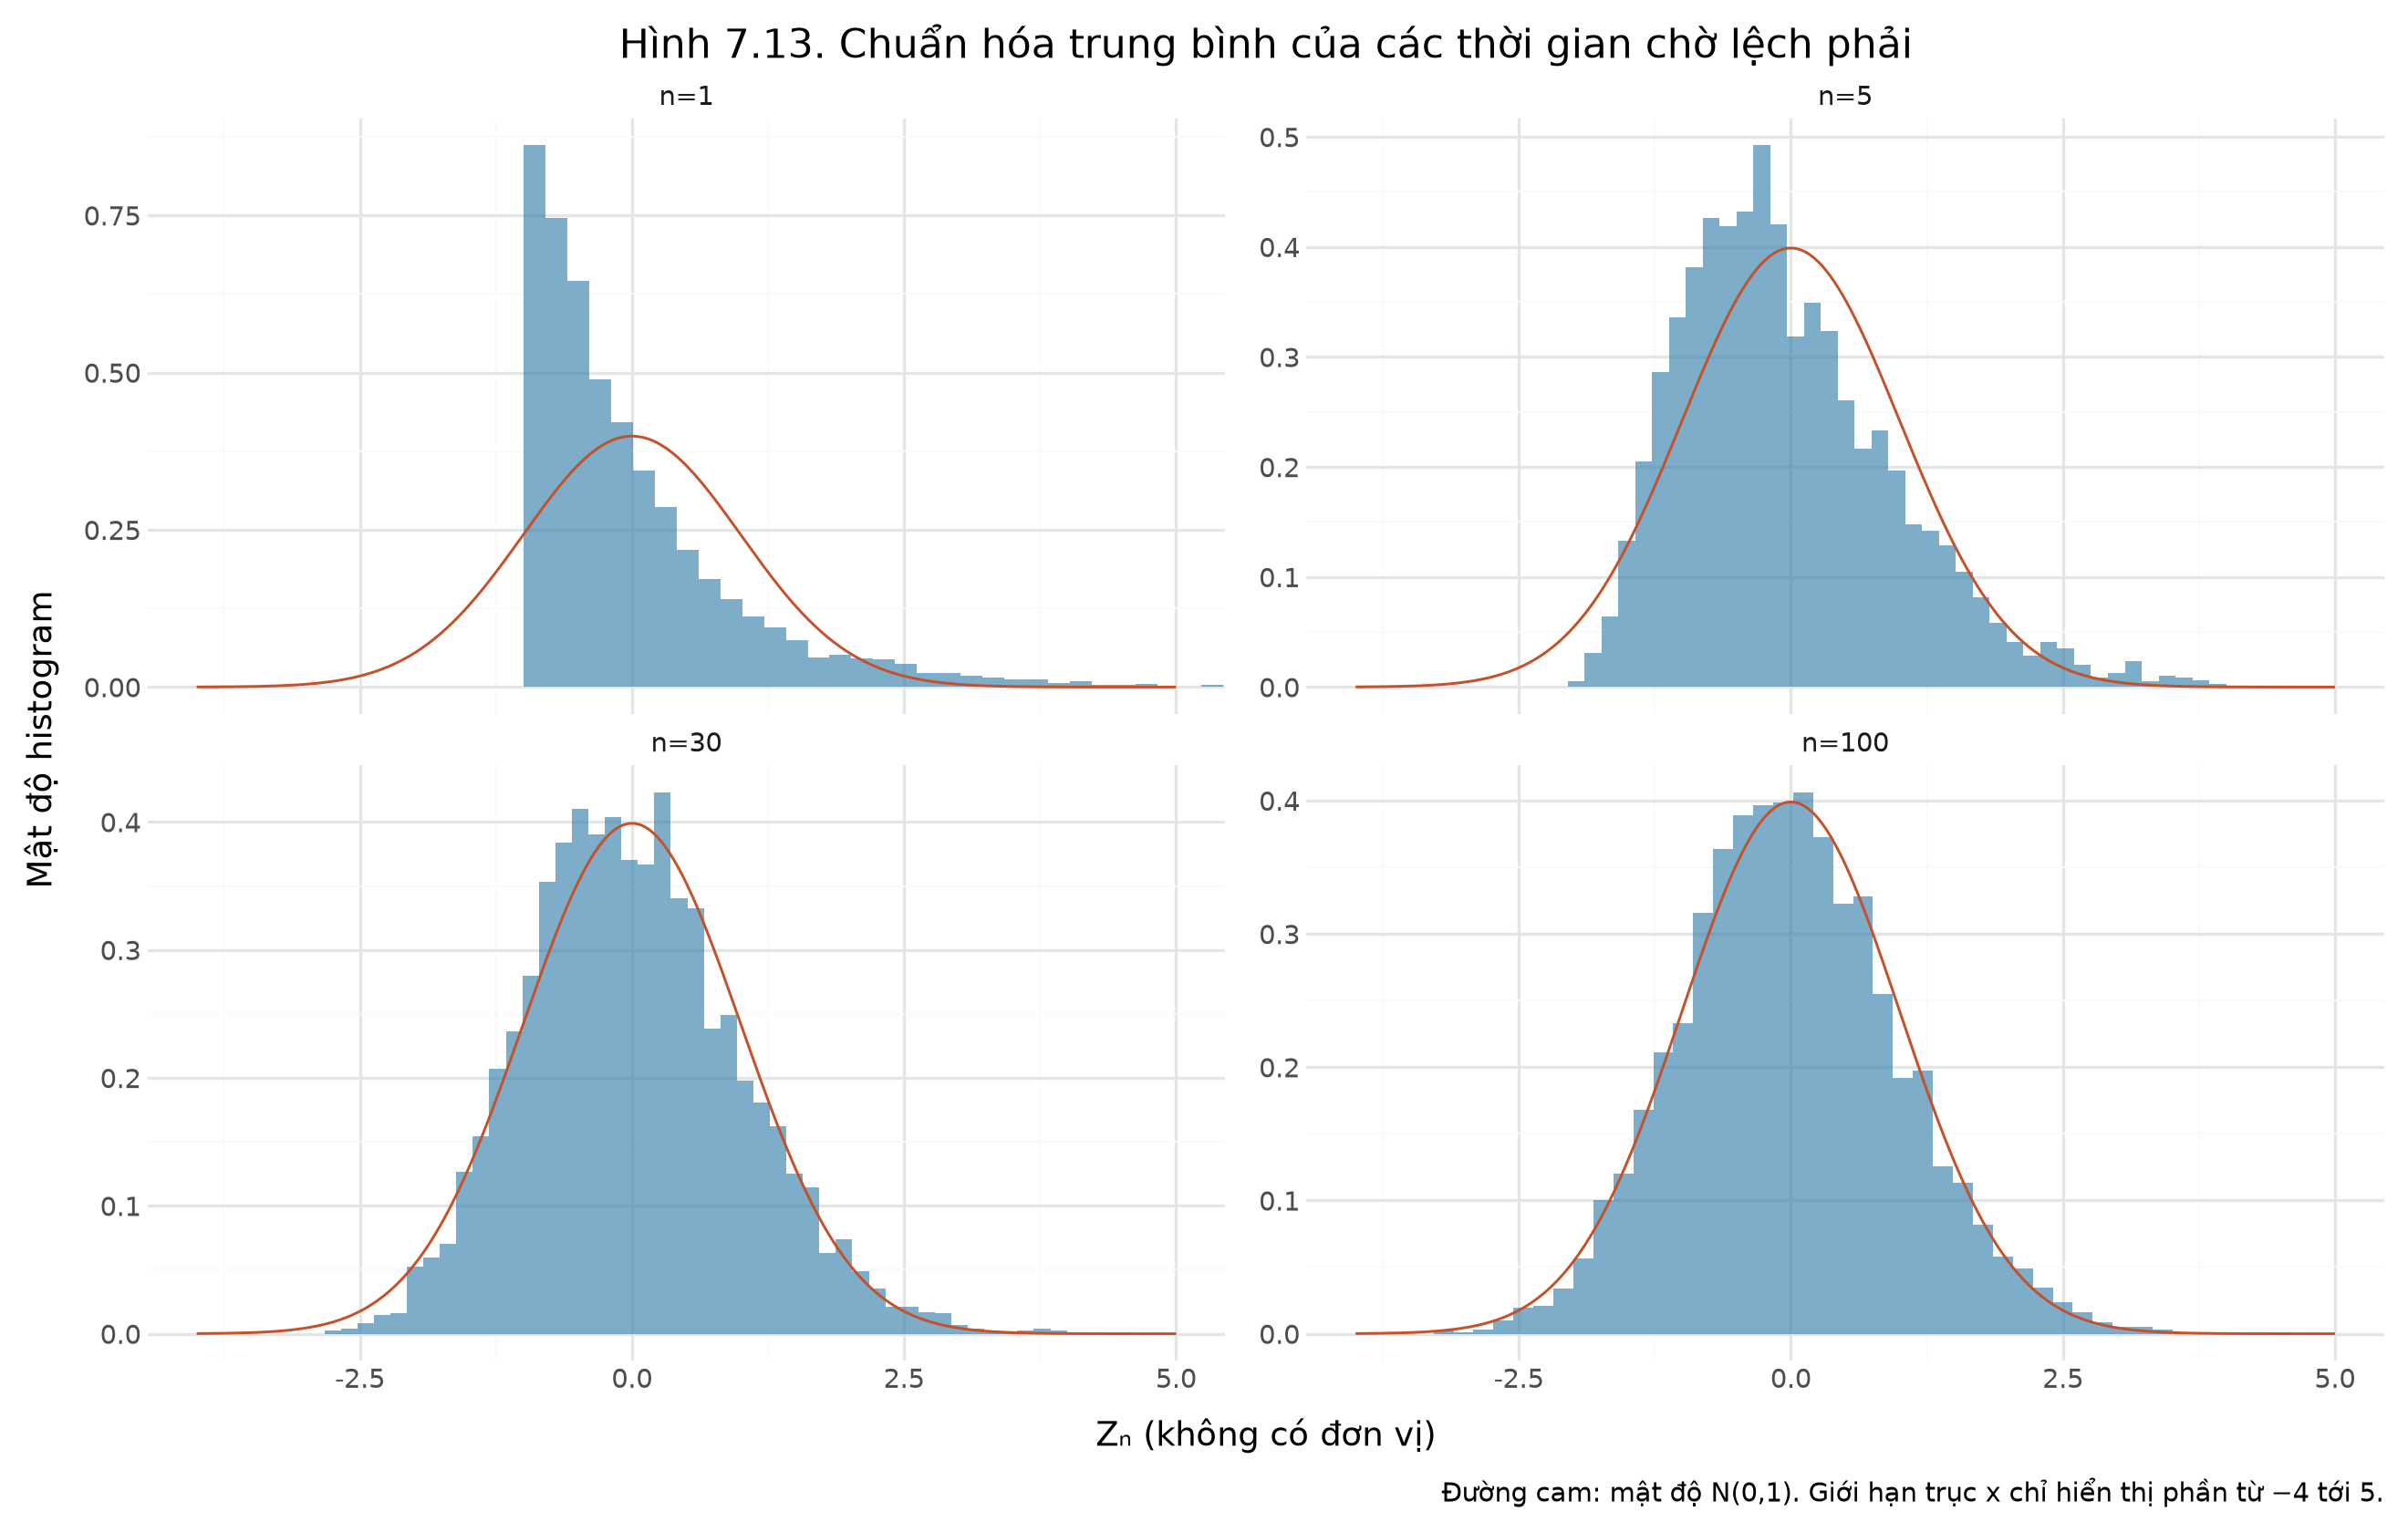

In [22]:
n_clt = [1,5,30,100]  # Thử đổi các cỡ mẫu; mỗi số cho một ô facet
lap_clt = 5000
mu_mu = sd_mu = 5.0
z_theo_n = {}
luoi_z=np.linspace(-4,5,500)
cac_hist=[];cac_duong=[]
for n in n_clt:
    mau=rng.exponential(scale=mu_mu,size=(lap_clt,n))
    z=(mau.mean(axis=1)-mu_mu)/(sd_mu/np.sqrt(n))
    z_theo_n[n]=z
    cao,bien=np.histogram(z,bins=45,density=True)
    nhan_o=f"n={n}"
    cac_hist.append(pd.DataFrame({"trai":bien[:-1],"phai":bien[1:],"cao":cao,"o":nhan_o}))
    cac_duong.append(pd.DataFrame({"z":luoi_z,"mat_do":stats.norm.pdf(luoi_z),"o":nhan_o}))
bang_hist=pd.concat(cac_hist,ignore_index=True)
bang_duong=pd.concat(cac_duong,ignore_index=True)
thu_tu_o=[f"n={n}" for n in n_clt]
bang_hist["o"]=pd.Categorical(bang_hist["o"],categories=thu_tu_o,ordered=True)
bang_duong["o"]=pd.Categorical(bang_duong["o"],categories=thu_tu_o,ordered=True)
hinh = (p9.ggplot()
    + p9.geom_rect(bang_hist,p9.aes(xmin="trai",xmax="phai",ymin=0,ymax="cao"),fill="#2677A6",alpha=0.6)
    + p9.geom_line(bang_duong,p9.aes("z","mat_do"),color="#C4512A")
    + p9.facet_wrap("o",ncol=2,scales="free_y")
    + p9.coord_cartesian(xlim=(-4,5))
    + p9.labs(x="Zₙ (không có đơn vị)",y="Mật độ histogram",
              title="Hình 7.13. Chuẩn hóa trung bình của các thời gian chờ lệch phải",
              caption="Đường cam: mật độ N(0,1). Giới hạn trục x chỉ hiển thị phần từ −4 tới 5.")
    + p9.theme(figure_size=(11,7)))
display(hinh)

Với $n=1$, histogram lệch phải rõ. Khi $n$ tăng, độ lệch giảm và hình dạng gần chuẩn hơn, nhưng ở $n=30$ vẫn chưa trùng hẳn. Bảng dưới đo điều này chính xác cho phân phối mũ: xác suất trung bình chuẩn hóa vượt $+2$ (đuôi phải) hoặc dưới $-2$ (đuôi trái), so với $0{,}0228$ mà CLT dự đoán cho mỗi phía.

| $n$ | Đuôi phải (chính xác) | Đuôi trái (chính xác) | CLT dự đoán mỗi phía |
|---|---:|---:|---:|
| 5 | 0,041 | 0,0002 | 0,0228 |
| 30 | 0,032 | 0,012 | 0,0228 |
| 100 | 0,028 | 0,017 | 0,0228 |

Với $n=30$, xấp xỉ vẫn lệch rõ ở hai đuôi. Với phân phối gần đối xứng, như tổng các xúc xắc, $n$ nhỏ đã đủ. Trục hoành trong hình bị giới hạn để so phần giữa, nên có thể không thấy một số kết quả rất xa ở đuôi.

Ở ô code dưới, đổi `n_chon_clt` sang một **cỡ mẫu** đã có trong `z_theo_n`, rồi chạy lại ô để xem phân phối tương ứng. Đọc khoảng $z$ và chiều cao mật độ trên trục; tổng diện tích các cột là 1. Ô này dùng lại kết quả đã tạo, nên đổi cỡ mẫu ở đây không mô phỏng lại và không đổi seed.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='z', y='mat_do'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. `geom_rect` vẽ mỗi hình chữ nhật từ các cận `xmin`, `xmax`, `ymin` và `ymax`. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

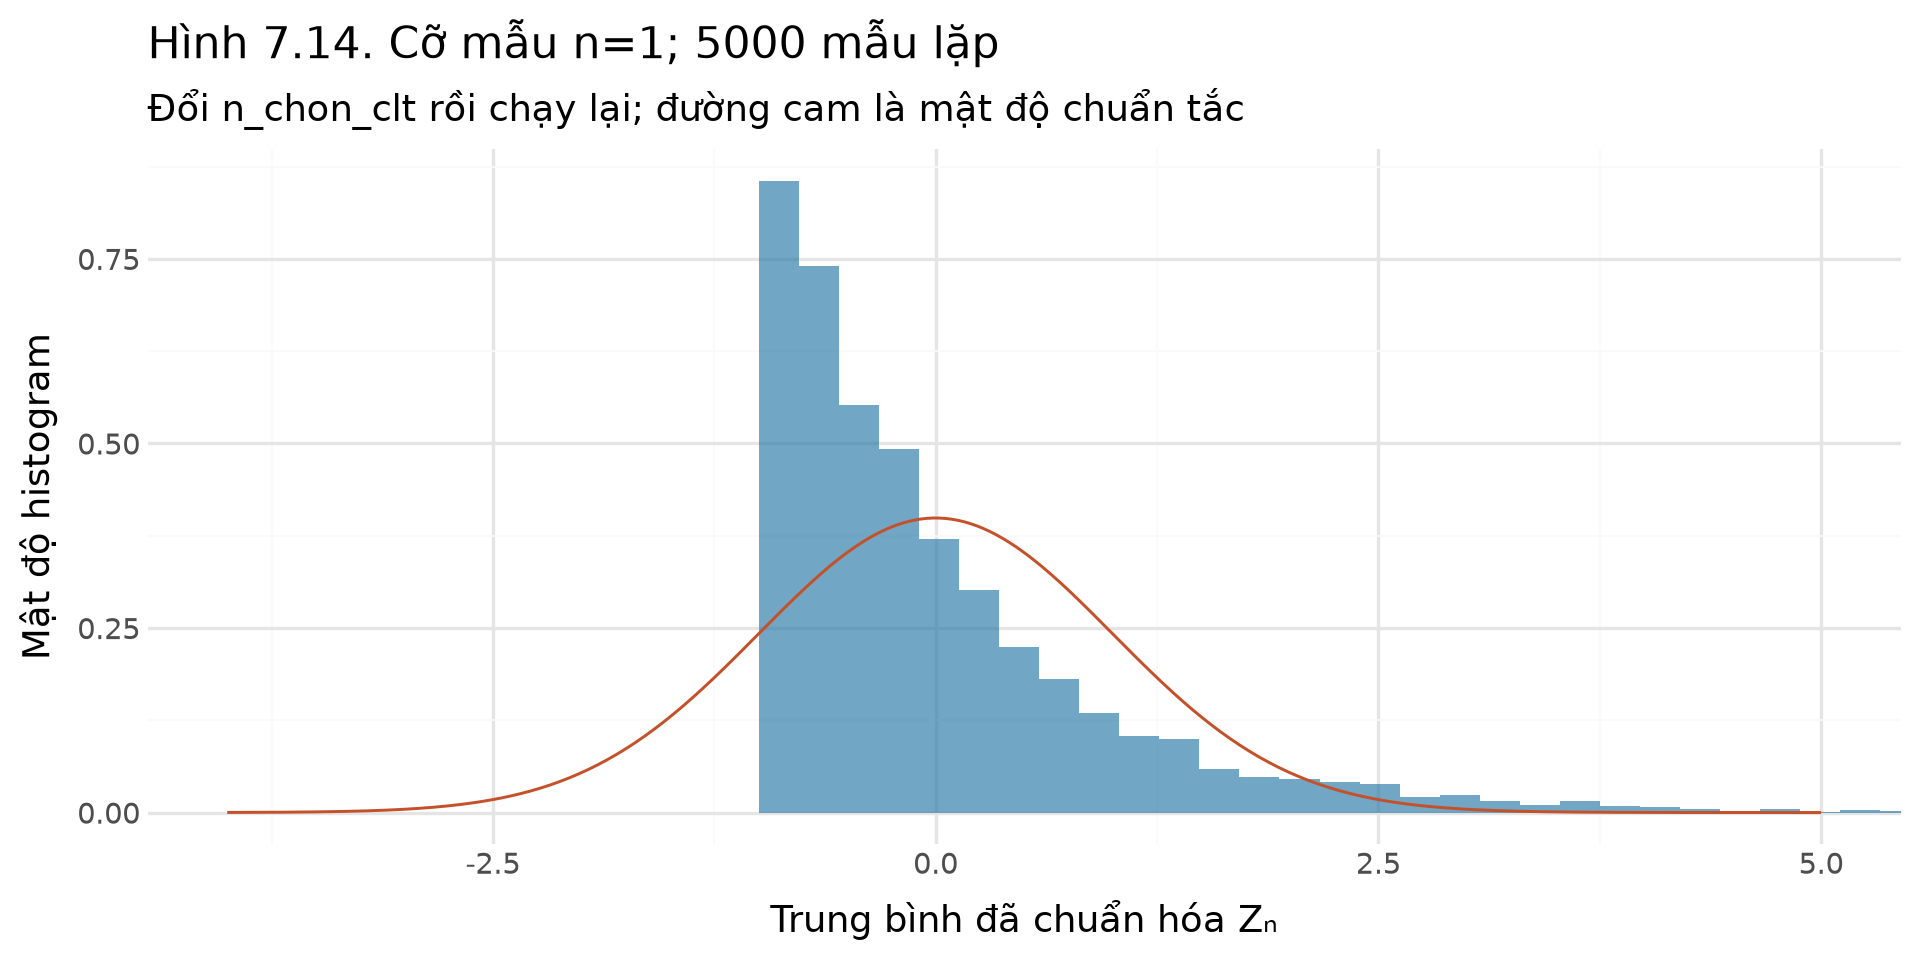

Chọn n từ: [1, 5, 30, 100] ; diện tích histogram = 1.0


In [23]:
n_chon_clt = 1  # Thử đổi sang một giá trị trong z_theo_n, rồi chạy lại ô này
assert n_chon_clt in z_theo_n, f"Chọn một trong {list(z_theo_n)}"
cao,bien=np.histogram(z_theo_n[n_chon_clt],bins=40,density=True)
bang_hist=pd.DataFrame({"trai":bien[:-1],"phai":bien[1:],"cao":cao})
bang_chuan=pd.DataFrame({"z":luoi_z,"mat_do":stats.norm.pdf(luoi_z)})
hinh = (p9.ggplot()
    + p9.geom_rect(bang_hist,p9.aes(xmin="trai",xmax="phai",ymin=0,ymax="cao"),fill="#2677A6",alpha=0.65)
    + p9.geom_line(bang_chuan,p9.aes("z","mat_do"),color="#C4512A")
    + p9.coord_cartesian(xlim=(-4,5))
    + p9.labs(x="Trung bình đã chuẩn hóa Zₙ",y="Mật độ histogram",
              title=f"Hình 7.14. Cỡ mẫu n={n_chon_clt}; {lap_clt} mẫu lặp",
              subtitle="Đổi n_chon_clt rồi chạy lại; đường cam là mật độ chuẩn tắc"))
display(hinh)
print("Chọn n từ:",list(z_theo_n),"; diện tích histogram =",np.sum(cao*np.diff(bien)))

### Cách dùng CLT và Ví dụ 15 — Trung bình thời gian xử lý

**Quy trình bốn bước.**

1. Xác định $\mu$ và $\sigma$ của **một** quan sát.
2. Tính kỳ vọng và SD của tổng hoặc trung bình (mục 3).
3. Chuẩn hóa: $z=\dfrac{\text{giá trị}-\text{kỳ vọng}}{\text{SD}}$.
4. Tra $\Phi(z)$, hoặc dùng `stats.norm`.

**Ví dụ 15.** Thời gian xử lý một yêu cầu có trung bình 12 phút, SD 6 phút, phân phối cá thể lệch phải. Chọn ngẫu nhiên 64 yêu cầu độc lập. (1) Xấp xỉ phân phối trung bình. (2) Tính xác suất trung bình vượt 13,5 phút. (3) Nêu điều kiện quan trọng.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.* Bước 1: $\mu=12$, $\sigma=6$. Bước 2: $\operatorname{SD}(\overline X_{64})=\frac6{\sqrt{64}}=\frac68=0{,}75$ phút. Theo CLT:
$$\overline X_{64}\approx\mathcal N\left(12,\ \frac{6^2}{64}\right)=\mathcal N(12;\ 0{,}75^2).$$

*Câu 2.* Bước 3: $z=\frac{13{,}5-12}{0{,}75}=2$. Bước 4:
$$P(\overline X_{64}>13{,}5)\approx P(Z>2)=1-\Phi(2)\approx0{,}0228.$$

*Câu 3.* Các yêu cầu i.i.d., phương sai hữu hạn và dương; chất lượng xấp xỉ còn phụ thuộc mức lệch của phân phối gốc. Thời gian của **từng** yêu cầu không có SD 0,75; chỉ **trung bình của 64 yêu cầu** mới có SD này.

</details>

Ô dưới tính bằng phân phối chuẩn với `scale=6/sqrt(64)`. Ta không mô phỏng một phân phối gốc cụ thể, vì đề chỉ cho trung bình, SD và dạng lệch phải; tự chọn một phân phối rồi gọi đó là dữ liệu thật sẽ thêm giả định.

*So với Chebyshev.* Ở Bài tập 3 (đo nhiệt độ, $\sigma=1$, cần $P(\lvert\overline X_n-\mu\rvert>0{,}2)\le0{,}01$), Chebyshev cần $n\ge2500$. Nếu dùng CLT, chỉ cần $\frac{0{,}2}{1/\sqrt n}\ge2{,}576$, tức $n\ge166$. Chebyshev chắc chắn nhưng quá thận trọng; CLT sát hơn nhưng chỉ là xấp xỉ.

In [24]:
n_yeu_cau = 64
sd_trung_binh = 6/np.sqrt(n_yeu_cau)
print("SD trung bình (phút):",sd_trung_binh)
print("P(TB > 13.5), xấp xỉ CLT:",stats.norm.sf(13.5,loc=12,scale=sd_trung_binh))

SD trung bình (phút): 0.75
P(TB > 13.5), xấp xỉ CLT: 0.022750131948179195


### CLT cho roulette: tâm xấu đi, hình vẫn gần chuẩn (theo STAT 20)

Theo hộp lợi nhuận $G$ ở mục 3, $E(G)=-\frac1{19}$ và $\operatorname{SD}(G)=\sqrt{1-1/19^2}$. Dựng lại STAT 20 §4.18.2 với $n=10,100,1000,5000$: tổng tiền sau nhiều lượt dần có dạng chuông, nhưng tâm ngày càng âm. CLT mô tả hình dạng và độ phân tán; nó không cải thiện một trò chơi có kỳ vọng âm.

Trong code, `p=[18/38,20/38]` là trọng số của hai giá trị $+1$ và $-1$, cộng lại bằng 1. Hãy đọc trục hoành ở từng hình: bốn trục cùng đơn vị đô la nhưng phạm vi khác nhau.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `color='loai'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_vline` thêm đường dọc tại `xintercept`. `geom_rect` vẽ mỗi hình chữ nhật từ các cận `xmin`, `xmax`, `ymin` và `ymax`. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

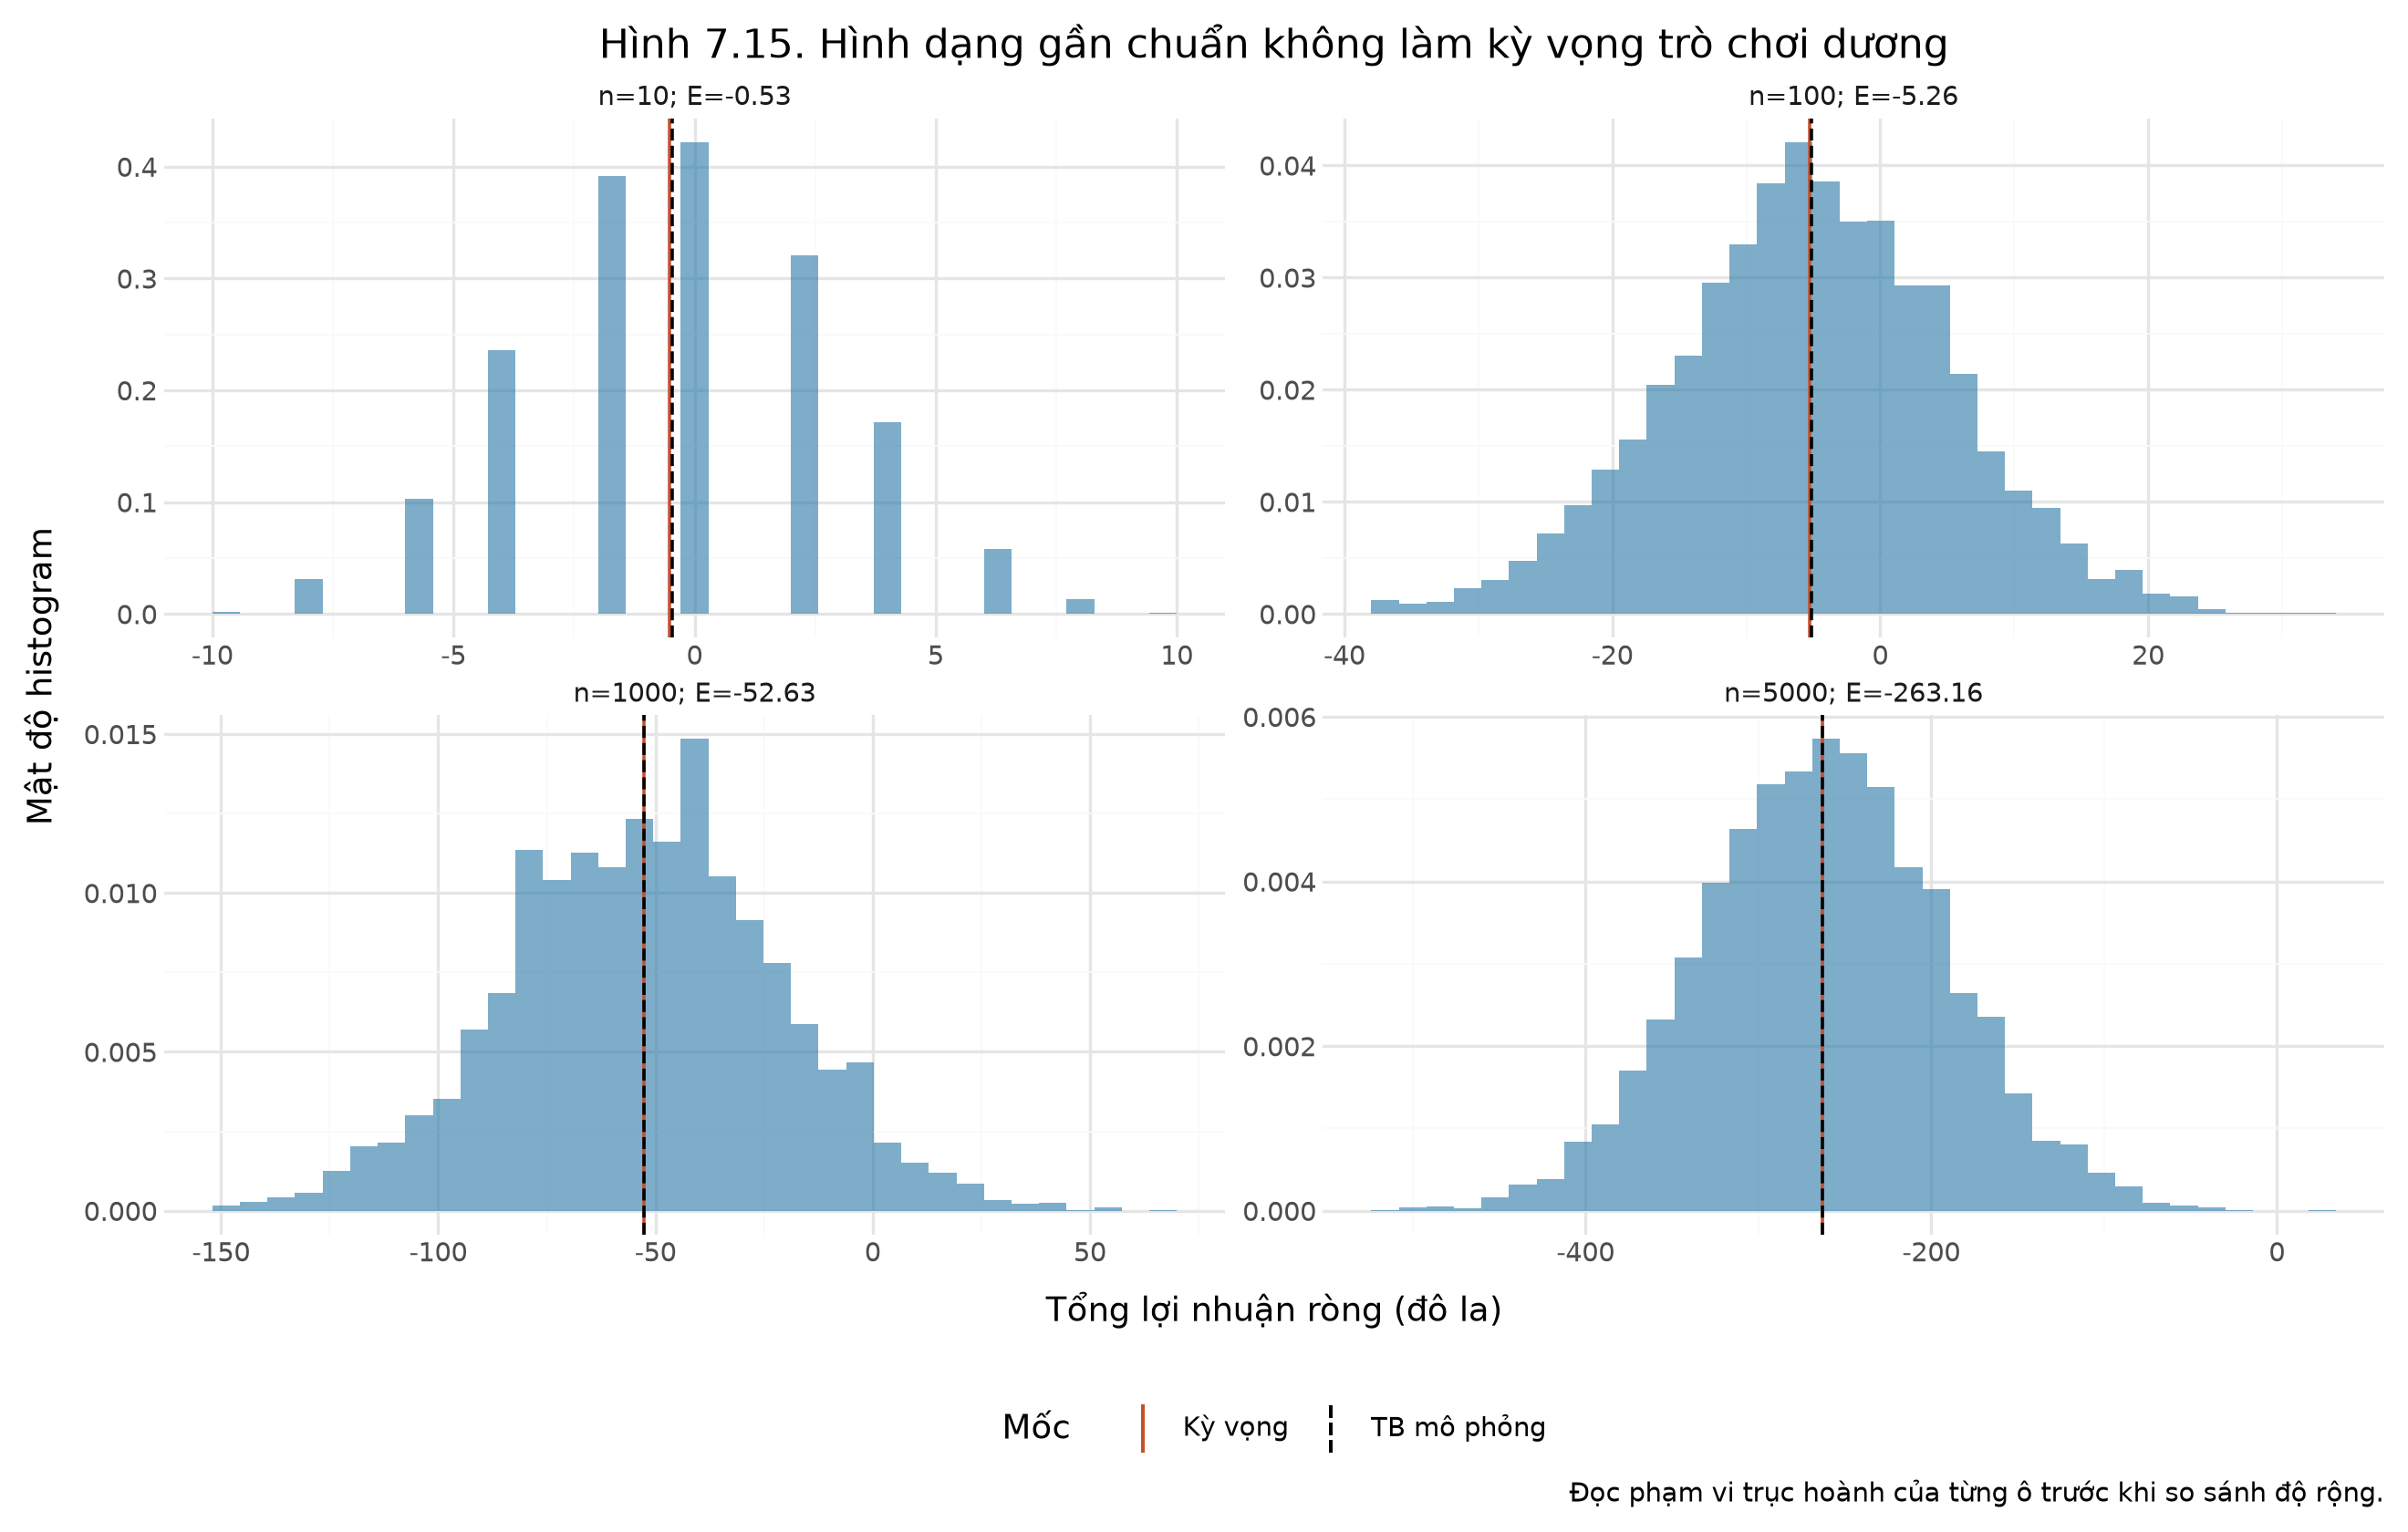

Trọng số của một lượt: [0.47368421 0.52631579] ; E(G): -0.05263157894736842 ; SD(G): 0.9986139979479092


In [25]:
gia_tri_gain=np.array([1,-1]);p_gain=np.array([18/38,20/38])
mu_gain=np.dot(gia_tri_gain,p_gain)
sd_gain=np.sqrt(np.dot((gia_tri_gain-mu_gain)**2,p_gain))
cac_hist=[];cac_moc=[];thu_tu_o=[]
for n in [10,100,1000,5000]:
    # Số lần thắng là nhị thức; tổng lợi nhuận = 2 × thắng − n.
    tong_gain=2*rng.binomial(n=n,p=18/38,size=5000)-n
    nhan_o=f"n={n}; E={n*mu_gain:.2f}"
    thu_tu_o.append(nhan_o)
    cao,bien=np.histogram(tong_gain,bins=35,density=True)
    cac_hist.append(pd.DataFrame({"trai":bien[:-1],"phai":bien[1:],"cao":cao,"o":nhan_o}))
    cac_moc.extend([{"o":nhan_o,"moc":n*mu_gain,"loai":"Kỳ vọng"},
                    {"o":nhan_o,"moc":tong_gain.mean(),"loai":"TB mô phỏng"}])
bang_hist=pd.concat(cac_hist,ignore_index=True)
bang_moc=pd.DataFrame(cac_moc)
for bang in [bang_hist,bang_moc]:
    bang["o"]=pd.Categorical(bang["o"],categories=thu_tu_o,ordered=True)
hinh = (p9.ggplot()
    + p9.geom_rect(bang_hist,p9.aes(xmin="trai",xmax="phai",ymin=0,ymax="cao"),fill="#2677A6",alpha=0.6)
    + p9.geom_vline(bang_moc,p9.aes(xintercept="moc",color="loai",linetype="loai"),size=0.6)
    + p9.scale_color_manual(values={"Kỳ vọng":"#C4512A","TB mô phỏng":"black"})
    + p9.scale_linetype_manual(values={"Kỳ vọng":"solid","TB mô phỏng":"dashed"})
    + p9.facet_wrap("o",ncol=2,scales="free")
    + p9.labs(x="Tổng lợi nhuận ròng (đô la)",y="Mật độ histogram",color="Mốc",linetype="Mốc",
              title="Hình 7.15. Hình dạng gần chuẩn không làm kỳ vọng trò chơi dương",
              caption="Đọc phạm vi trục hoành của từng ô trước khi so sánh độ rộng.")
    + p9.theme(figure_size=(11,7),legend_position="bottom"))
display(hinh)
print("Trọng số của một lượt:",p_gain,"; E(G):",mu_gain,"; SD(G):",sd_gain)

Ô trên mô phỏng tổng bằng nhị thức cho nhanh: mỗi lần thắng góp $+1$, mỗi lần thua góp $-1$, nên tổng là $2B-n$ với $B$ là số lần thắng. Cách này giữ đúng phân phối của hộp 38 vé và không phải tạo mảng hàng chục triệu lượt. *Thử thay đổi:* muốn xem từng lượt, chạy `rng.choice(gia_tri_gain, size=10, p=p_gain)`.

### Xấp xỉ chuẩn cho nhị thức và hiệu chỉnh liên tục

$X\sim\operatorname{Binomial}(n,p)$ là tổng của $n$ biến Bernoulli i.i.d., nên theo CLT, khi $n$ đủ lớn:

$$X\approx\mathcal N\big(np,\ np(1-p)\big).$$

Quy tắc kinh nghiệm thường dùng: $np\ge10$ và $n(1-p)\ge10$ (có sách dùng ngưỡng 5).

**Hiệu chỉnh liên tục.** $X$ chỉ nhận giá trị nguyên. Khi xấp xỉ bằng một đường cong liên tục, mỗi số nguyên $k$ ứng với một cột rộng 1, trải từ $k-0{,}5$ đến $k+0{,}5$. Vì vậy

$$P(X\le k)\approx\Phi\Big(\frac{k+0{,}5-np}{\sqrt{np(1-p)}}\Big).$$

*Ví dụ.* $X\sim\operatorname{Binomial}(100;\ 0{,}5)$: $np=50$, SD $=5$. Tính $P(X\le45)$:

| Cách tính | Kết quả |
|---|---:|
| Chính xác (nhị thức) | 0,1841 |
| Chuẩn, không hiệu chỉnh: $\Phi\big((45-50)/5\big)$ | 0,1587 |
| Chuẩn, có hiệu chỉnh: $\Phi\big((45{,}5-50)/5\big)$ | 0,1841 |

**Quay lại roulette: cược 100 lượt.** Tổng lợi nhuận $S$ có kỳ vọng $-5{,}26$ và SD $9{,}99$ đô la (mục 3). Xác suất người chơi còn có lời:

1. Không hiệu chỉnh: $P(S>0)\approx1-\Phi\big(\frac{0+5{,}26}{9{,}99}\big)=1-\Phi(0{,}53)\approx0{,}30$.
2. $S=2B-100$ chỉ nhận giá trị chẵn, nên "$S>0$" là "$S\ge2$"; điểm giữa của 0 và 2 là 1. Có hiệu chỉnh: $P(S>0)\approx1-\Phi\big(\frac{1+5{,}26}{9{,}99}\big)\approx0{,}265$.
3. Tính chính xác bằng nhị thức: $0{,}265$.

Sau 1.000 lượt, xác suất có lời chỉ còn khoảng 0,045. Kỳ vọng tăng theo $n$, còn SD chỉ tăng theo $\sqrt n$, nên khoảng cách từ 0 đến kỳ vọng, đo bằng số SD, tăng theo $\sqrt n$.

### Luật số lớn và CLT bổ sung cho nhau

| | Luật số lớn (mục 4) | Định lý giới hạn trung tâm |
|---|---|---|
| Nói về | $\overline X_n$ tiến về đâu | sai số $\overline X_n-\mu$ phân bố thế nào |
| Kết luận | $\overline X_n$ gần $\mu$ | $\overline X_n-\mu\approx\mathcal N(0,\ \sigma^2/n)$ |
| Thang đo | sai số tiến về 0 | sai số cỡ $\sigma/\sqrt n$, có hình chuông |
| Dùng cho | tin rằng mô phỏng và trung bình mẫu "đúng dần" | tính xác suất; khoảng tin cậy (Tuần 09), kiểm định (Tuần 10–11) |

<a id="hoc-7ddcafeb"></a>
## 8. Hai phân phối sinh ra từ phân phối chuẩn: $\chi^2$ và $t$

Buổi này chỉ cần **nhận diện** hai phân phối này: hình dạng, miền giá trị và ý nghĩa của tham số bậc tự do. Chúng chưa được dùng để lập khoảng tin cậy hay kiểm định. Điều quan trọng là chúng được **tạo ra từ phân phối chuẩn** như thế nào; đó là lý do chúng xuất hiện trong suy luận thống kê ở các tuần sau.

### Phân phối khi bình phương $\chi^2_\nu$

**Cách tạo ra.** Lấy $Z_1,\ldots,Z_\nu$ độc lập, cùng phân phối $\mathcal N(0,1)$. Khi đó

$$V=Z_1^2+\cdots+Z_\nu^2\sim\chi^2_\nu.$$

Đọc là: tổng bình phương của $\nu$ biến chuẩn tắc độc lập có phân phối khi bình phương với $\nu$ bậc tự do. "Bậc tự do" ở đây chính là số bình phương được cộng.

- $V\ge0$, vì là tổng các bình phương; phân phối lệch phải.
- $E(V)=\nu$, vì $E(Z_i^2)=\operatorname{Var}(Z_i)=1$.
- $\operatorname{Var}(V)=2\nu$, vì $\operatorname{Var}(Z^2)=E(Z^4)-1=3-1=2$ và các $Z_i$ độc lập.

### Phân phối $t$ Student $t_\nu$

**Cách tạo ra.** Lấy $Z\sim\mathcal N(0,1)$ và $V\sim\chi^2_\nu$ độc lập. Khi đó

$$T=\frac{Z}{\sqrt{V/\nu}}\sim t_\nu.$$

- Đối xứng quanh 0, vì $Z$ đối xứng.
- Đối xứng không tự bảo đảm kỳ vọng tồn tại. $E(T)=0$ khi $\nu>1$; với $\nu\le1$, kỳ vọng không tồn tại. Phương sai hữu hạn chỉ khi $\nu>2$, và khi đó $\operatorname{Var}(T)=\nu/(\nu-2)$. Với $1<\nu\le2$, kỳ vọng bằng 0 nhưng phương sai vô hạn. Vì vậy các công thức dùng moment hữu hạn và CLT ở trên phải được kiểm tra điều kiện trước khi áp dụng cho t.
- **Đuôi dày hơn** chuẩn tắc: mẫu số $\sqrt{V/\nu}$ cũng ngẫu nhiên, đôi khi nhỏ, làm $T$ lớn.
- Khi $\nu$ lớn, $V/\nu$ là trung bình của $\nu$ biến có kỳ vọng 1, nên theo luật số lớn $V/\nu$ gần 1, và $T$ gần $Z$.

| $\nu$ | 1 | 3 | 10 | 30 | chuẩn tắc |
|---|---:|---:|---:|---:|---:|
| $P(\lvert T\rvert>2)$ | 0,295 | 0,139 | 0,073 | 0,055 | 0,046 |

Ở các tuần 9–11, $t$ xuất hiện khi thay $\sigma$ chưa biết bằng $s$ tính từ mẫu; độ bất định thêm vào do phải ước lượng $\sigma$ chính là phần đuôi dày hơn.

<details><summary><b>Đọc thêm</b> Công thức mật độ của $\chi^2_\nu$ và $t_\nu$</summary>

Không cần nhớ hai công thức này để làm bài của buổi 7.

$$\chi^2_\nu:\quad f(x)=\frac{x^{\nu/2-1}e^{-x/2}}{2^{\nu/2}\Gamma(\nu/2)},\quad x>0;\qquad f(x)=0\ (x<0).$$

$$t_\nu:\quad f(x)=\frac{\Gamma((\nu+1)/2)}{\sqrt{\nu\pi}\,\Gamma(\nu/2)}\left(1+\frac{x^2}{\nu}\right)^{-(\nu+1)/2},\quad x\in\mathbb R.$$

$\Gamma$ là hàm Gamma, đọc là *gam-ma*; với số nguyên dương $m$, $\Gamma(m)=(m-1)!$, và $\Gamma(\frac12)=\sqrt\pi$. Trong hai công thức, hàm Gamma chỉ đóng vai trò hằng số để tổng diện tích bằng 1. Mật độ tại đúng điểm 0 của $\chi^2$ không ảnh hưởng xác suất.

</details>

Hình dưới dùng SciPy để vẽ các mật độ theo công thức; đây không phải phân phối của dữ liệu thu thập. Quan sát đuôi của $t$ so với đường chuẩn tắc nét đứt, và sự lệch phải của $\chi^2$.

<!-- branch-plot-instructions:start -->

**Đọc code vẽ bằng Plotnine.** Đọc ánh xạ đầu tiên `x='x', y='mat_do', color='duong'` trong `aes`; tên biến được lấy từ bảng dữ liệu của lớp tương ứng. `geom_line` nối các điểm theo thứ tự của `x`; đọc `group` hoặc ánh xạ màu để biết các đường được tách thế nào. Facet chia cùng một biểu đồ theo biến nhóm; kiểm tra tham số `scales` trước khi so độ lớn giữa các ô. Trước khi chạy, nêu câu hỏi hình trả lời. Sau khi chạy, chỉ ra đặc điểm trên trục, nhóm hoặc vùng tô màu giúp trả lời câu hỏi đó.

<!-- branch-plot-instructions:end -->

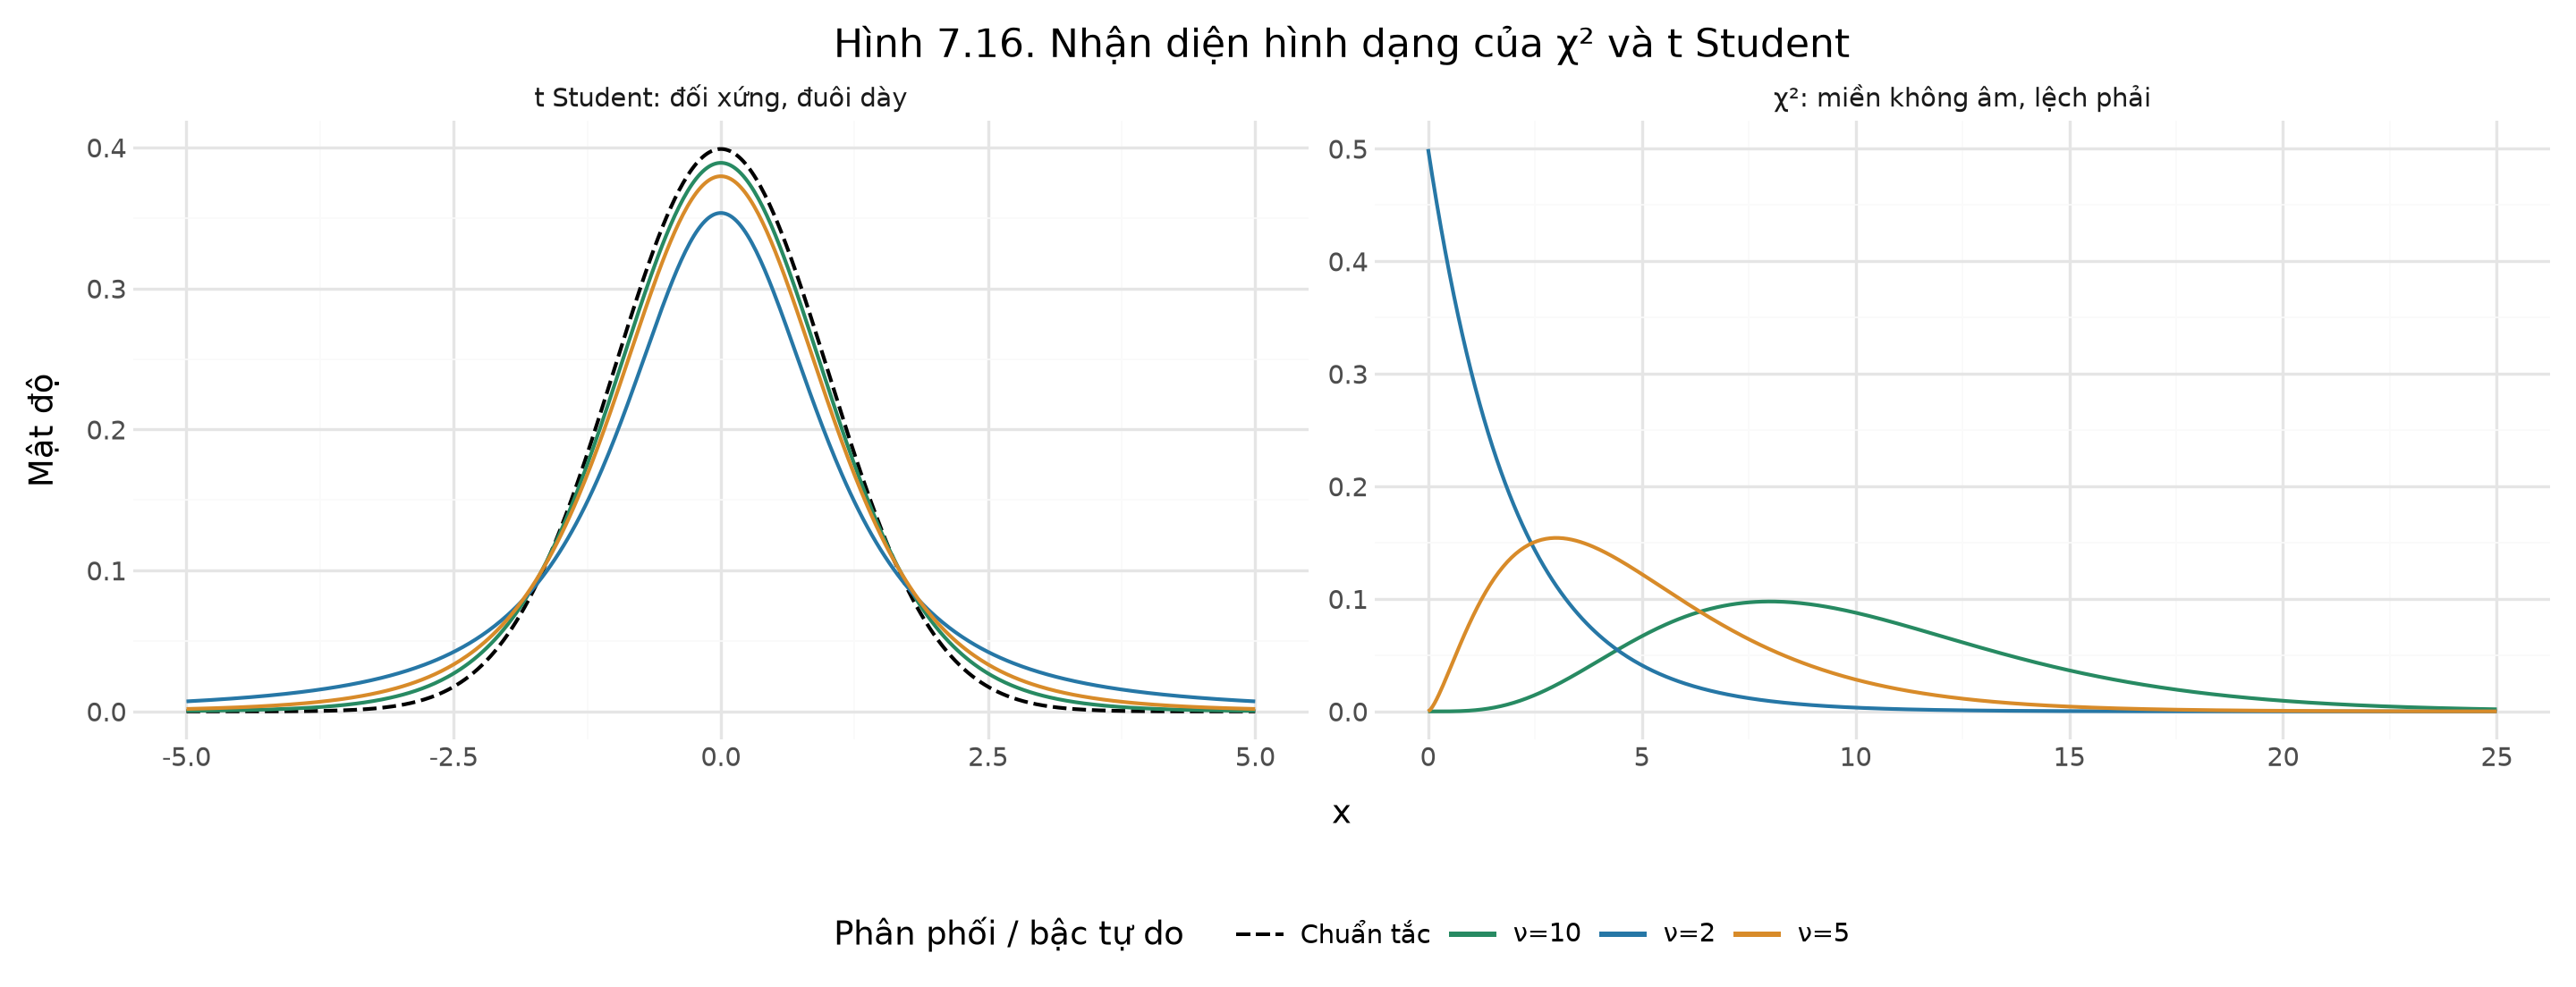

In [26]:
luoi_duong=np.linspace(0.001,25,500)
luoi_t=np.linspace(-5,5,500)
cac_duong=[]
for nu in [2,5,10]:
    cac_duong.append(pd.DataFrame({"x":luoi_duong,"mat_do":stats.chi2.pdf(luoi_duong,df=nu),
                                  "o":"χ²: miền không âm, lệch phải","duong":f"ν={nu}"}))
    cac_duong.append(pd.DataFrame({"x":luoi_t,"mat_do":stats.t.pdf(luoi_t,df=nu),
                                  "o":"t Student: đối xứng, đuôi dày","duong":f"ν={nu}"}))
cac_duong.append(pd.DataFrame({"x":luoi_t,"mat_do":stats.norm.pdf(luoi_t),
                              "o":"t Student: đối xứng, đuôi dày","duong":"Chuẩn tắc"}))
bang_pdf=pd.concat(cac_duong,ignore_index=True)
hinh = (p9.ggplot(bang_pdf,p9.aes("x","mat_do",color="duong",linetype="duong"))
    + p9.geom_line(size=0.7)
    + p9.facet_wrap("o",ncol=2,scales="free")
    + p9.scale_color_manual(values={"ν=2":"#2677A6","ν=5":"#D88B29","ν=10":"#278A62","Chuẩn tắc":"black"})
    + p9.scale_linetype_manual(values={"ν=2":"solid","ν=5":"solid","ν=10":"solid","Chuẩn tắc":"dashed"})
    + p9.labs(x="x",y="Mật độ",color="Phân phối / bậc tự do",linetype="Phân phối / bậc tự do",
              title="Hình 7.16. Nhận diện hình dạng của χ² và t Student")
    + p9.theme(figure_size=(12,4.6),legend_position="bottom"))
display(hinh)

<a id="hoc-3a07ac29"></a>
## 9. Bài tập vận dụng

Các bài giữ nhãn gốc. Trước khi tính, hãy nhận diện biến ngẫu nhiên, đơn vị, mô hình và điều kiện. Đáp án nằm dưới từng đề; ô code sau đáp án dùng để kiểm tra hoặc thử tham số.

### Bài tập 6 — Dung lượng USB

Dung lượng USB được khách hàng mua là $X$ (GB), với bảng:

| $x$ (GB) | 1 | 2 | 4 | 8 | 16 |
|---|---:|---:|---:|---:|---:|
| $p_X(x)$ | 0,05 | 0,10 | 0,35 | 0,40 | 0,10 |

1. Tính $E(X)$ và $E(X^2)$.
2. Tính phương sai từ định nghĩa.
3. Kiểm tra bằng công thức rút gọn.
4. Tính SD, ghi đúng đơn vị.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.*
$$E(X)=1(0{,}05)+2(0{,}10)+4(0{,}35)+8(0{,}40)+16(0{,}10)=0{,}05+0{,}2+1{,}4+3{,}2+1{,}6=6{,}45\text{ GB}.$$
$$E(X^2)=1(0{,}05)+4(0{,}10)+16(0{,}35)+64(0{,}40)+256(0{,}10)=0{,}05+0{,}40+5{,}60+25{,}60+25{,}60=57{,}25\text{ GB}^2.$$

*Câu 2.* Từ định nghĩa, cộng các số hạng $(x-6{,}45)^2p_X(x)$:
$$\operatorname{Var}(X)=\sum_x(x-6{,}45)^2p_X(x)=15{,}6475\text{ GB}^2.$$

*Câu 3.* $57{,}25-6{,}45^2=57{,}25-41{,}6025=15{,}6475$. Hai cách khớp nhau.

*Câu 4.* $\operatorname{SD}(X)=\sqrt{15{,}6475}\approx3{,}9557$ GB.

Không USB nào trong bảng có dung lượng 6,45 GB; đó là dung lượng trung bình của cơ cấu bán hàng.

</details>

Ô dưới hiển thị từng số hạng của hai cách tính phương sai, để bạn tìm lỗi nếu thay phân phối.

In [27]:
x_usb=np.array([1,2,4,8,16]);p_usb=np.array([0.05,0.10,0.35,0.40,0.10])
assert np.isclose(p_usb.sum(),1)
e_usb=np.dot(x_usb,p_usb);e2_usb=np.dot(x_usb**2,p_usb)
var_usb=np.dot((x_usb-e_usb)**2,p_usb)
display(pd.DataFrame({"GB":x_usb,"p":p_usb,"x p":x_usb*p_usb,"x² p":x_usb**2*p_usb,
                      "(x−μ)² p":(x_usb-e_usb)**2*p_usb}))
print("E / E(X²) / Var / SD:",e_usb,e2_usb,var_usb,np.sqrt(var_usb))
assert np.isclose(var_usb,e2_usb-e_usb**2) and np.isclose(var_usb,15.6475)

,GB,p,x p,x² p,(x−μ)² p
0,1,0.05,0.05,0.05,1.48512
1,2,0.10,0.20,0.40,1.98025
2,4,0.35,1.40,5.60,2.10087
3,8,0.40,3.20,25.60,0.96100
4,16,0.10,1.60,25.60,9.12025


E / E(X²) / Var / SD: 6.449999999999999 57.25 15.6475 3.955692101263697


### Bài tập 7 — Tìm đầu mút từ cdf

Biến liên tục $X$ nhận giá trị trên $[0,b]$, $b>0$, có
$$F_X(x)=\begin{cases}0,&x<0,\\x^2/9,&0\le x\le b,\\1,&x>b.\end{cases}$$
1. Tìm $b$.
2. Tìm pdf trên toàn bộ trục số.

<details><summary>Đáp án và cách lập luận</summary>

*Câu 1.* $X$ liên tục nên cdf liên tục tại $b$, không có bước nhảy. Do đó $\frac{b^2}9=1$, tức $b^2=9$; với $b>0$ được $b=3$.

*Câu 2.* Lấy đạo hàm cdf trên từng khoảng: $\left(\frac{x^2}9\right)'=\frac{2x}9$ trên $(0,3)$, và đạo hàm của hằng số bằng 0 ở ngoài.
$$f_X(x)=\begin{cases}2x/9,&0<x<3,\\0,&\text{nơi khác}.\end{cases}$$

Giá trị mật độ tại hai đầu mút không làm đổi xác suất; cdf luôn cho đúng xác suất kể cả ở đầu mút.

</details>

Ô dưới kiểm tra diện tích dưới pdf bằng 1. Nếu không dùng điều kiện liên tục để chọn $b$, công thức cdf có thể có một bước nhảy (khối xác suất tại đầu mút) hoặc vượt 1.

In [28]:
b_cdf=3.0
dien_tich = integrate.quad(lambda x:2*x/9,0,b_cdf)[0]
print("b =",b_cdf,"; tích phân pdf =",dien_tich)
assert np.isclose(dien_tich,1)

b = 3.0 ; tích phân pdf = 1.0


### Bài tập 8 — Tổng khối lượng trong thang máy

Trong **mô hình giả định của đề**, khối lượng người được chọn có phân phối chuẩn, trung bình 65 kg, SD 5 kg; các khối lượng độc lập. Một thang máy chở tối đa 10 người, tải trọng 700 kg. Tính xác suất 10 người được chọn ngẫu nhiên cùng vào mà không quá tải. Các số 65 và 5 không phải thống kê thực tế về dân số Việt Nam.

<details><summary>Đáp án và cách lập luận</summary>

*Bước 1.* Đặt $S_{10}=X_1+\cdots+X_{10}$. $E(S_{10})=10\cdot65=650$ kg; $\operatorname{Var}(S_{10})=10\cdot5^2=250$, nên $\operatorname{SD}(S_{10})=5\sqrt{10}\approx15{,}81$ kg.

*Bước 2.* Tổng của các biến chuẩn độc lập là chuẩn **chính xác**: $S_{10}\sim\mathcal N(650,\ 250)$. Không cần viện dẫn CLT.

*Bước 3.*
$$P(S_{10}\le700)=\Phi\left(\frac{700-650}{5\sqrt{10}}\right)\approx\Phi(3{,}1623)\approx0{,}9992.$$

Theo giả định của mô hình, xác suất không quá tải khoảng 99,92%. Đây là bài về **tổng** khối lượng, không phải trung bình.

</details>

*Thử thay đổi* trong ô dưới: đổi số người (từ 1 đến 10, theo giới hạn của đề) hoặc tải trọng để thấy xác suất thay đổi.

In [29]:
so_nguoi = 10  # Thử đổi trong 1..10
tai_trong = 700
mu_tong = 65*so_nguoi
sd_tong = 5*np.sqrt(so_nguoi)
print("Tâm / SD tổng (kg):",mu_tong,sd_tong)
print("P(tổng ≤ tải trọng), theo mô hình:",stats.norm.cdf(tai_trong,loc=mu_tong,scale=sd_tong))

Tâm / SD tổng (kg): 650 15.811388300841898
P(tổng ≤ tải trọng), theo mô hình: 0.9992172988709987


### Bài tập 9 — Khoảng cách từ nhà đến trường

Khoảng cách $X$ (km) của một sinh viên được chọn được **giả sử phân phối mũ**, kỳ vọng 5 km. Các khoảng cách của sinh viên được chọn i.i.d.

1. Tính xác suất một sinh viên cách trường hơn 10 km.
2. Với 100 sinh viên, dùng CLT tính gần đúng xác suất **tổng** khoảng cách không quá 300 km.
3. Tính gần đúng xác suất **trung bình** của 100 sinh viên nằm trong (4,9;5,2) km.
4. Tính **chính xác** xác suất khoảng cách của **một** sinh viên nằm trong (4,9;5,2) km.
5. Tính gần đúng xác suất trung bình của 36 sinh viên trong cùng khoảng.

<details><summary>Đáp án và cách lập luận</summary>

Phân phối mũ có $E(X)=\operatorname{SD}(X)=\frac1\lambda=5$ km, nên $\lambda=\frac15$ mỗi km.

1. *Một sinh viên, chính xác:* $P(X>10)=e^{-10/5}=e^{-2}\approx0{,}1353$.
2. *Tổng 100 sinh viên (CLT):* $E(S_{100})=500$ km, $\operatorname{SD}(S_{100})=5\sqrt{100}=50$ km. $z=\frac{300-500}{50}=-4$, nên $P(S_{100}\le300)\approx\Phi(-4)\approx0{,}00003$.
3. *Trung bình 100 sinh viên (CLT):* $\operatorname{SD}(\overline X_{100})=\frac5{\sqrt{100}}=0{,}5$ km. Hai cận ứng với $z=\frac{4{,}9-5}{0{,}5}=-0{,}2$ và $z=\frac{5{,}2-5}{0{,}5}=0{,}4$, nên xác suất $\approx\Phi(0{,}4)-\Phi(-0{,}2)\approx0{,}2347$.
4. *Một sinh viên, chính xác:* $P(4{,}9<X<5{,}2)=e^{-4{,}9/5}-e^{-5{,}2/5}\approx0{,}0219$.
5. *Trung bình 36 sinh viên (CLT):* $\operatorname{SD}(\overline X_{36})=\frac56$ km; hai cận ứng với $z=-0{,}12$ và $z=0{,}24$, nên xác suất $\approx\Phi(0{,}24)-\Phi(-0{,}12)\approx0{,}1426$.

Câu 3 và 5 cùng khoảng nhưng SD của trung bình khác nhau. Câu 4 dùng phân phối của **từng** sinh viên, nên không thể thay bằng phân phối chuẩn của trung bình. Câu 2 nằm ở đuôi xa ($z=-4$): CLT cho một xấp xỉ như đề yêu cầu, nhưng độ chính xác tương đối ở đuôi có thể thấp; không gọi đó là xác suất chính xác.

</details>

Ô dưới dùng mô hình mũ cho câu 1 và 4, mô hình chuẩn xấp xỉ cho câu 2, 3, 5. Kiểm tra `scale` theo **đại lượng đang hỏi** (một sinh viên, tổng hay trung bình) trước khi chạy.

In [30]:
khoang_cach = stats.expon(scale=5)
dap_an9 = {
    "1. Một người >10 km (chính xác)":khoang_cach.sf(10),
    "2. Tổng100 ≤300 km (CLT)":stats.norm.cdf(300,loc=500,scale=50),
    "3. TB100 trong (4.9,5.2) (CLT)":stats.norm.cdf(5.2,loc=5,scale=0.5)-stats.norm.cdf(4.9,loc=5,scale=0.5),
    "4. Một người trong (4.9,5.2) (chính xác)":khoang_cach.cdf(5.2)-khoang_cach.cdf(4.9),
    "5. TB36 trong (4.9,5.2) (CLT)":stats.norm.cdf(5.2,loc=5,scale=5/6)-stats.norm.cdf(4.9,loc=5,scale=5/6)
}
display(pd.Series(dap_an9,name="Xác suất"))

1. Một người >10 km (chính xác)             0.13534
2. Tổng100 ≤300 km (CLT)                    0.00003
3. TB100 trong (4.9,5.2) (CLT)              0.23468
4. Một người trong (4.9,5.2) (chính xác)    0.02186
5. TB36 trong (4.9,5.2) (CLT)               0.14259
Name: Xác suất, dtype: float64

### Bài tập 10 — Dự trữ linh kiện

Hệ thống cần một linh kiện thiết yếu. Khi hỏng, thay ngay; bỏ qua thời gian thay và giả sử không có nguyên nhân hỏng khác. Tuổi thọ các linh kiện i.i.d., trung bình 100 giờ, SD 30 giờ. Dùng CLT ước tính số linh kiện để xác suất hoạt động liên tục **ít nhất 2.000 giờ** đạt **ít nhất 95%**. Số lượng tính cả linh kiện lắp ban đầu.

<details><summary>Đáp án và cách lập luận</summary>

*Bước 1.* Đặt $S_n$ là tổng tuổi thọ của $n$ linh kiện. $E(S_n)=100n$, $\operatorname{SD}(S_n)=30\sqrt n$.

*Bước 2: CLT.*
$$P(S_n\ge2000)\approx P\left(Z\ge\frac{2000-100n}{30\sqrt n}\right)=\Phi\left(\frac{100n-2000}{30\sqrt n}\right).$$

*Bước 3.* Muốn xấp xỉ này ít nhất 0,95:
$$\frac{100n-2000}{30\sqrt n}\ge\Phi^{-1}(0{,}95)\approx1{,}64485.$$
Đặt $u=\sqrt n>0$, nhân hai vế với $30u$: $100u^2-49{,}3455u-2000\ge0$.

*Bước 4: kiểm tra các số nguyên gần ngưỡng.*

| $n$ | Xác suất theo CLT |
|---|---:|
| 22 | 0,9224 |
| 23 | 0,9815 |

Chọn **23 linh kiện = 1 ban đầu + 22 dự phòng**. Đây là ước tính theo CLT, không bảo đảm cho mọi phân phối tuổi thọ chỉ biết trung bình và SD. Không làm tròn $u$ trước rồi bình phương; hãy kiểm tra trực tiếp các số nguyên $n$.

</details>

Ô dưới tính xác suất cho các $n$ lân cận và chọn số nguyên nhỏ nhất đạt ngưỡng **theo xấp xỉ**. Nhìn bước nhảy từ 22 lên 23 để thấy vì sao phải kiểm tra từng số nguyên.

In [31]:
moc_gio = 2000
nguong_prob = 0.95
ds_linh_kien = np.arange(18,27)
p_hoat_dong = stats.norm.cdf((100*ds_linh_kien-moc_gio)/(30*np.sqrt(ds_linh_kien)))
display(pd.DataFrame({"Tổng số linh kiện":ds_linh_kien,"P hoạt động ≥2000h (CLT)":p_hoat_dong}))
n_chon = int(ds_linh_kien[p_hoat_dong>=nguong_prob][0])
print("Chọn",n_chon,"linh kiện; dự phòng",n_chon-1,"(theo xấp xỉ CLT).")
assert n_chon==23

,Tổng số linh kiện,P hoạt động ≥2000h (CLT)
0,18,0.05805
1,19,0.22222
2,20,0.50000
3,21,0.76651
4,22,0.92239
5,23,0.98147
6,24,0.99675
7,25,0.99957
8,26,0.99996


Chọn 23 linh kiện; dự phòng 22 (theo xấp xỉ CLT).


Ô cuối của phần bài tập kiểm tra lại các mốc tính tay chính (cặp sản phẩm, phần bánh, hộp 10 lá, USB, linh kiện). Nếu một lệnh `assert` báo lỗi sau khi bạn thử đổi tham số ở trên, hãy chạy lại notebook từ đầu.

In [32]:
# Kiểm tra các mốc tính tay chính trước khi kết thúc Run All.
assert np.isclose(mu_dat,1.6) and np.isclose(var_dat,0.32)
assert np.isclose(np.dot(phan_banh,p_ban),7/12)
assert np.isclose(mu_hop,1.9) and np.isclose(var_hop,2.09)
assert np.isclose(var_usb,15.6475) and n_chon==23
print("Đã kiểm tra các mốc: cặp sản phẩm, phần bánh, hộp10 lá, USB và linh kiện.")

Đã kiểm tra các mốc: cặp sản phẩm, phần bánh, hộp10 lá, USB và linh kiện.


<a id="hoc-r7-004"></a>
## 10. Tóm tắt và lỗi hay gặp

| Công thức | Đọc thành lời |
|---|---|
| $E(X)=\sum_x x\,p_X(x)$; $E(X)=\int x\,f_X(x)\,dx$ | Trung bình các giá trị, mỗi giá trị nhân với xác suất (hoặc mật độ) của nó. |
| $E(aX+b)=aE(X)+b$; $E(X+Y)=E(X)+E(Y)$ | Kỳ vọng đi qua phép cộng và nhân hằng số, **không cần độc lập**. |
| $\mathrm{Var}(X)=E[(X-\mu)^2]=E(X^2)-[E(X)]^2$ | Trung bình của bình phương độ lệch; bằng trung bình bình phương trừ bình phương trung bình. |
| $\mathrm{Var}(aX+b)=a^2\mathrm{Var}(X)$ | Dịch không đổi độ phân tán; nhân $a$ thì phương sai nhân $a^2$. |
| $\mathrm{Var}(X\pm Y)=\mathrm{Var}(X)+\mathrm{Var}(Y)$ (độc lập) | Phương sai cộng được khi độc lập; SD thì không. |
| $E(S_n)=n\mu$, $\mathrm{SD}(S_n)=\sigma\sqrt n$ | Tổng: kỳ vọng tăng $n$ lần, SD tăng $\sqrt n$ lần. |
| $E(\overline X_n)=\mu$, $\mathrm{SD}(\overline X_n)=\sigma/\sqrt n$ | Trung bình: tâm giữ nguyên, SD giảm theo $\sqrt n$. |
| $P(\lvert X-\mu\rvert\ge\varepsilon)\le\sigma^2/\varepsilon^2$ | Chebyshev: cận trên đúng với mọi phân phối có phương sai hữu hạn. |
| $P(\lvert\overline X_n-\mu\rvert>\varepsilon)\to0$ | Luật số lớn: trung bình mẫu tiến về kỳ vọng. |
| $P(a<X<b)=\int_a^b f_X(x)\,dx$ | Với biến liên tục, xác suất là diện tích; $P(X=a)=0$. |
| $U(a,b)$: $E=\frac{a+b}2$, $\mathrm{Var}=\frac{(b-a)^2}{12}$ | Đều: tâm là điểm giữa. |
| $\operatorname{Exp}(\lambda)$: $P(X>t)=e^{-\lambda t}$, $E=\frac1\lambda$ | Mũ: thời gian chờ, không nhớ. |
| $Z=\frac{X-\mu}\sigma$; $P(X\le x)=\Phi\big(\frac{x-\mu}\sigma\big)$ | Chuẩn hóa: đo khoảng cách bằng số SD. |
| $\overline X_n\approx\mathcal N(\mu,\sigma^2/n)$ | CLT: trung bình của nhiều lần rút i.i.d. có hình gần chuông. |

### Lỗi hay gặp

| Lỗi | Sửa |
|---|---|
| Nghĩ kỳ vọng phải là một giá trị có thể xảy ra | $E(X)=1{,}6$ sản phẩm là trung bình dài hạn, không phải một kết quả. |
| Viết $E[g(X)]=g(E(X))$ | Với $g(x)=ax+b$, đẳng thức luôn đúng khi kỳ vọng tồn tại. Với hàm phi tuyến, nói chung phải tính $\sum g(x)p_X(x)$; đẳng thức vẫn có thể đúng trong một trường hợp riêng. |
| Cộng SD của hai biến độc lập | Cộng phương sai rồi lấy căn: $\sqrt{3^2+4^2}=5$. |
| Viết $\mathrm{Var}(X-Y)=\mathrm{Var}(X)-\mathrm{Var}(Y)$ | Với biến độc lập, phương sai của hiệu cũng là tổng hai phương sai. |
| Coi $f_X(x)$ là xác suất | Mật độ có thể lớn hơn 1; xác suất là diện tích. |
| Truyền phương sai vào `scale` của `stats.norm` | `scale` là SD: $\mathcal N(500,\ 2^2)$ thì `scale=2`. |
| Dùng `expon(scale=lam)` | `scale` là $1/\lambda$, tức kỳ vọng. |
| Nói "theo CLT, dữ liệu có phân phối chuẩn" | CLT nói về tổng hoặc trung bình, không nói về từng quan sát. |
| Tin "đồng xu sẽ bù lại" | Các lần tung độc lập; tỉ lệ tiến về $p$ nhờ pha loãng, không nhờ bù. |

<a id="hoc-b257227b"></a>
## 11. Tự kiểm tra và chuẩn bị giữa kỳ

Kỳ vọng là trung tâm của **phân phối**, không nhất thiết là một kết quả có thể xảy ra. Phương sai đo bình phương độ lệch; SD đưa về đơn vị gốc. Kỳ vọng cộng được dù phụ thuộc; muốn cộng phương sai phải có độc lập hoặc tính thêm hiệp phương sai. Với i.i.d., tổng có SD $\sigma\sqrt n$, trung bình có SD $\sigma/\sqrt n$.

Chebyshev cho cận sai lệch khi có phương sai hữu hạn. Luật số lớn giải thích vì sao trung bình ổn định; CLT giải thích hình dạng phân phối của tổng hoặc trung bình. Cả hai nói về việc lặp lại và tăng cỡ mẫu, không nói mỗi kết quả riêng sẽ tiến về trung bình.

Với biến liên tục, xác suất là diện tích; cdf là diện tích bên trái. Nhận diện đều, chuẩn, mũ, $\chi^2$, $t$ bằng miền giá trị, hình dạng và tham số. Khi dùng phân phối chuẩn, phân biệt SD với phương sai; `loc` và `scale` của SciPy có nghĩa khác nhau tùy mô hình.

**Câu hỏi.**

1. $E(X)=2$ và $\mathrm{Var}(X)=9$. Tính $E(3X-5)$, $\mathrm{SD}(3X-5)$ và $E(X^2)$.
2. $X$ và $Y$ độc lập, $\mathrm{SD}(X)=6$, $\mathrm{SD}(Y)=8$. Tính $\mathrm{SD}(X-Y)$.
3. Một chiếc cân có sai số ngẫu nhiên với SD 0,5 g. Cân một vật 16 lần rồi lấy trung bình. SD của kết quả trung bình là bao nhiêu?
4. Một biến có $\mu=50$ và $\sigma=5$, không biết phân phối. Chebyshev nói gì về $P(40<X<60)$?
5. $f(x)=cx^2$ trên $(0,3)$ và bằng 0 ở ngoài. Tìm $c$, rồi tính $P(X>2)$.
6. Thời gian phục vụ có phân phối mũ với trung bình 4 phút. Một khách đã được phục vụ 4 phút. Xác suất cần thêm hơn 2 phút nữa là bao nhiêu?
7. Một máy đóng gói có khối lượng mỗi gói trung bình 250 g, SD 10 g. Một thùng có 100 gói. Tính xấp xỉ xác suất thùng nặng hơn 25,2 kg.
8. Một bạn nói: "Theo CLT, chiều cao của 1000 sinh viên trong trường có phân phối chuẩn." Câu này sai ở đâu?

<details><summary>Đáp án tự kiểm tra</summary>

1. $E(3X-5)=3\cdot2-5=1$. $\mathrm{SD}(3X-5)=3\cdot3=9$. $E(X^2)=\mathrm{Var}(X)+[E(X)]^2=9+4=13$.
2. $\sqrt{36+64}=10$. Phương sai của hiệu vẫn là tổng hai phương sai.
3. $0{,}5/\sqrt{16}=0{,}125$ g.
4. $40<X<60$ nghĩa là $\lvert X-50\rvert<10=2\sigma$. Theo Chebyshev, $P(\lvert X-50\rvert\ge10)\le\frac14$, nên $P(40<X<60)\ge0{,}75$.
5. $\int_0^3cx^2\,dx=9c=1$, nên $c=\frac19$. $P(X>2)=\int_2^3\frac{x^2}9\,dx=\frac{27-8}{27}=\frac{19}{27}\approx0{,}704$.
6. Theo tính không nhớ, xác suất bằng $P(X>2)=e^{-2/4}\approx0{,}607$.
7. Tổng có kỳ vọng 25.000 g và SD $10\sqrt{100}=100$ g. $P(S>25\,200)\approx1-\Phi(2)\approx0{,}023$.
8. CLT nói về **tổng hoặc trung bình** của nhiều biến ngẫu nhiên, không nói về phân phối của từng quan sát.

</details>

Trước buổi 8, làm lại Bài tập 1–10 khi đóng đáp án và ghi lại các câu chưa hiểu. Buổi 8 là kiểm tra giữa kỳ và giải đáp: ôn dữ liệu, thống kê mô tả, xác suất, biến ngẫu nhiên, nhận diện mô hình và cách tính xác suất, kỳ vọng, phương sai, SD từ buổi 1–7. Sau đó buổi 9 mới chuyển từ mẫu tới tổng thể và khoảng tin cậy.

<a id="hoc-r7-005"></a>
## 12. Đọc thêm trong STAT 20 bản dịch

- **§4.7–4.10:** kỳ vọng, tính chất của kỳ vọng, kỳ vọng và phương sai của các phân phối đặc biệt.
- **§4.12–4.14:** bước đi ngẫu nhiên, i.i.d., mô hình chiếc hộp, tổng và trung bình.
- **§4.15–4.16:** phân phối liên tục, các phân phối liên tục đặc biệt.
- **§4.17:** định lý giới hạn trung tâm.

Mục §4.18 hướng dẫn ngôn ngữ R; học phần dùng Python nên có thể bỏ qua phần code R.

### Nguồn học liệu

Bài giảng Tuần 7; STAT 20 bản dịch tiếng Việt, §4.7–4.18, với các mô hình hộp, xúc xắc, bước đi ngẫu nhiên và roulette. Nguồn ảnh được ghi tại từng hình. Sai số chuẩn là độ lệch chuẩn của một thống kê. Hộp mười lá dùng trong bài có $E=1{,}9$ và $\mathrm{Var}=2{,}09$. Các bài xe buýt, khối lượng, tuổi thọ và thời gian chờ sử dụng mô hình giả định.
